In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import shap
import torch
import networkx as nx

In [16]:
train = pd.read_csv('train_with_econ_and_technical (1).csv')
test = pd.read_csv('test_with_econ_and_technical.csv')
val = pd.read_csv('val_with_econ_and_technical.csv')

In [17]:
train_columns = [x for x in train.columns if x not in test.columns ]
test_column = [ x for x in test.columns if x not in train.columns]
val_column = [ x for x in val.columns if x not in train.columns]

In [18]:
column =[]
for columns in train.columns:
    column.append(columns)


In [19]:
train.drop(columns = ["('XLC', 'Adj Close')", "('XLRE', 'Adj Close')"], inplace= True )

In [20]:
val.columns = ['Unnamed: 0', "('000001.SS', 'Open')", "('000001.SS', 'High')", "('000001.SS', 'Low')", "('000001.SS', 'Close')", "('000001.SS', 'Volume')", "('AAPL', 'Open')", "('AAPL', 'High')", "('AAPL', 'Low')", "('AAPL', 'Close')", "('AAPL', 'Volume')", "('XLE', 'Open')", "('XLE', 'High')", "('XLE', 'Low')", "('XLE', 'Close')", "('XLE', 'Volume')", "('XLC', 'Open')", "('XLC', 'High')", "('XLC', 'Low')", "('XLC', 'Close')", "('XLC', 'Volume')", "('XLF', 'Open')", "('XLF', 'High')", "('XLF', 'Low')", "('XLF', 'Close')", "('XLF', 'Volume')", "('NVDA', 'Open')", "('NVDA', 'High')", "('NVDA', 'Low')", "('NVDA', 'Close')", "('NVDA', 'Volume')", "('XLU', 'Open')", "('XLU', 'High')", "('XLU', 'Low')", "('XLU', 'Close')", "('XLU', 'Volume')", "('XLI', 'Open')", "('XLI', 'High')", "('XLI', 'Low')", "('XLI', 'Close')", "('XLI', 'Volume')", "('META', 'Open')", "('META', 'High')", "('META', 'Low')", "('META', 'Close')", "('META', 'Volume')", "('GOOGL', 'Open')", "('GOOGL', 'High')", "('GOOGL', 'Low')", "('GOOGL', 'Close')", "('GOOGL', 'Volume')", "('XLY', 'Open')", "('XLY', 'High')", "('XLY', 'Low')", "('XLY', 'Close')", "('XLY', 'Volume')", "('^FVX', 'Open')", "('^FVX', 'High')", "('^FVX', 'Low')", "('^FVX', 'Close')", "('^FVX', 'Volume')", "('XLV', 'Open')", "('XLV', 'High')", "('XLV', 'Low')", "('XLV', 'Close')", "('XLV', 'Volume')", "('XLB', 'Open')", "('XLB', 'High')", "('XLB', 'Low')", "('XLB', 'Close')", "('XLB', 'Volume')", "('AMZN', 'Open')", "('AMZN', 'High')", "('AMZN', 'Low')", "('AMZN', 'Close')", "('AMZN', 'Volume')", "('^N225', 'Open')", "('^N225', 'High')", "('^N225', 'Low')", "('^N225', 'Close')", "('^N225', 'Volume')", "('TSLA', 'Open')", "('TSLA', 'High')", "('TSLA', 'Low')", "('TSLA', 'Close')", "('TSLA', 'Volume')", "('JNJ', 'Open')", "('JNJ', 'High')", "('JNJ', 'Low')", "('JNJ', 'Close')", "('JNJ', 'Volume')", "('MSFT', 'Open')", "('MSFT', 'High')", "('MSFT', 'Low')", "('MSFT', 'Close')", "('MSFT', 'Volume')", "('^FTSE', 'Open')", "('^FTSE', 'High')", "('^FTSE', 'Low')", "('^FTSE', 'Close')", "('^FTSE', 'Volume')", "('UNH', 'Open')", "('UNH', 'High')", "('UNH', 'Low')", "('UNH', 'Close')", "('UNH', 'Volume')", "('XLRE', 'Open')", "('XLRE', 'High')", "('XLRE', 'Low')", "('XLRE', 'Close')", "('XLRE', 'Volume')", "('^TNX', 'Open')", "('^TNX', 'High')", "('^TNX', 'Low')", "('^TNX', 'Close')", "('^TNX', 'Volume')", "('XLK', 'Open')", "('XLK', 'High')", "('XLK', 'Low')", "('XLK', 'Close')", "('XLK', 'Volume')", "('BRK-B', 'Open')", "('BRK-B', 'High')", "('BRK-B', 'Low')", "('BRK-B', 'Close')", "('BRK-B', 'Volume')", "('^GSPC', 'Open')", "('^GSPC', 'High')", "('^GSPC', 'Low')", "('^GSPC', 'Close')", "('^GSPC', 'Volume')", "('year_month', '')", 'RECPROUSM156N', 'CORESTICKM159SFRBATL', 'PCETRIM12M159SFRBDAL', 'CPALTT01USM657N', 'PSAVERT', 'AISRSA', 'ANFCI', 'UNRATE', 'open', 'high', 'low', 'close', 'volume', 'change_5', 'kama_5_30', 'adxr', 'mdi', 'chop_14', 'mfi_5', 'mfi_14', 'cci', 'sma_5', 'sma_20', 'ema_5', 'ema_20', 'macd', 'macd_signal', 'rsi', 'cr', 'cr_ma2', 'cr_ma3']

In [21]:
train = train.fillna(method = 'ffill')
train = train.fillna(method = 'bfill')

C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\3811209971.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train = train.fillna(method = 'ffill')
C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\3811209971.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train = train.fillna(method = 'bfill')


In [22]:
tets =test.fillna(method = 'ffill')
test = test.fillna(method = 'bfill')
val = val.fillna(method = 'ffill')
val = val.fillna(method = 'bfill')


C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\1145311900.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tets =test.fillna(method = 'ffill')
C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\1145311900.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test = test.fillna(method = 'bfill')
C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\1145311900.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  val = val.fillna(method = 'ffill')
C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\1145311900.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  val = val.fillna(method = 'bfill')


In [23]:
val.isnull().sum()
test.isnull().sum()

Unnamed: 0                0
('000001.SS', 'Open')     0
('000001.SS', 'High')     0
('000001.SS', 'Low')      0
('000001.SS', 'Close')    0
                         ..
macd_signal               0
rsi                       0
cr                        0
cr_ma2                    0
cr_ma3                    0
Length: 163, dtype: int64

In [24]:
train['Next_5_Days_Mean'] = train["('000001.SS', 'Close')"].rolling(window=5).mean().shift(-5)
train["('000001.SS', 'Close')"] = pd.to_numeric(train["('000001.SS', 'Close')"], errors='coerce')
train['Target'] = (train['Next_5_Days_Mean'] > train["('000001.SS', 'Close')"]).astype(int)

In [25]:
test['Next_5_Days_Mean'] = test["('000001.SS', 'Close')"].rolling(window=5).mean().shift(-5)
test["('000001.SS', 'Close')"] = pd.to_numeric(test["('000001.SS', 'Close')"], errors='coerce')
test['Target'] = (test['Next_5_Days_Mean'] > test["('000001.SS', 'Close')"]).astype(int)

In [26]:
val['Next_5_Days_Mean'] = val["('000001.SS', 'Close')"].rolling(window=5).mean().shift(-5)
val["('000001.SS', 'Close')"] = pd.to_numeric(val["('000001.SS', 'Close')"], errors='coerce')
val['Target'] = (val['Next_5_Days_Mean'] > val["('000001.SS', 'Close')"]).astype(int)

<Axes: xlabel='target', ylabel='count'>

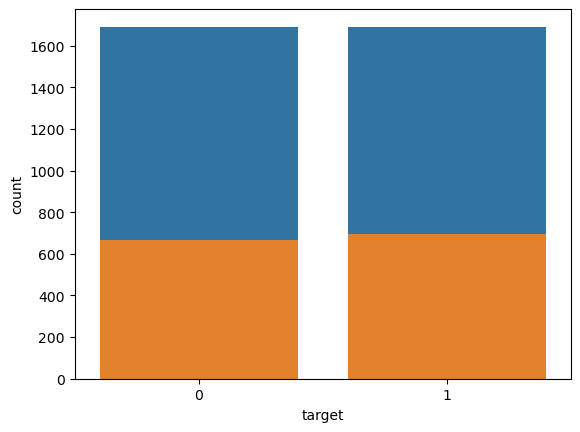

In [27]:
sns.countplot(data = train, x='Target', order = train['Target'].value_counts().index)
plt.xlabel('target')
sns.countplot(data = test, x='Target', order = train['Target'].value_counts().index)
#sns.scatterplot(data = train, x=)

In [28]:
# Prepare features and target
feature_columns = [
    'RECPROUSM156N', 'CORESTICKM159SFRBATL', 'PCETRIM12M159SFRBDAL',
    'CPALTT01USM657N', 'PSAVERT', 'AISRSA', 'ANFCI', 'UNRATE', 'change_5',
    'kama_5_30', 'adxr', 'mdi', 'chop_14', 'mfi_5', 'mfi_14',
    'cci', 'sma_5', 'sma_20', 'ema_5', 'ema_20', 'macd',
    'macd_signal', 'rsi', 'cr', 'cr_ma2', 'cr_ma3'
]

# Prepare X and y
x_train = train[feature_columns] # Features
y_train = train['Target']  # Target (1 if next 5 days' mean close > current close, else 0)

x_test = test[feature_columns] # Features
y_test = test['Target']

x_val = val[feature_columns] # Features
y_val = val['Target']

In [29]:
pd.set_option('display.max_rows', None) 
print(x_train.isnull().sum())

RECPROUSM156N           0
CORESTICKM159SFRBATL    0
PCETRIM12M159SFRBDAL    0
CPALTT01USM657N         0
PSAVERT                 0
AISRSA                  0
ANFCI                   0
UNRATE                  0
change_5                0
kama_5_30               0
adxr                    0
mdi                     0
chop_14                 0
mfi_5                   0
mfi_14                  0
cci                     0
sma_5                   0
sma_20                  0
ema_5                   0
ema_20                  0
macd                    0
macd_signal             0
rsi                     0
cr                      0
cr_ma2                  0
cr_ma3                  0
dtype: int64


need to remove these columns becoz it contain the null values
('XLRE', 'Open')           3381
('XLRE', 'High')           3381
('XLRE', 'Low')            3381
('XLRE', 'Close')          3381
('XLRE', 'Volume')         
('XLC', 'Open')            3381
('XLC', 'High')            3381
('XLC', 'Low')             3381
('XLC', 'Close')           3381
('XLC', 'Volume')          33813381

In [31]:
train.drop(columns=[
    "('XLRE', 'Open')", 
    "('XLRE', 'High')", 
    "('XLRE', 'Low')",
    "('XLRE', 'Close')", 
    "('XLRE', 'Volume')",
    "('XLC', 'Open')", 
    "('XLC', 'High')", 
    "('XLC', 'Low')",
    "('XLC', 'Close')", 
    "('XLC', 'Volume')"
], inplace=True)

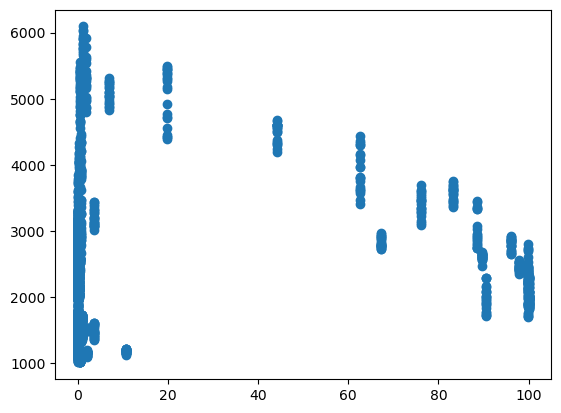

In [32]:
plt.scatter(train['RECPROUSM156N'], train["('000001.SS', 'Close')"])

In [33]:
model = GradientBoostingClassifier()
model.fit(x_train, y_train)

GradientBoostingClassifier()

In [34]:
explainer = shap.Explainer(model)

shap_values = explainer(x_train)

In [35]:
# Calculate mean absolute SHAP value for each feature
shap_df = pd.DataFrame(shap_values.values, columns=x_train.columns)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

# Get top 25 features
top_20_features = mean_abs_shap.head(20)
print("Top 20 important features based on SHAP values:")
print(top_20_features)

Top 20 important features based on SHAP values:
UNRATE                  0.301012
cr                      0.132183
PCETRIM12M159SFRBDAL    0.128067
mdi                     0.119647
AISRSA                  0.103999
rsi                     0.094553
ANFCI                   0.091803
CORESTICKM159SFRBATL    0.075707
RECPROUSM156N           0.071317
change_5                0.062753
ema_20                  0.061785
mfi_5                   0.058297
chop_14                 0.057104
macd                    0.055450
PSAVERT                 0.046488
cr_ma3                  0.046241
sma_20                  0.044570
CPALTT01USM657N         0.038560
ema_5                   0.037115
sma_5                   0.027915
dtype: float64


In [36]:
exclude_columns = [
    'RECPROUSM156N', 'CORESTICKM159SFRBATL', 'PCETRIM12M159SFRBDAL',
    'CPALTT01USM657N', 'PSAVERT', 'AISRSA', 'ANFCI', 'UNRATE',
    'change_5',
    'kama_5_30', 'adxr', 'mdi', 'chop_14', 'mfi_5',
    'sma_5', 'sma_20', 'ema_20',
     'rsi', 'cr', 'cr_ma2', 'cr_ma3'
]


In [37]:
import pandas as pd

# List of columns to exclude
exclude_columns = [
    'RECPROUSM156N', 'CORESTICKM159SFRBATL', 'PCETRIM12M159SFRBDAL',
    'CPALTT01USM657N', 'PSAVERT', 'AISRSA', 'ANFCI', 'UNRATE',
    'open', 'high', 'low', 'close', 'volume', 'change_5',
    'kama_5_30', 'adxr', 'mdi', 'chop_14', 'mfi_5', 'mfi_14',
    'cci', 'sma_5', 'sma_20', 'ema_5', 'ema_20', 'macd',
    'macd_signal', 'rsi', 'cr', 'cr_ma2', 'cr_ma3', "('year_month', '')", 'Next_5_Days_Mean', 'Target'
]

# Create train_10 by dropping specified columns
train_10 = train.drop(columns=exclude_columns)

In [38]:

print("Remaining columns in train_10:", train_10.columns.tolist())


Remaining columns in train_10: ['Unnamed: 0', "('000001.SS', 'Open')", "('000001.SS', 'High')", "('000001.SS', 'Low')", "('000001.SS', 'Close')", "('000001.SS', 'Volume')", "('AAPL', 'Open')", "('AAPL', 'High')", "('AAPL', 'Low')", "('AAPL', 'Close')", "('AAPL', 'Volume')", "('XLE', 'Open')", "('XLE', 'High')", "('XLE', 'Low')", "('XLE', 'Close')", "('XLE', 'Volume')", "('XLF', 'Open')", "('XLF', 'High')", "('XLF', 'Low')", "('XLF', 'Close')", "('XLF', 'Volume')", "('NVDA', 'Open')", "('NVDA', 'High')", "('NVDA', 'Low')", "('NVDA', 'Close')", "('NVDA', 'Volume')", "('XLU', 'Open')", "('XLU', 'High')", "('XLU', 'Low')", "('XLU', 'Close')", "('XLU', 'Volume')", "('XLI', 'Open')", "('XLI', 'High')", "('XLI', 'Low')", "('XLI', 'Close')", "('XLI', 'Volume')", "('META', 'Open')", "('META', 'High')", "('META', 'Low')", "('META', 'Close')", "('META', 'Volume')", "('GOOGL', 'Open')", "('GOOGL', 'High')", "('GOOGL', 'Low')", "('GOOGL', 'Close')", "('GOOGL', 'Volume')", "('XLY', 'Open')", "('XLY'

In [39]:
object_column = train_10.select_dtypes(include = 'object').columns.tolist()

In [40]:
train_10.drop(object_column, axis=1, inplace= True)

In [41]:
selected_columns = [col for col in train_10.columns if 'close' in col.lower()]

In [42]:
closing_prices = train_10[selected_columns]
correlation_matrix = closing_prices.corr()

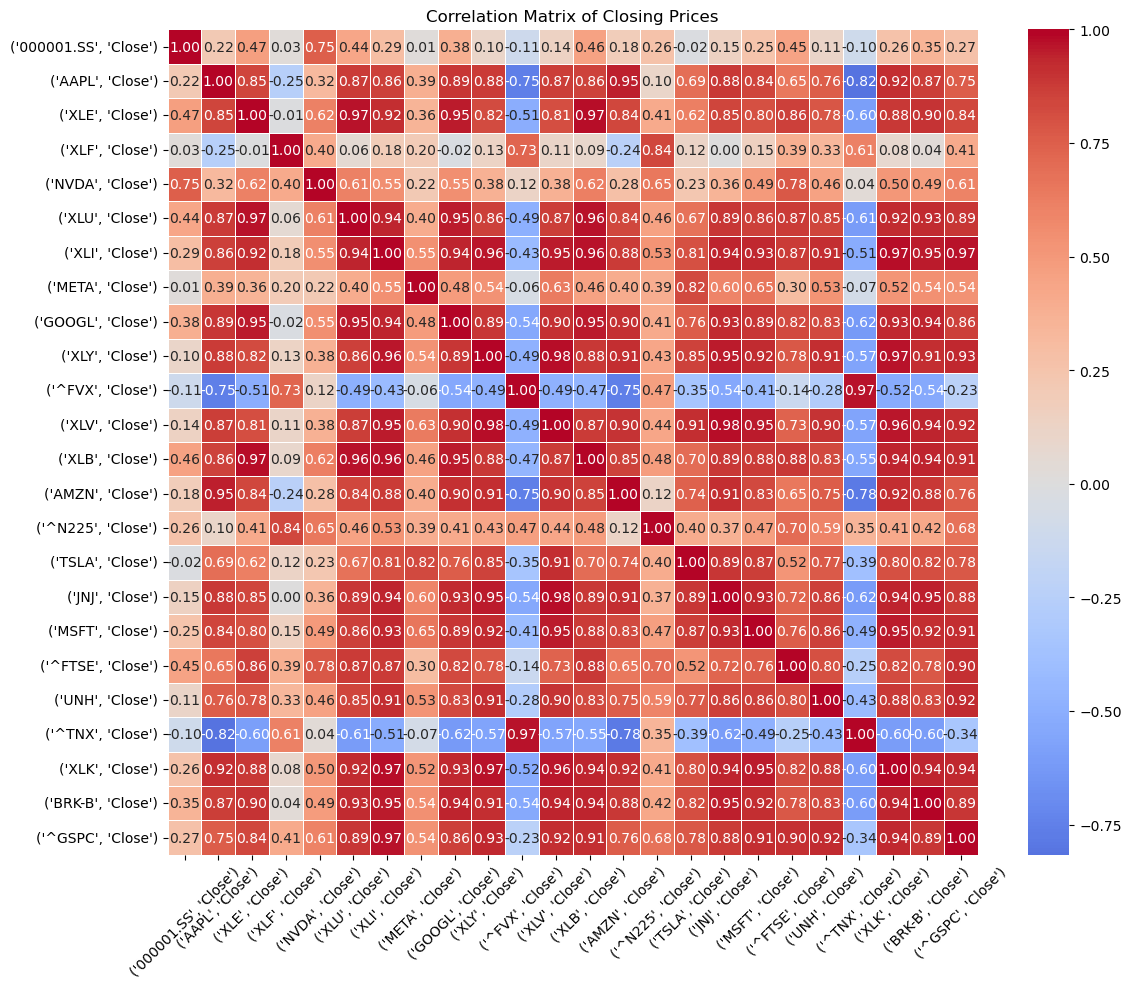

In [43]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt=".2f",
            linewidths=.5)
plt.title('Correlation Matrix of Closing Prices')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Correlation Matrix of Closing Prices.png')
plt.show()

In [44]:
threshold = 0.7

G = nx.Graph()

# Add nodes (ticker names)
ticker_names = [col[0] if isinstance(col, tuple) else eval(col)[0] for col in selected_columns]
for name in ticker_names:
    G.add_node(name)

# Add edges for strong correlations
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > threshold:
            print(corr)
            G.add_edge(ticker_names[i], 
                      ticker_names[j], 
                      weight=corr,
                      color='red' if corr > 0 else 'blue')

0.7478038959683954
0.8489071401274908
0.8732465022127323
0.8625775852056023
0.8880932392167616
0.87752754897478
-0.752844668413677
0.870723726202797
0.8578212896278596
0.9457028802929144
0.8832574786413036
0.844267990450719
0.7631738234143615
-0.8163585066284991
0.9219390753786765
0.8687504245389581
0.7517406254420638
0.9669942290199061
0.915533792570647
0.9507713249021057
0.8170174185224566
0.8114181227744234
0.9728480615629892
0.8402236038118817
0.8498032119389616
0.8033454263802033
0.8604834589904765
0.7813386125533462
0.8846603982421519
0.8978304532562463
0.838353513525364
0.7281914590698545
0.8385953864301083
0.7756719514137146
0.9403830248640636
0.9526657062978671
0.8645738374584736
0.8675690202237871
0.9649409261117753
0.8410355056950023
0.8897697860435461
0.8625803221890781
0.8724878965328804
0.8468856331364508
0.9249767829010039
0.9267217831464462
0.8880177232495288
0.9393552451371755
0.9617151161659607
0.9523907926755292
0.9649422306932752
0.8764122951868988
0.807280844195110

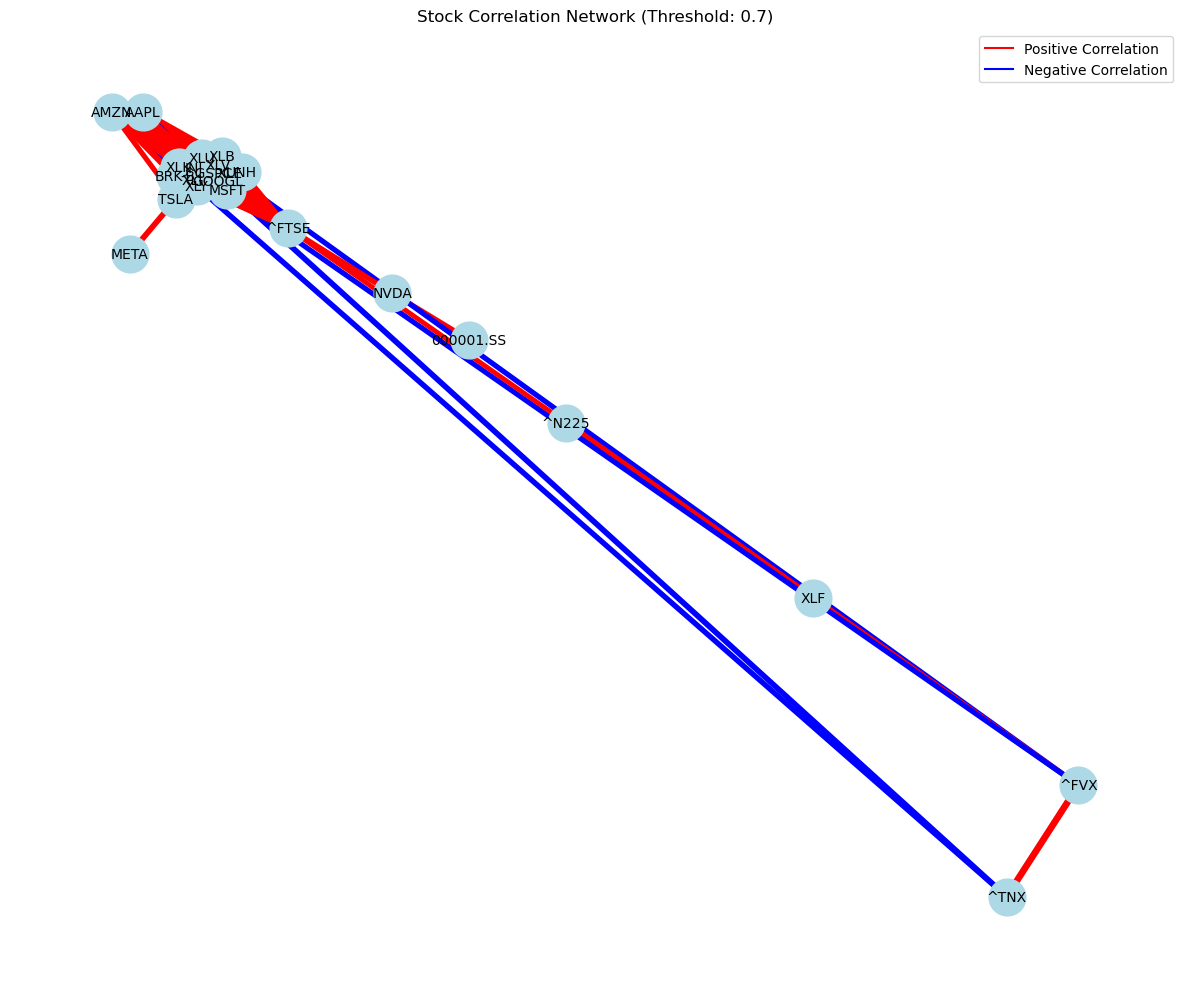

In [45]:
# Draw the network
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.15)  # k regulates the distance between nodes

# Get edge colors and widths
edges = G.edges()
colors = [G[u][v]['color'] for u,v in edges]
weights = [abs(G[u][v]['weight'])*5 for u,v in edges]  # Scale width by correlation strength

nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, edge_color=colors, width=weights)
nx.draw_networkx_labels(G, pos, font_size=10)

# Create legend for edge colors
plt.plot([], [], 'r-', label='Positive Correlation')
plt.plot([], [], 'b-', label='Negative Correlation')
plt.legend()

plt.title(f'Stock Correlation Network (Threshold: {threshold})')
plt.axis('off')
plt.tight_layout()
plt.show()

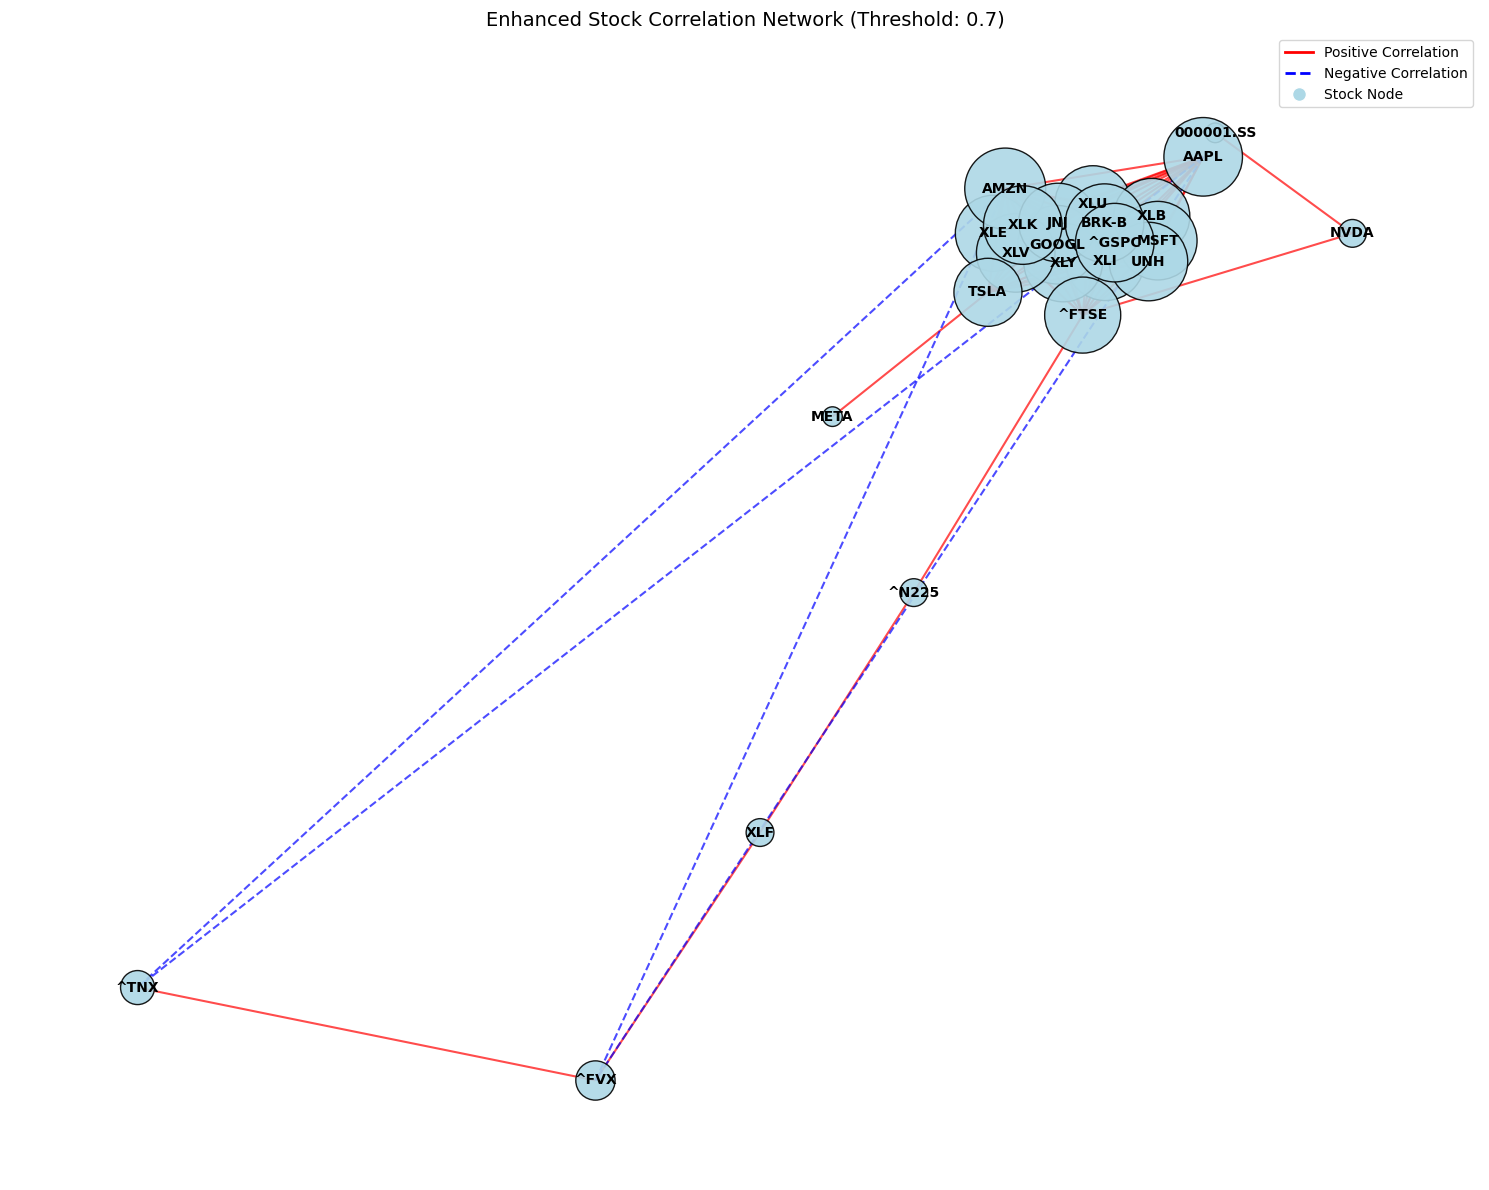

In [46]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Assuming `G` is your existing NetworkX graph
# If not, recreate it with your correlation matrix:
# G = nx.from_pandas_adjacency(correlation_matrix.abs() > 0.7)

# Customize node positions for better spacing
pos = nx.spring_layout(G, k=0.5, seed=42, iterations=100)  # Increase k and iterations

# Set up figure
plt.figure(figsize=(15, 12))

# Draw nodes with varying sizes (optional: size by market cap)
node_sizes = [G.degree(node) * 200 for node in G.nodes()]
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes,
    node_color="lightblue", alpha=0.9, edgecolors="black"
)

# Draw edges with clear differentiation
positive_edges = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] > 0]
negative_edges = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] < 0]

nx.draw_networkx_edges(
    G, pos, edgelist=positive_edges,
    edge_color="red", width=1.5, alpha=0.7
)
nx.draw_networkx_edges(
    G, pos, edgelist=negative_edges,
    edge_color="blue", width=1.5, alpha=0.7, style="dashed"
)

# Draw labels with improved readability
nx.draw_networkx_labels(
    G, pos, font_size=10, font_weight="bold",
    font_color="black", verticalalignment="center"
)

# Add legend
legend_elements = [
    Line2D([0], [0], color="red", lw=2, label="Positive Correlation"),
    Line2D([0], [0], color="blue", lw=2, linestyle="--", label="Negative Correlation"),
    Line2D([0], [0], marker="o", color="w", label="Stock Node",
           markerfacecolor="lightblue", markersize=10)
]
plt.legend(handles=legend_elements, loc="upper right")

# Title and axis
plt.title("Enhanced Stock Correlation Network (Threshold: 0.7)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

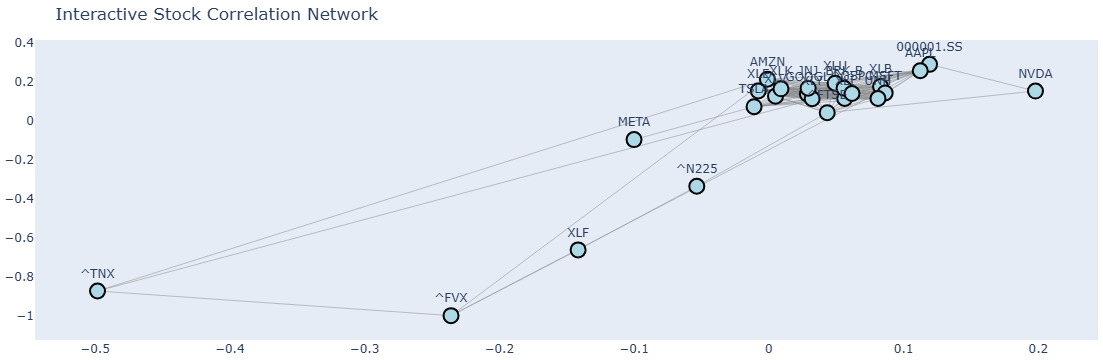

In [47]:
import plotly.graph_objects as go

# Convert NetworkX graph to Plotly format
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color="#888"),
    hoverinfo="none",
    mode="lines"
)

node_x = []
node_y = []
node_text = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode="markers+text",
    text=node_text,
    textposition="top center",
    marker=dict(
        size=15,
        color="lightblue",
        line=dict(width=2, color="black")
    ),
    hoverinfo="text"
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="Interactive Stock Correlation Network",
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False),
        yaxis=dict(showgrid=False, zeroline=False)
    )
)
fig.show()

In [80]:
edge_list = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col_i = correlation_matrix.columns[i]
        col_j = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        
        if abs(corr_value) > threshold:
            edge_list.append((col_i, col_j, corr_value))


edges_df = pd.DataFrame(edge_list, columns=['source', 'target', 'weight'])

# View edge list
print(edges_df)

                     source              target    weight
0    ('000001.SS', 'Close')   ('NVDA', 'Close')  0.747804
1         ('AAPL', 'Close')    ('XLE', 'Close')  0.848907
2         ('AAPL', 'Close')    ('XLU', 'Close')  0.873247
3         ('AAPL', 'Close')    ('XLI', 'Close')  0.862578
4         ('AAPL', 'Close')  ('GOOGL', 'Close')  0.888093
5         ('AAPL', 'Close')    ('XLY', 'Close')  0.877528
6         ('AAPL', 'Close')   ('^FVX', 'Close') -0.752845
7         ('AAPL', 'Close')    ('XLV', 'Close')  0.870724
8         ('AAPL', 'Close')    ('XLB', 'Close')  0.857821
9         ('AAPL', 'Close')   ('AMZN', 'Close')  0.945703
10        ('AAPL', 'Close')    ('JNJ', 'Close')  0.883257
11        ('AAPL', 'Close')   ('MSFT', 'Close')  0.844268
12        ('AAPL', 'Close')    ('UNH', 'Close')  0.763174
13        ('AAPL', 'Close')   ('^TNX', 'Close') -0.816359
14        ('AAPL', 'Close')    ('XLK', 'Close')  0.921939
15        ('AAPL', 'Close')  ('BRK-B', 'Close')  0.868750
16        ('AA

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of top features (from SHAP)
top_features = [
    'UNRATE', 'PCETRIM12M159SFRBDAL', 'cr', 'ANFCI', 'mdi', 'AISRSA', 'rsi',
    'ema_20', 'RECPROUSM156N', 'CORESTICKM159SFRBATL', 'chop_14', 'sma_20',
    'change_5', 'mfi_5', 'macd', 'cr_ma3', 'CPALTT01USM657N',
    'ema_5','sma_5', 'cr_ma3', 'PSAVERT'
]

selected_data = x_train[top_features]

In [82]:
shap_values.shape

(3381, 26)

In [86]:
# If shap_values is a SHAP Explanation object
mean_shap_values = shap_values.values.mean(axis=0)
print(type(shap_values))         # likely shap.Explanation
print(shap_values.values.shape)  # should be (3361, 26)


<class 'shap._explanation.Explanation'>
(3381, 26)


In [88]:
feature_names = shap_values.feature_names
base_value = shap_values.base_values.mean()  # average base value across all samples

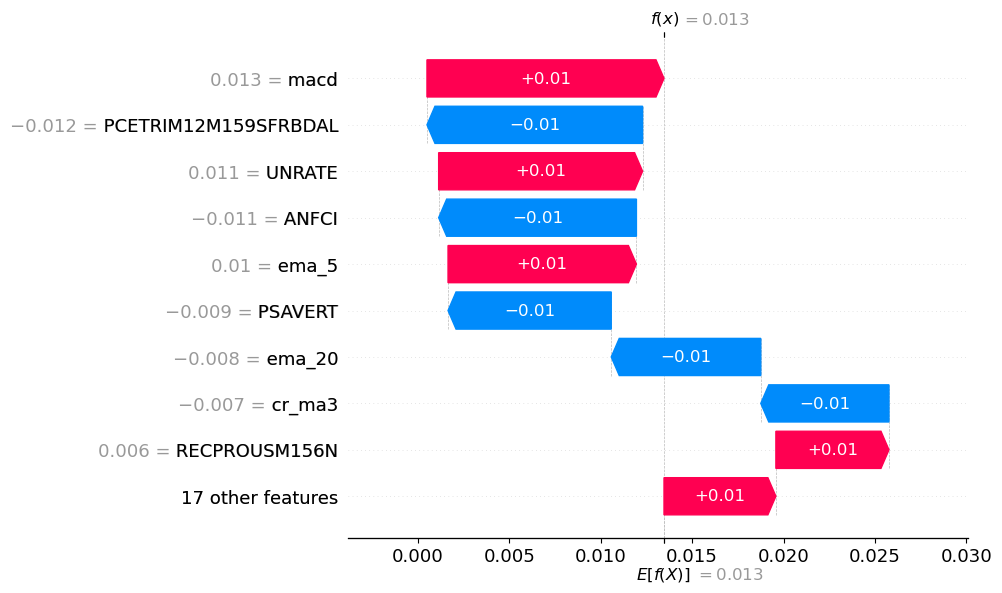

<Figure size 640x480 with 0 Axes>

In [90]:
# Create new explanation for the mean
mean_explanation = shap.Explanation(
    values=mean_shap_values,
    base_values=base_value,
    data=mean_shap_values,
    feature_names=feature_names
)

# Plot
shap.plots.waterfall(mean_explanation)
plt.savefig('Explanation for the Mean.png')

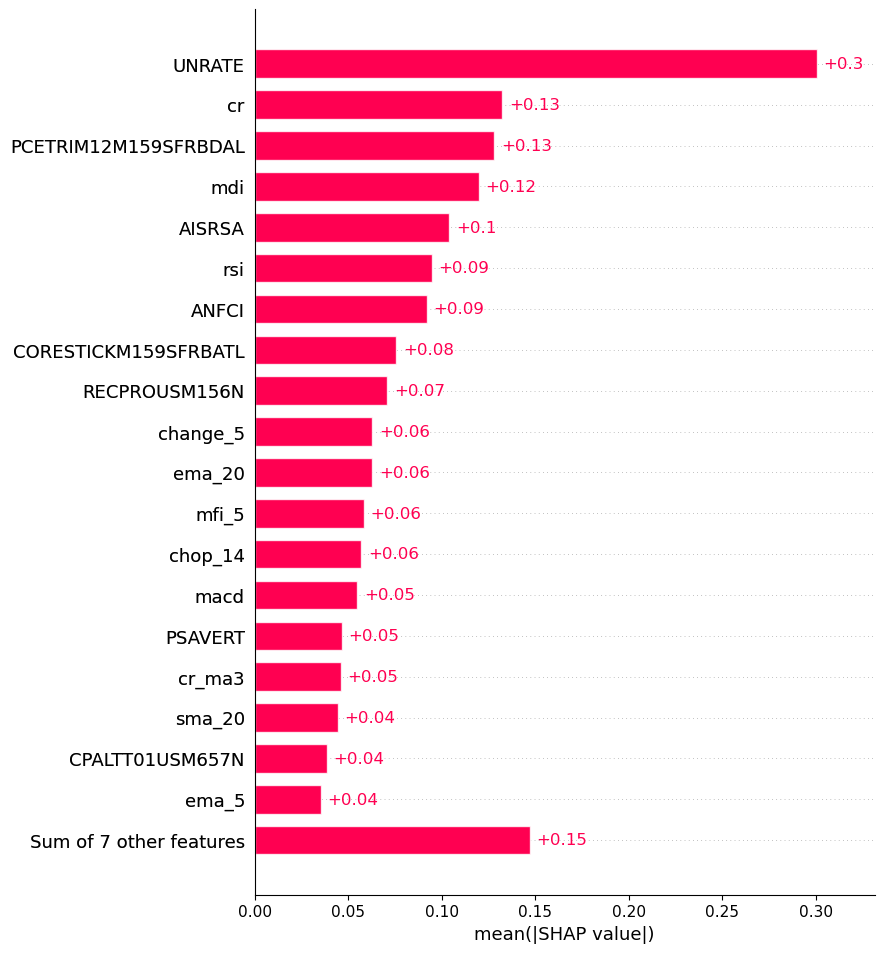

<Figure size 640x480 with 0 Axes>

In [353]:
shap.plots.bar(shap_values, max_display = 20)
plt.show()
plt.savefig('Explanation for the Mean.png')

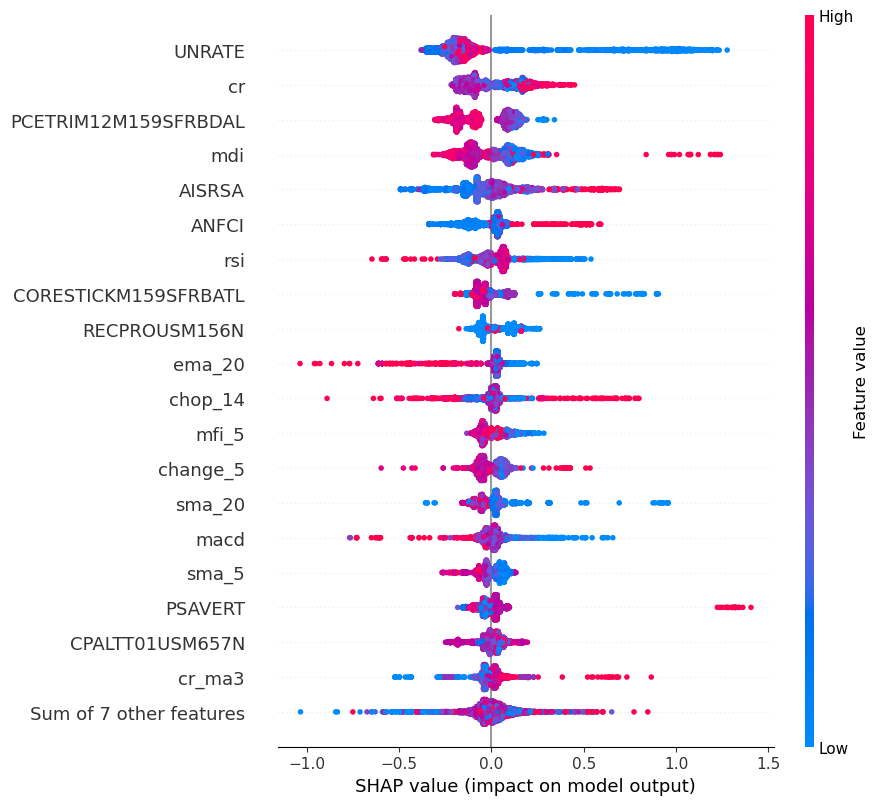

In [90]:
shap.plots.beeswarm(shap_values, max_display = 20)
#shap.summary_plot(shap_values.values, shap_values.data, max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm.png")
plt.close()

In [96]:
import torch

# Define all nodes with their categories
nodes = {
    # Stocks
    'AAPL': 'stock', 'MSFT': 'stock', 'GOOGL': 'stock', 'AMZN': 'stock', 
    'TSLA': 'stock', 'BRK-B': 'stock', 'UNH': 'stock', 'JNJ': 'stock',
    'XOM': 'stock', 'GOOG': 'stock',
    
    # Yields
    '^TNX': 'yield', '^FVX': 'yield',
    
    # Indexes
    '^GSPC': 'index', '^FTSE': 'index', '^N225': 'index', '000001.SS': 'index',
    
    # Sectors
    'XLB': 'sector', 'XLI': 'sector', 'XLC': 'sector', 'XLF': 'sector',
    'XLK': 'sector', 'XLV': 'sector', 'XLU': 'sector', 'XLE': 'sector'

}
nodes1= [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'BRK-B', 'UNH', 'JNJ','NVDA', 'META', 
    '^TNX', '^FVX', '^GSPC', '^FTSE', '^N225', '000001.SS',
    'XLB', 'XLI', 'XLF', 'XLK', 'XLV', 'XLU', 'XLE', 'XLY'
]

# Create node to index mapping
node_to_idx1 = {node: idx for idx, node in enumerate(nodes1)}

In [97]:

'''
node_to_idx1
{'AAPL': 0,
 'MSFT': 1,
 'GOOGL': 2,
 'AMZN': 3,
 'TSLA': 4,
 'BRK-B': 5,
 'UNH': 6,
 'JNJ': 7,
 'NVDA': 8,
 'META': 9,
 '^TNX': 10,
 '^FVX': 11,
 '^GSPC': 12,
 '^FTSE': 13,
 '^N225': 14,
 '000001.SS': 15,
 'XLB': 16,
 'XLI': 17,
 'XLF': 18,
 'XLK': 19,
 'XLV': 20,
 'XLU': 21,
 'XLE': 22,
 'XLY': 23}
Selection deleted

'''

"\nnode_to_idx1\n{'AAPL': 0,\n 'MSFT': 1,\n 'GOOGL': 2,\n 'AMZN': 3,\n 'TSLA': 4,\n 'BRK-B': 5,\n 'UNH': 6,\n 'JNJ': 7,\n 'NVDA': 8,\n 'META': 9,\n '^TNX': 10,\n '^FVX': 11,\n '^GSPC': 12,\n '^FTSE': 13,\n '^N225': 14,\n '000001.SS': 15,\n 'XLB': 16,\n 'XLI': 17,\n 'XLF': 18,\n 'XLK': 19,\n 'XLV': 20,\n 'XLU': 21,\n 'XLE': 22,\n 'XLY': 23}\nSelection deleted\n\n"

In [100]:
arr1= []
for abc in edges_df['source']:
    for str in node_to_idx1:
        if str in abc:
            arr1.append(node_to_idx1[str])
            
            

In [101]:
edges_df['source_nums'] = arr1

In [104]:
arr2= []
for abc in edges_df['target']:
    for str in node_to_idx1: 
        if str in abc:
            arr2.append(node_to_idx1[str])

In [106]:
edges_df['target_nums'] = arr2
edge_list_df = edges_df[['source_nums', 'target_nums']]
edge_index=np.array(edge_list_df)
edge_index
edge_index = torch.from_numpy(edge_index)
edge_index= edge_index.transpose(0, 1)

In [108]:
edge_index

tensor([[15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 22,
         22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 18, 18,  8, 21, 21,
         21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17,  9,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 11, 11, 20, 20, 20, 20,
         20, 20, 20, 20, 20, 20, 16, 16, 16, 16, 16, 16, 16, 16,  3,  3,  3,  3,
          3,  3,  3,  3, 14,  4,  4,  4,  4,  4,  4,  7,  7,  7,  7,  7,  7,  1,
          1,  1,  1,  1, 13, 13, 13, 13,  6,  6,  6, 19, 19,  5],
        [ 8, 22, 21, 17,  2, 23, 11, 20, 16,  3,  7,  1,  6, 10, 19,  5, 12, 21,
         17,  2, 23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12, 11, 14, 13, 17,  2,
         23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12,  2, 23, 20, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  4, 23, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5,
         12, 20, 16,  3,  4,  7,  1, 13,  6

In [110]:
edge_index_data = pd.DataFrame(edge_index)

In [112]:
columns = [
    ('000001.SS', 'Open'), ('000001.SS', 'Close'),  # Index (Shanghai Composite)
    ('AAPL', 'Open'), ('AAPL', 'Close'),           # Stock
    ('XLE', 'Open'), ('XLE', 'Close'),             # Sector (Energy)
    ('XLF', 'Open'), ('XLF', 'Close'),             # Sector (Financial)
    ('NVDA', 'Open'), ('NVDA', 'Close'),           # Stock
    ('XLU', 'Open'), ('XLU', 'Close'),             # Sector (Utilities)
    ('XLI', 'Open'), ('XLI', 'Close'),             # Sector (Industrial)
    ('META', 'Open'), ('META', 'Close'),           # Stock
    ('GOOGL', 'Open'), ('GOOGL', 'Close'),         # Stock
    ('XLY', 'Open'), ('XLY', 'Close'),             # Sector (Consumer Disc.)
    ('^FVX', 'Open'), ('^FVX', 'Close'),           # Yield (5-Year Treasury)
    ('XLV', 'Open'), ('XLV', 'Close'),             # Sector (Healthcare)
    ('XLB', 'Open'), ('XLB', 'Close'),             # Sector (Materials)
    ('AMZN', 'Open'), ('AMZN', 'Close'),           # Stock
    ('^N225', 'Open'), ('^N225', 'Close'),         # Index (Nikkei 225)
    ('TSLA', 'Open'), ('TSLA', 'Close'),           # Stock
    ('JNJ', 'Open'), ('JNJ', 'Close'),             # Stock
    ('MSFT', 'Open'), ('MSFT', 'Close'),           # Stock
    ('^FTSE', 'Open'), ('^FTSE', 'Close'),         # Index (FTSE 100)
    ('UNH', 'Open'), ('UNH', 'Close'),             # Stock
    ('^TNX', 'Open'), ('^TNX', 'Close'),           # Yield (10-Year Treasury)
    ('XLK', 'Open'), ('XLK', 'Close'),             # Sector (Tech)
    ('BRK-B', 'Open'), ('BRK-B', 'Close'),         # Stock
    ('^GSPC', 'Open'), ('^GSPC', 'Close'),         # Index (S&P 500)
]

# Extract unique assets from the columns
unique_assets = list(set([col[0] for col in columns]))

# Categorize the assets
def categorize_asset(asset):
    if asset.startswith('X'):
        return 'sector'
    elif asset.startswith('^'):
        if asset in ['^FVX', '^TNX']:
            return 'yield'
        return 'index'
    else:
        return 'stock'

assets = {
    asset: categorize_asset(asset)
    for asset in unique_assets
}

# Define sector memberships (manually curated based on common knowledge)
sector_membership = {
    'XLK': ['AAPL', 'MSFT', 'GOOGL', 'META', 'NVDA'],  # Technology
    'XLV': ['JNJ', 'UNH'],                             # Healthcare
    'XLY': ['AMZN', 'TSLA', 'DIS'],                    # Consumer Discretionary
    'XLF': ['JPM', 'BRK-B'],                           # Financials
    'XLE': ['XOM', 'CVX'],                             # Energy
    'XLI': ['GE', 'HON'],                              # Industrials
    'XLU': ['NEE', 'DUK'],                             # Utilities
    'XLB': ['LIN', 'APD']                              # Materials
}

# Filter to only include stocks we actually have in our data
sector_membership = {
    sector: [stock for stock in stocks if stock in assets]
    for sector, stocks in sector_membership.items()
    if sector in assets
}

# Create node to index mapping
node_to_idx = {node: idx for idx, node in enumerate(assets.keys())}

# Initialize edge list
edges = []


# Convert to PyTorch Geometric edge_index format
if edges:
    edge_index = torch.tensor(list(zip(*edges)), dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)  # Add reverse directions
else:
    edge_index = torch.empty((2, 0), dtype=torch.long)

# Print information
print("Asset Categories:")
for asset, category in assets.items():
    print(f"{asset}: {category}")

print(f"\nTotal nodes: {len(assets)}")
print(f"Total edges: {edge_index.shape[1]//2} (undirected)")

print("\nSample edges (first 10):")
for i in range(min(10, edge_index.shape[1])):
    src, dst = edge_index[:, i]
    src_asset = list(assets.keys())[src]
    dst_asset = list(assets.keys())[dst]
    print(f"{src_asset} ({assets[src_asset]}) -- {dst_asset} ({assets[dst_asset]})")

Asset Categories:
META: stock
AMZN: stock
XLV: sector
XLU: sector
^N225: index
GOOGL: stock
UNH: stock
XLI: sector
AAPL: stock
^GSPC: index
XLB: sector
XLY: sector
^FTSE: index
000001.SS: stock
JNJ: stock
MSFT: stock
NVDA: stock
XLE: sector
TSLA: stock
XLK: sector
^TNX: yield
BRK-B: stock
XLF: sector
^FVX: yield

Total nodes: 24
Total edges: 0 (undirected)

Sample edges (first 10):


In [114]:
assets

{'META': 'stock',
 'AMZN': 'stock',
 'XLV': 'sector',
 'XLU': 'sector',
 '^N225': 'index',
 'GOOGL': 'stock',
 'UNH': 'stock',
 'XLI': 'sector',
 'AAPL': 'stock',
 '^GSPC': 'index',
 'XLB': 'sector',
 'XLY': 'sector',
 '^FTSE': 'index',
 '000001.SS': 'stock',
 'JNJ': 'stock',
 'MSFT': 'stock',
 'NVDA': 'stock',
 'XLE': 'sector',
 'TSLA': 'stock',
 'XLK': 'sector',
 '^TNX': 'yield',
 'BRK-B': 'stock',
 'XLF': 'sector',
 '^FVX': 'yield'}

In [116]:
selected_columns = list(set(x_train.columns).union(set(train_10.columns)))

In [118]:
selected_columns

['UNRATE',
 "('XLU', 'Low')",
 "('XLV', 'Close')",
 "('MSFT', 'Volume')",
 'adxr',
 "('000001.SS', 'Open')",
 "('^GSPC', 'Volume')",
 'chop_14',
 'ema_5',
 "('AMZN', 'Close')",
 "('META', 'Close')",
 'sma_20',
 "('META', 'Open')",
 "('MSFT', 'Open')",
 "('UNH', 'Volume')",
 "('MSFT', 'Low')",
 "('AAPL', 'Close')",
 "('AMZN', 'Open')",
 "('^FVX', 'Volume')",
 "('BRK-B', 'Volume')",
 "('TSLA', 'Low')",
 "('^N225', 'Close')",
 "('XLY', 'Low')",
 "('^N225', 'Low')",
 "('NVDA', 'Volume')",
 'CPALTT01USM657N',
 "('XLE', 'High')",
 'mfi_5',
 "('AMZN', 'Low')",
 "('XLB', 'Low')",
 'CORESTICKM159SFRBATL',
 'AISRSA',
 "('^GSPC', 'Open')",
 "('XLB', 'Close')",
 'kama_5_30',
 "('XLY', 'Close')",
 "('XLF', 'High')",
 "('GOOGL', 'Low')",
 'macd_signal',
 "('NVDA', 'Open')",
 "('XLK', 'High')",
 "('^GSPC', 'Low')",
 'mfi_14',
 "('XLV', 'Volume')",
 "('AAPL', 'Open')",
 "('XLE', 'Volume')",
 "('XLF', 'Low')",
 "('MSFT', 'High')",
 'macd',
 "('XLF', 'Close')",
 "('AAPL', 'High')",
 "('^FVX', 'Open')",


In [120]:
feature_matrix_data= train[selected_columns]

In [122]:
object_column = feature_matrix_data.select_dtypes(include = 'object').columns.tolist()

In [124]:
object_column 

[]

In [126]:
feature_matrix_data.drop(object_column, axis=1, inplace= True)
object_column

C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\3538607499.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



[]

Need to transfor the data 

In [129]:
tickers= [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'BRK-B', 'UNH', 'JNJ','NVDA', 'META', 
    '^TNX', '^FVX', '^GSPC', '^FTSE', '^N225', '000001.SS',
    'XLB', 'XLI', 'XLF', 'XLK', 'XLV', 'XLU', 'XLE', 'XLY'
]

exclude_columns = [
    'RECPROUSM156N', 'CORESTICKM159SFRBATL', 'PCETRIM12M159SFRBDAL',
    'CPALTT01USM657N', 'PSAVERT', 'AISRSA', 'ANFCI', 'UNRATE','change_5',
    'kama_5_30', 'adxr', 'mdi', 'chop_14', 'mfi_5', 'mfi_14',
    'cci', 'sma_5', 'sma_20', 'ema_5', 'ema_20', 'macd',
    'macd_signal', 'rsi', 'cr', 'cr_ma2', 'cr_ma3'
]
selected_features_using_corelation= [
    'sma_5', 'sma_20', 'ema_5', 'ema_20',
    'macd', 'macd_signal', 'rsi',
    'mfi_5', 'mfi_14','UNRATE' , 'cr','PCETRIM12M159SFRBDAL',
    'mdi','AISRSA', 'ANFCI',  
]
                 
# Create train_10

In [148]:
feature = [[] for _ in range(3361)]

for t in range(3361):
    feature[t] = []  # For storing features of all tickers at time t
    for ticker in tickers:
        ticker_features = []
        for col in train.columns:
            if ticker in col or col in selected_features_using_corelation:
                ticker_features.append(train.iloc[t][col])
        feature[t].append(ticker_features)


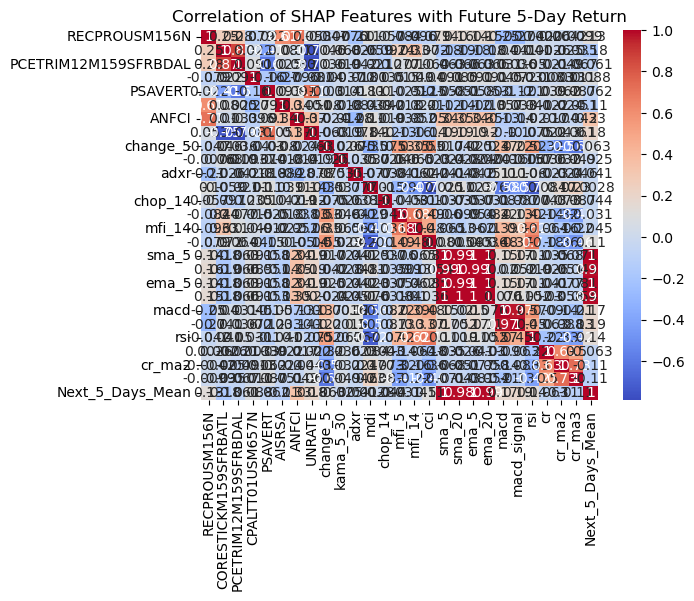

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
corrs_feature_output = train[exclude_columns + ['Next_5_Days_Mean']].corr()
sns.heatmap(corrs_feature_output, annot=True, cmap="coolwarm")
plt.title("Correlation of SHAP Features with Future 5-Day Return")
plt.show()


In [150]:
import torch
import torch.nn as nn
from torch_geometric.nn import SAGEConv
from torch.distributions import Categorical
from torch_geometric.data import Data

x = torch.tensor(feature, dtype=torch.float)
edge_index = torch.tensor(edge_index, dtype=torch.long)

data = Data(x=x, edge_index=edge_index)
print(data)


Data(x=[3361, 24, 20], edge_index=[2, 0])


C:\Users\Acer\AppData\Local\Temp\ipykernel_23952\908281215.py:8: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



In [151]:
edge_index = [[15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 22,
         22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 18, 18,  8, 21, 21,
         21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17,  9,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 11, 11, 20, 20, 20, 20,
         20, 20, 20, 20, 20, 20, 16, 16, 16, 16, 16, 16, 16, 16,  3,  3,  3,  3,
          3,  3,  3,  3, 14,  4,  4,  4,  4,  4,  4,  7,  7,  7,  7,  7,  7,  1,
          1,  1,  1,  1, 13, 13, 13, 13,  6,  6,  6, 19, 19,  5],
        [ 8, 22, 21, 17,  2, 23, 11, 20, 16,  3,  7,  1,  6, 10, 19,  5, 12, 21,
         17,  2, 23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12, 11, 14, 13, 17,  2,
         23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12,  2, 23, 20, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  4, 23, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5,
         12, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5, 12,  3, 10, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  3,  7,  1, 13,  6, 19,  5, 12,  4,  7,  1,  6,
         10, 19,  5, 12, 13,  7,  1,  6, 19,  5, 12,  1, 13,  6, 19,  5, 12, 13,
          6, 19,  5, 12,  6, 19,  5, 12, 19,  5, 12,  5, 12, 12]]

In [152]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_train_10 = StandardScaler()
scaler_feature = StandardScaler()

train_10_scaled = scaler_train_10.fit_transform(train_10)
train_10 = pd.DataFrame(train_10_scaled, columns=train_10.columns)

feature_matrix = [[] for _ in range(3361)]

for t in range(3361):
    feature_matrix[t] = scaler_feature.fit_transform(feature[t])

In [153]:
feature_matrix_dup = feature_matrix

In [ ]:
import numpy as np
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import pickle
import matplotlib.pyplot as plt

# -----------------------------
# GraphPortfolioEnv Definition
# -----------------------------

class GraphPortfolioEnv(gym.Env):
    def __init__(self, feature_matrix, price_matrix, adj_matrix, initial_cash=1.0, trading_cost=0.0025):
        super().__init__()
        self.feature_matrix = feature_matrix
        self.price_matrix = price_matrix

        """if adj_matrix.shape[0] == 2:
            self.edge_index = adj_matrix
        else:
            self.edge_index = adj_matrix.T"""

        self.edge_index = [[15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 22,
         22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 18, 18,  8, 21, 21,
         21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17,  9,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 11, 11, 20, 20, 20, 20,
         20, 20, 20, 20, 20, 20, 16, 16, 16, 16, 16, 16, 16, 16,  3,  3,  3,  3,
          3,  3,  3,  3, 14,  4,  4,  4,  4,  4,  4,  7,  7,  7,  7,  7,  7,  1,
          1,  1,  1,  1, 13, 13, 13, 13,  6,  6,  6, 19, 19,  5],
        [ 8, 22, 21, 17,  2, 23, 11, 20, 16,  3,  7,  1,  6, 10, 19,  5, 12, 21,
         17,  2, 23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12, 11, 14, 13, 17,  2,
         23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12,  2, 23, 20, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  4, 23, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5,
         12, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5, 12,  3, 10, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  3,  7,  1, 13,  6, 19,  5, 12,  4,  7,  1,  6,
         10, 19,  5, 12, 13,  7,  1,  6, 19,  5, 12,  1, 13,  6, 19,  5, 12, 13,
          6, 19,  5, 12,  6, 19,  5, 12, 19,  5, 12,  5, 12, 12]]

        self.num_edges = self.edge_index[1]
        self.T, self.N, self.F = 3361, 24, 20
        self.initial_cash = initial_cash
        self.trading_cost = trading_cost

        self.action_space = spaces.Box(low=0, high=1, shape=(self.N,), dtype=np.float32)
        self.observation_space = spaces.Dict({
            "x": spaces.Box(low=-np.inf, high=np.inf, shape=(self.N, self.F), dtype=np.float32),
            "edge_index": spaces.Box(low=0, high=self.N, shape=(2, self.num_edges), dtype=np.int32),
        })

        self.graph_sage = GraphSAGE(
            in_channels=self.F,
            hidden_channels=16,
            num_layers=2,
            out_channels=1,
            aggr="mean",
        )

        self.benchmark_values = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash],
        }

        self.metrics = {
            "Sharpe Ratio": [],
            "Sortino Ratio": [],
            "Max Drawdown": [],
            "Calmar Ratio": [],
        }

        self.reset()

    def reset(self):
        self.t = 1
        self.portfolio_value = self.initial_cash
        self.weights = np.ones(self.N) / self.N
        self.history = [self.portfolio_value]
        self.benchmark_values["Equal Weight"] = [self.initial_cash]
        self.benchmark_values["S&P 500"] = [self.initial_cash]
        return self._get_state()

    def _get_state(self):
        x = torch.tensor(self.feature_matrix[self.t], dtype=torch.float32)
        edge_index = torch.tensor(self.edge_index, dtype=torch.long)
        return {"x": x, "edge_index": edge_index}

    def step(self, action):
        weights = np.clip(action, 0, 1)
        weights = weights / (weights.sum() + 1e-8)

        prev_prices = self.price_matrix[self.t - 1]
        curr_prices = self.price_matrix[self.t]
        price_relatives = curr_prices / (prev_prices + 1e-8)

        weight_change = np.abs(weights - self.weights).sum()
        cost = self.trading_cost * weight_change

        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        cost = self.trading_cost * np.sum(np.abs(self.weights - action))
        reward_raw = np.log(portfolio_return) if portfolio_return > 0 else -1.0
        reward = reward_raw - cost

        if reward > 0:
            reward += 0.005
        drawdown = max(0, (self.portfolio_value - new_value) / self.portfolio_value)
        reward -= 0.1 * drawdown

        self.portfolio_value = new_value
        self.weights = weights
        self.history.append(self.portfolio_value)
        self.t += 1

        self._update_benchmarks(price_relatives)
        self._update_metrics()

        done = (self.t >= self.T - 1)
        next_state = self._get_state() if not done else None

        info = {
            "portfolio_value": self.portfolio_value,
            "weights": self.weights,
            "metrics": self.metrics,
            "benchmarks": self.benchmark_values,
        }
        return next_state, reward, done, info

    def _update_benchmarks(self, price_relatives):
        ew_return = np.mean(price_relatives)
        self.benchmark_values["Equal Weight"].append(
            self.benchmark_values["Equal Weight"][-1] * ew_return
        )
        sp500_return = price_relatives[-1]
        self.benchmark_values["S&P 500"].append(
            self.benchmark_values["S&P 500"][-1] * sp500_return
        )

    def _update_metrics(self):
        returns = np.diff(self.history) / self.history[:-1]
        risk_free_rate = 0.0
        sharpe = (np.mean(returns) - risk_free_rate) / (np.std(returns) + 1e-8)
        downside_returns = returns[returns < 0]
        sortino = (np.mean(returns) - risk_free_rate) / (np.std(downside_returns) + 1e-8)
        peak = np.maximum.accumulate(self.history)
        trough = np.minimum.accumulate(self.history)
        max_drawdown = np.max((peak - trough) / peak)
        calmar = np.mean(returns) / (max_drawdown + 1e-8)

        self.metrics["Sharpe Ratio"].append(sharpe)
        self.metrics["Sortino Ratio"].append(sortino)
        self.metrics["Max Drawdown"].append(max_drawdown)
        self.metrics["Calmar Ratio"].append(calmar)

    def render(self, mode='human'):
        print(f"Step {self.t}:")
        print(f"- Portfolio Value: {self.portfolio_value:.4f}")
        print(f"- Equal Weight: {self.benchmark_values['Equal Weight'][-1]:.4f}")
        print(f"- S&P 500: {self.benchmark_values['S&P 500'][-1]:.4f}")
        print(f"- Sharpe Ratio: {self.metrics['Sharpe Ratio'][-1]:.4f}")

    def get_portfolio_history(self):
        return {
            "DRL": self.history,
            "Equal Weight": self.benchmark_values["Equal Weight"],
            "S&P 500": self.benchmark_values["S&P 500"],
        }

# -----------------------------
# GraphSAGE Extractor
# -----------------------------

class GraphSAGEExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=16):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]
        self.graph_sage = GraphSAGE(
            in_channels=self.node_features,
            hidden_channels=16,
            num_layers=2,
            out_channels=1,
            aggr="mean",
        )
        self.flatten = nn.Flatten()

    def forward(self, observations):
        batch_size = observations["x"].shape[0]
        data_list = []
        for i in range(batch_size):
            x_i = torch.as_tensor(observations["x"][i], dtype=torch.float32)
            edge_i = torch.as_tensor(observations["edge_index"][i], dtype=torch.long)
            data_list.append(Data(x=x_i, edge_index=edge_i))
        batch = Batch.from_data_list(data_list)
        embeddings = self.graph_sage(batch.x, batch.edge_index)
        pooled = embeddings.view(batch_size, -1)
        return pooled

# -----------------------------
# Setup, Training, Evaluation
# -----------------------------

# Replace with actual variables:
# feature_matrix, closing_prices, edge_index must be initialized before this

env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)

policy_kwargs = {
    "features_extractor_class": GraphSAGEExtractor,
    "features_extractor_kwargs": {"features_dim": env.N},
}

model = PPO(
    "MultiInputPolicy",
    env,
    policy_kwargs=policy_kwargs,
    learning_rate=0.001,
    batch_size=32,
    clip_range=0.5,
    verbose=1,
)

# Train and Save
model.learn(total_timesteps=50_000)
model.save("graph_ppo_portfolio")

# Evaluation
obs = env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

# Save evaluation results
results = {
    "portfolio_history": env.get_portfolio_history(),
    "metrics": env.metrics
}
with open("evaluation_results.pkl", "wb") as f:
    pickle.dump(results, f)

# Print final metrics
print("\n📈 Final Portfolio and Benchmarks:")
for k, v in results["portfolio_history"].items():
    print(f"{k}: {v[-1]:.4f}")

print("\n📊 Final Metrics:")
for k, v in results["metrics"].items():
    print(f"{k}: {v[-1]:.4f}")

# Plot
for k, v in results["portfolio_history"].items():
    plt.plot(v, label=k)
plt.title("Portfolio Performance")
plt.xlabel("Timestep")
plt.ylabel("Value")
plt.legend()
plt.show()


In [144]:
import os
from stable_baselines3 import PPO

env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)

policy_kwargs = {
    "features_extractor_class": GraphSAGEExtractor,
    "features_extractor_kwargs": {"features_dim": env.N}
}

if os.path.exists("graph_ppo_portfolio.zip"):
    model = PPO.load("graph_ppo_portfolio", env=env, policy_kwargs=policy_kwargs)
    print("✅ Resumed existing model.")
else:
    model = PPO("MultiInputPolicy", env, policy_kwargs=policy_kwargs)
    print("🆕 New model started.")

model.learn(total_timesteps=50_000)  # Or more
model.save("graph_ppo_portfolio")


AttributeError: 'list' object has no attribute 'shape'

In [142]:
import numpy as np
import gym
from gym import spaces
import torch
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE

class GraphPortfolioEnv(gym.Env):
    """
    Environment for GraphSAGE+PPO portfolio optimization (Sun et al., 2024).
    - Uses GraphSAGE for feature extraction.
    - Includes SHAP-selected features.
    - Tracks benchmark strategies (Equal Weight & S&P 500).
    - Computes financial metrics (Sharpe, Sortino, etc.).
    """
    
    def __init__(self, feature_matrix, price_matrix, adj_matrix, initial_cash=1.0, trading_cost=0.0025):
        """
        Args:
            feature_matrix: [T, N, F] array (T timesteps, N assets, F SHAP-selected features).
            price_matrix: [T, N] array (close prices).
            adj_matrix: [2, num_edges] or [num_edges, 2] array (financial graph connections).
            initial_cash: Starting portfolio value.
            trading_cost: Transaction cost (0.25% as in the paper).
        """
        super().__init__()
        self.feature_matrix = feature_matrix
        self.price_matrix = price_matrix
        
        # Process adjacency matrix to ensure shape (2, num_edges)
        if adj_matrix.shape[0] == 2:  # Already correct shape
            self.edge_index = adj_matrix
        else:  # Shape is (num_edges, 2), need to transpose
            self.edge_index = adj_matrix.T
        
        self.num_edges = self.edge_index.shape[1]
        self.T, self.N, self.F = 3361, 24, 20
        self.initial_cash = initial_cash
        self.trading_cost = trading_cost

        # Action: Portfolio weights (sum to 1)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.N,), dtype=np.float32)
        
        # Observation: Graph-structured state (node features + edges)
        self.observation_space = spaces.Dict({
            "x": spaces.Box(low=-np.inf, high=np.inf, shape=(self.N, self.F), dtype=np.float32),
            "edge_index": spaces.Box(low=0, high=self.N, shape=(2, self.num_edges), dtype=np.int32),
        })

        # Initialize GraphSAGE feature extractor (2-layer mean aggregation)
        self.graph_sage = GraphSAGE(
            in_channels=self.F,
            hidden_channels=16,  # As in the paper
            num_layers=2,
            out_channels=1,      # Outputs 1D embedding per node
            aggr="mean",        # Mean aggregation (paper uses this)
        )

        # Benchmarks
        self.benchmark_values = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash],  # Assuming price_matrix[:, -1] is S&P 500
        }

        # Metrics
        self.metrics = {
            "Sharpe Ratio": [],
            "Sortino Ratio": [],
            "Max Drawdown": [],
            "Calmar Ratio": [],
        }

        self.reset()

    def reset(self):
        """Reset the environment to initial state."""
        self.t = 1  # Start at t=1 (needs t-1 for price relatives)
        self.portfolio_value = self.initial_cash
        self.weights = np.ones(self.N) / self.N  # Equal-weight init
        self.history = [self.portfolio_value]
        
        # Initialize benchmarks
        self.benchmark_values["Equal Weight"] = [self.initial_cash]
        self.benchmark_values["S&P 500"] = [self.initial_cash]
        
        return self._get_state()

    def _get_state(self):
        """Convert current features + edge index into a PyG-compatible format."""
        x = torch.tensor(self.feature_matrix[self.t], dtype=torch.float32)
        edge_index = torch.tensor(self.edge_index, dtype=torch.long)
        return {"x": x, "edge_index": edge_index}

    def step(self, action):
        # 1. Normalize action to ensure sum=1
        weights = np.clip(action, 0, 1)
        weights = weights / (weights.sum() + 1e-8)

        # 2. Compute price relatives (Eq. 2 in the paper)
        prev_prices = self.price_matrix[self.t - 1]
        curr_prices = self.price_matrix[self.t]
        price_relatives = curr_prices / (prev_prices + 1e-8)

        # 3. Transaction cost (Eq. 3 in the paper)
        weight_change = np.abs(weights - self.weights).sum()
        cost = self.trading_cost * weight_change
        
        """
        # 4. Portfolio return (Eq. 1 in the paper)
        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        reward = new_value - self.portfolio_value  # Eq. 10 in the paper
        """
        
        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        cost = self.trading_cost * np.sum(np.abs(self.weights - action))
        reward_raw = np.log(portfolio_return) if portfolio_return > 0 else -1.0
        
        reward = reward_raw - cost
        
        # small bonus for any profit
        if reward > 0:
            reward += 0.005
        
        # penalty for high drawdown
        drawdown = max(0, (self.portfolio_value - new_value) / self.portfolio_value)
        reward -= 0.1 * drawdown


        # 5. Update state
        self.portfolio_value = new_value
        self.weights = weights
        self.history.append(self.portfolio_value)
        self.t += 1

        # 6. Update benchmarks
        self._update_benchmarks(price_relatives)

        # 7. Compute metrics
        self._update_metrics()

        # 8. Prepare next state and check if done
        done = (self.t >= self.T - 1)
        next_state = self._get_state() if not done else None

        info = {
            "portfolio_value": self.portfolio_value,
            "weights": self.weights,
            "metrics": self.metrics,
            "benchmarks": self.benchmark_values,
        }
        return next_state, reward, done, info

    # Rest of the methods remain unchanged...
    def _update_benchmarks(self, price_relatives):
        """Update Equal Weight and S&P 500 benchmark values."""
        # Equal Weight strategy
        ew_return = np.mean(price_relatives)
        self.benchmark_values["Equal Weight"].append(
            self.benchmark_values["Equal Weight"][-1] * ew_return
        )

        # S&P 500 (assuming last column is S&P 500)
        sp500_return = price_relatives[-1]
        self.benchmark_values["S&P 500"].append(
            self.benchmark_values["S&P 500"][-1] * sp500_return
        )

    def _update_metrics(self):
        """Compute Sharpe, Sortino, Max Drawdown, and Calmar Ratios."""
        returns = np.diff(self.history) / self.history[:-1]  # Daily returns
        risk_free_rate = 0.0  # As in the paper

        # Sharpe Ratio (Eq. 12)
        sharpe = (np.mean(returns) - risk_free_rate) / (np.std(returns) + 1e-8)
        self.metrics["Sharpe Ratio"].append(sharpe)

        # Sortino Ratio (Eq. 13)
        downside_returns = returns[returns < 0]
        sortino = (np.mean(returns) - risk_free_rate) / (np.std(downside_returns) + 1e-8)
        self.metrics["Sortino Ratio"].append(sortino)

        # Max Drawdown (Eq. 14)
        peak = np.maximum.accumulate(self.history)
        trough = np.minimum.accumulate(self.history)
        max_drawdown = np.max((peak - trough) / peak)
        self.metrics["Max Drawdown"].append(max_drawdown)

        # Calmar Ratio (Eq. 15)
        calmar = np.mean(returns) / (max_drawdown + 1e-8)
        self.metrics["Calmar Ratio"].append(calmar)

    def render(self, mode='human'):
        """Display current portfolio and benchmark performance."""
        print(f"Step {self.t}:")
        print(f"- Portfolio Value: {self.portfolio_value:.4f}")
        print(f"- Equal Weight: {self.benchmark_values['Equal Weight'][-1]:.4f}")
        print(f"- S&P 500: {self.benchmark_values['S&P 500'][-1]:.4f}")
        print(f"- Sharpe Ratio: {self.metrics['Sharpe Ratio'][-1]:.4f}")

    def get_portfolio_history(self):
        return {
            "DRL": self.history,
            "Equal Weight": self.benchmark_values["Equal Weight"],
            "S&P 500": self.benchmark_values["S&P 500"],
        }

import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from torch_geometric.nn import GraphSAGE

class GraphSAGEExtractor(BaseFeaturesExtractor):
    """
    Custom feature extractor for PPO that uses GraphSAGE.
    (Maps graph-structured observations to embeddings.)
    """
    def __init__(self, observation_space, features_dim=16):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]  # Last dimension is feature size
        self.graph_sage = GraphSAGE(
            in_channels=self.node_features,
            hidden_channels=16,
            num_layers=2,
            out_channels=1,  # Outputs 1D embedding per node
            aggr="mean",
        )
        self.flatten = nn.Flatten()

    def forward(self, observations):
        batch_size = observations["x"].shape[0]
        data_list = []
        for i in range(batch_size):
            x_i = torch.as_tensor(observations["x"][i], dtype=torch.float32)
            edge_i = torch.as_tensor(observations["edge_index"][i], dtype=torch.long)
            data_list.append(Data(x=x_i, edge_index=edge_i))
        
        batch = Batch.from_data_list(data_list)
        embeddings = self.graph_sage(batch.x, batch.edge_index)
        
        # Pooling or reshape to [batch_size, N] if needed
        pooled = embeddings.view(batch_size, -1)  # Assuming out_channels=1
        return pooled
 
# Initialize environment
env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)

# Define PPO model with custom policy
"""policy_kwargs = {
    "features_extractor_class": GraphSAGEExtractor,
    "features_extractor_kwargs": {"features_dim": env.N},  # Output dim = number of assets
}
model = PPO(
    "MultiInputPolicy",  # Still uses MLP after GraphSAGE embeddings
    env,
    policy_kwargs=policy_kwargs,
    learning_rate=0.001,  # 0.0001 in the paper
    batch_size=32,          # 8 in the paper
    clip_range=0.5,        # As in the paper
    verbose=1,
)

# Train the model
model.learn(total_timesteps=50_000) 
model.save("graph_ppo_portfolio")
"""

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
obs = env.reset()
done = False
while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    env.render()  # This prints portfolio value + metrics  

history = env.get_portfolio_history()

print("Final Values:")
print(f"DRL Portfolio: {history['DRL'][-1]:.4f}")
print(f"Equal Weight : {history['Equal Weight'][-1]:.4f}")
print(f"S&P 500      : {history['S&P 500'][-1]:.4f}")
  
import matplotlib.pyplot as plt
history = env.get_portfolio_history()
plt.plot(history['DRL'], label='GraphSAGE PPO')
plt.plot(history['Equal Weight'], label='Equal Weight')
plt.plot(history['S&P 500'], label='S&P 500')
plt.legend()
plt.title("Portfolio Performance")
plt.xlabel("Time Steps")
plt.ylabel("Portfolio Value")
plt.show()
 

In [154]:
import gym
from gym import spaces
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE
from tqdm.auto import tqdm  # Automatically selects appropriate progress bar
tqdm.pandas()  # For pandas integration
from stable_baselines3.common.callbacks import ProgressBarCallback
import os
os.environ["TERM"] = "dumb"  # Disable rich terminal features
from tqdm import tqdm  # Use basic tqdm instead of rich

class GraphPortfolioEnv(gym.Env):
    """
    Environment for GraphSAGE+PPO portfolio optimization (Sun et al., 2024).
    - Uses GraphSAGE for feature extraction.
    - Includes SHAP-selected features.
    - Tracks benchmark strategies (Equal Weight & S&P 500).
    - Computes financial metrics (Sharpe, Sortino, etc.).
    """
    
    def __init__(self, feature_matrix, price_matrix, edge_index, initial_cash=1.0, trading_cost=0.0025):
        """
        Args:
            feature_matrix: [T, N, F] array (T timesteps, N assets, F SHAP-selected features).
            price_matrix: [T, N] array (close prices).
            adj_matrix: [2, num_edges] or [num_edges, 2] array (financial graph connections).
            initial_cash: Starting portfolio value.
            trading_cost: Transaction cost (0.25% as in the paper).
        """
        super().__init__()
        self.feature_matrix = feature_matrix
        self.price_matrix = price_matrix
        self.num_edges = 140
        self.edge_index = torch.as_tensor(edge_index, dtype=torch.long)
        self.edge_index = self._validate_edge_index(edge_index)  
        self.T, self.N, self.F = 3361, 24, 21
        self.initial_cash = initial_cash
        self.trading_cost = trading_cost

            # Initialize benchmarks properly
        self.benchmark_values = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash]
        }
        self.benchmark_history = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash]
        }

        # Action: Portfolio weights (sum to 1)
        self.action_space = spaces.Box(low=0, high=1, shape=(24,), dtype=np.float32)
    
        # Observation: Graph-structured state (node features + edges)
        
        # Action space (sum to 1)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.N,), dtype=np.float32)
    
        # Observation space (matches PyG Data format)
        self.observation_space = spaces.Dict({
            "x": spaces.Box(low=-np.inf, high=np.inf, shape=(self.N, self.F), dtype=np.float32),
            "edge_index": spaces.Box(
                low=0, 
                high=self.N-1,
                shape=(2, self.num_edges),  # Fixed to 140 edges
                dtype=np.int64
            ),
        })
                
        # Initialize GraphSAGE feature extractor (2-layer mean aggregation)
        self.graph_sage = GraphSAGE(
            in_channels=self.F,
            hidden_channels=16, 
            num_layers=2,
            out_channels=1,      # Outputs 1D embedding per node
            aggr="mean",        # Mean aggregation (paper uses this)
        )

        # Benchmarks
        self.benchmark_values = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash],  # Assuming price_matrix[:, -1] is S&P 500
        }

        # Metrics
        self.metrics = {
            "Sharpe Ratio": [],
            "Sortino Ratio": [],
            "Max Drawdown": [],
            "Calmar Ratio": [],
            "Rate of Return": [], 
        }

        self.reset()

    def reset(self, start_index=None):
        if start_index is None:
            self.start_idx = np.random.randint(0, self.price_matrix.shape[0] - 100)
        else:
            self.start_idx = start_index
        self.t = self.start_idx

        self.portfolio_value = self.initial_cash
        self.weights = np.ones(self.N) / self.N  # Equal-weight init
        self.history = [self.portfolio_value]
        self.portfolio_history = [self.initial_cash]
        self.benchmark_history = {
            "Equal Weight": [self.initial_cash],
            "S&P 500": [self.initial_cash]
        }
        
        # Initialize benchmarks
        self.benchmark_values["Equal Weight"] = [self.initial_cash]
        self.benchmark_values["S&P 500"] = [self.initial_cash]
        
        # Get state and validate edge_index shape
        state = self._get_state()
        
        # Debug print if needed (can be removed later)
        print(f"Edge index shape in reset: {state['edge_index'].shape}") 
        
        # Convert edge_index to tensor if not already
        if not isinstance(state['edge_index'], torch.Tensor):
            state['edge_index'] = torch.as_tensor(state['edge_index'], dtype=torch.long)
        
        # Ensure correct shape
        if state['edge_index'].shape != (2, 140):
            # Try to reshape if possible
            if state['edge_index'].numel() == 280:  # 2*140 elements
                state['edge_index'] = state['edge_index'].reshape(2, 140)
            else:
                raise ValueError(
                    f"edge_index must be shape (2, 140), got {state['edge_index'].shape}. "
                    f"Current edge_index: {state['edge_index']}"
                )
        
        return state

    def _validate_edge_index(self, edge_index):
        """Ensure edge_index has correct shape (2, 140) and convert to tensor."""
        edge_index = torch.as_tensor(edge_index, dtype=torch.long)
        if edge_index.shape != (2, 140):
            if edge_index.numel() == 280:  # Right number of elements
                edge_index = edge_index.reshape(2, 140)
            else:
                raise ValueError(
                    f"edge_index must contain exactly 280 elements (2x140), got {edge_index.shape} "
                    f"with {edge_index.numel()} elements"
                )
        return edge_index

    def _get_state(self):
        """Get current state with validated edge_index."""
        x = torch.FloatTensor(self.feature_matrix[self.t].copy())
        return {
            "x": x,
            "edge_index": self.edge_index  # Already validated
        }


    def step(self, action):
        # 1. Normalize action to ensure sum=1
        weights = np.clip(action, 0, 1)
        weights = weights / (weights.sum() + 1e-8)
        
        # 2. Compute price relatives with numerical stability
        prev_prices = self.price_matrix[self.t - 1]
        curr_prices = self.price_matrix[self.t]
        price_relatives = curr_prices / (prev_prices + 1e-8)
        
        # 3. Calculate transaction cost
        weight_change = np.abs(weights - self.weights).sum()
        cost = self.trading_cost * weight_change
        
        # 4. Calculate portfolio return
        portfolio_return = np.dot(price_relatives, self.weights)
        
        # 5. Calculate new portfolio value with cost
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        
        # 6. Apply reasonable bounds (0.1x to 3x initial value)
        new_value = np.clip(new_value, 
                           0.1 * self.initial_cash, 
                           3.0 * self.initial_cash)
        
        # 7. Calculate logarithmic return for reward (more stable)
        #raw_return = (new_value - self.portfolio_value) / self.portfolio_value
        log_return = np.log((new_value + 1e-8) / (self.portfolio_value + 1e-8))

        drawdown = max(0, (self.portfolio_value - new_value) / (self.portfolio_value + 1e-8))
        drawdown_penalty = -0.2 * drawdown  # Reduced penalty

        # 8. Calculate reward components
        """cost_penalty = -0.5 * cost  # Reduced penalty factor
        # Total reward
        #reward = return_component + cost_penalty + drawdown_penalty
        #reward = raw_return - self.trading_cost * weight_change - 0.1 * drawdown
        reward = log_return - self.trading_cost * weight_change - 0.1 * drawdown
        reward = np.clip(reward, -1, 1)"""

        cost_penalty = -0.1 * cost
        drawdown_penalty = -0.05 * drawdown
        reward = log_return + cost_penalty + drawdown_penalty
        reward = np.clip(reward, -5, 5)

        # 9. Update state
        self.portfolio_value = new_value
        self.weights = weights
        self.history.append(self.portfolio_value)
        self.t += 1
        
        # 10. Update benchmarks
        self._update_benchmarks(price_relatives)
        
        # 11. Compute metrics
        self._update_metrics()
        
        # 12. Prepare outputs
        done = (self.t >= self.T - 1)
        next_state = self._get_state() if not done else None
        
        # Prepare final metrics for this step
        final_metrics = {
            "sharpe": self.metrics["Sharpe Ratio"][-1],
            "sortino": self.metrics["Sortino Ratio"][-1],
            "max_drawdown": self.metrics["Max Drawdown"][-1],
            "calmar": self.metrics["Calmar Ratio"][-1],
            "total_return": self.metrics["Rate of Return"][-1]
        }

        info = {
            "portfolio_value": self.portfolio_value,
            "weights": self.weights,
            "metrics": {  # This should contain all your metrics
                "sharpe": self.metrics["Sharpe Ratio"][-1],
                "sortino": self.metrics["Sortino Ratio"][-1],
                "max_drawdown": self.metrics["Max Drawdown"][-1],
                "calmar": self.metrics["Calmar Ratio"][-1],
                "total_return": self.metrics["Rate of Return"][-1]
            },
            "benchmarks": {
                "Equal Weight": self.benchmark_values["Equal Weight"][-1],
                "S&P 500": self.benchmark_values["S&P 500"][-1]
            }
        }
        if done:
            info["metrics"] = {
                "sharpe": self.metrics["Sharpe Ratio"][-1] if self.metrics["Sharpe Ratio"] else 0,
                "sortino": self.metrics["Sortino Ratio"][-1] if self.metrics["Sortino Ratio"] else 0,
                "max_drawdown": self.metrics["Max Drawdown"][-1] if self.metrics["Max Drawdown"] else 0,
                "calmar": self.metrics["Calmar Ratio"][-1] if self.metrics["Calmar Ratio"] else 0,
                "total_return": self.metrics["Rate of Return"][-1] if self.metrics["Rate of Return"] else 0,
            }

        return next_state, reward, done, info

    def _update_metrics(self):
        """Compute and store all financial metrics, maintaining history"""
        # Calculate daily returns
        returns = np.diff(self.history) / self.history[:-1]
        risk_free_rate = 0.0
        
        # 1. Rate of Return (Total Return)
        total_return = (self.portfolio_value - self.initial_cash) / self.initial_cash
        if "Rate of Return" not in self.metrics:
            self.metrics["Rate of Return"] = []
        self.metrics["Rate of Return"].append(total_return)
        
        # 2. Sharpe Ratio
        sharpe = (np.mean(returns) - risk_free_rate) / (np.std(returns) + 1e-8)
        self.metrics["Sharpe Ratio"].append(sharpe)
        
        # 3. Sortino Ratio
        downside_returns = returns[returns < risk_free_rate]
        sortino = (np.mean(returns) - risk_free_rate) / (np.std(downside_returns) + 1e-8)
        self.metrics["Sortino Ratio"].append(sortino)
        
        # 4. Max Drawdown
        peak = np.maximum.accumulate(self.history)
        trough = np.minimum.accumulate(self.history)
        max_drawdown = np.max((peak - trough) / (peak + 1e-8))
        self.metrics["Max Drawdown"].append(max_drawdown)
        
        # 5. Calmar Ratio
        calmar = np.mean(returns) / (max_drawdown + 1e-8)
        self.metrics["Calmar Ratio"].append(calmar)
        
        # 6. Annualized Return (optional)
        if len(self.history) > 252:
            annualized_return = (self.history[-1] / self.history[0]) ** (252/len(self.history)) - 1
            if "Annualized Return" not in self.metrics:
                self.metrics["Annualized Return"] = []
            self.metrics["Annualized Return"].append(annualized_return)


    def seed(self, seed=None):
        self.np_random, seed = gym.utils.seeding.np_random(seed)
        return [seed]

    def _update_benchmarks(self, price_relatives):
        """Update benchmark portfolio values based on price relatives."""
        # Equal Weight benchmark
        equal_weight_return = np.mean(price_relatives)
        self.benchmark_values["Equal Weight"].append(
            self.benchmark_values["Equal Weight"][-1] * equal_weight_return
        )
        
        # S&P 500 benchmark (assuming last asset is S&P 500)
        sp500_return = price_relatives[-1] if len(price_relatives) > 0 else 1.0
        self.benchmark_values["S&P 500"].append(
            self.benchmark_values["S&P 500"][-1] * sp500_return
        )
        
        # Update history for rendering/analysis
        self.benchmark_history["Equal Weight"].append(self.benchmark_values["Equal Weight"][-1])
        self.benchmark_history["S&P 500"].append(self.benchmark_values["S&P 500"][-1])
        
    def render(self, mode='human'):
        """Display current portfolio and benchmark performance."""
        print(f"Step {self.t}:")
        print(f"- Portfolio Value: {self.portfolio_value:.4f}")
        print(f"- Equal Weight: {self.benchmark_values['Equal Weight'][-1]:.4f}")
        print(f"- S&P 500: {self.benchmark_values['S&P 500'][-1]:.4f}")
        print(f"- Sharpe Ratio: {self.metrics['Sharpe Ratio'][-1]:.4f}")

    def get_history(self):
        """Returns dict of all tracked values"""
        return {
            "DRL": self.portfolio_history,
            "Equal Weight": self.benchmark_history["Equal Weight"],
            "S&P 500": self.benchmark_history["S&P 500"]
        }

In [155]:
import numpy as np
import gym
from gym import spaces
import torch
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE
from tqdm.auto import tqdm  # Automatically selects appropriate progress bar
tqdm.pandas()  # For pandas integration
from stable_baselines3.common.callbacks import ProgressBarCallback
import os
os.environ["TERM"] = "dumb"  # Disable rich terminal features
from tqdm import tqdm  # Use basic tqdm instead of rich

class GraphPortfolioEnv(gym.Env):
    def __init__(self, feature_matrix, price_matrix, edge_index, initial_cash=1.0, trading_cost=0.0025):
        super().__init__()
        self.feature_matrix = feature_matrix
        self.price_matrix = price_matrix
        self.edge_index = self._validate_edge_index(edge_index)
        self.T, self.N, self.F = 3361,24,20
        self.initial_cash = initial_cash
        self.trading_cost = trading_cost
        self.num_edges = self.edge_index.shape[1]

        self.action_space = spaces.Box(low=0, high=1, shape=(self.N,), dtype=np.float32)
        self.observation_space = spaces.Dict({
            "x": spaces.Box(low=-np.inf, high=np.inf, shape=(self.N, self.F), dtype=np.float32),
            "edge_index": spaces.Box(low=0, high=self.N-1, shape=(2, self.num_edges), dtype=np.int64),
        })

        self.metrics = {
            "Sharpe Ratio": [],
            "Sortino Ratio": [],
            "Max Drawdown": [],
            "Calmar Ratio": [],
            "Rate of Return": [],
        }

        self.benchmark_values = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash],
        }

        self.benchmark_history = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash],
        }

        self.reset()

    def reset(self, start_index=None):
        if start_index is None:
            self.start_idx = np.random.randint(0, self.price_matrix.shape[0] - 100)
        else:
            self.start_idx = start_index
        self.t = self.start_idx

        self.portfolio_value = self.initial_cash
        self.weights = np.ones(self.N) / self.N
        self.history = [self.portfolio_value]
        self.portfolio_history = [self.initial_cash]

        for key in self.benchmark_values:
            self.benchmark_values[key] = [self.initial_cash]
            self.benchmark_history[key] = [self.initial_cash]

        for key in self.metrics:
            self.metrics[key] = []

        return self._get_state()

    def _validate_edge_index(self, edge_index):
        edge_index = torch.as_tensor(edge_index, dtype=torch.long)
        if edge_index.shape[0] != 2:
            if edge_index.numel() == 280:
                edge_index = edge_index.reshape(2, 140)
            else:
                raise ValueError(f"Invalid edge_index shape: {edge_index.shape}")
        return edge_index

    def _get_state(self):
        return {
            "x": torch.FloatTensor(self.feature_matrix[self.t].copy()),
            "edge_index": self.edge_index
        }

    def step(self, action):
        weights = np.clip(action, 0, 1)
        if np.sum(weights) == 0 or np.any(np.isnan(weights)):
            weights = np.ones(self.N) / self.N
        else:
            weights = weights / (weights.sum() + 1e-8)

        prev_prices = self.price_matrix[self.t - 1]
        curr_prices = self.price_matrix[self.t]
        price_relatives = curr_prices / (prev_prices + 1e-8)
        weight_change = np.abs(weights - self.weights).sum()
        cost = self.trading_cost * weight_change

        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        new_value = np.clip(new_value, 0.1 * self.initial_cash, 3.0 * self.initial_cash)

        log_return = np.log((new_value + 1e-8) / (self.portfolio_value + 1e-8))
        drawdown = max(0, (self.portfolio_value - new_value) / (self.portfolio_value + 1e-8))

        reward = log_return - 0.1 * cost - 0.05 * drawdown
        reward = np.clip(reward, -5, 5)

        self.portfolio_value = new_value
        self.weights = weights
        self.history.append(new_value)
        self.t += 1

        self._update_benchmarks(price_relatives)
        self._update_metrics()

        done = (self.t >= self.T - 1)
        next_state = self._get_state() if not done else None

        info = {
            "portfolio_value": self.portfolio_value,
            "weights": self.weights,
            "metrics": {
                "sharpe": self.metrics["Sharpe Ratio"][-1],
                "sortino": self.metrics["Sortino Ratio"][-1],
                "max_drawdown": self.metrics["Max Drawdown"][-1],
                "calmar": self.metrics["Calmar Ratio"][-1],
                "total_return": self.metrics["Rate of Return"][-1]
            },
            "benchmarks": {
                "Equal Weight": self.benchmark_values["Equal Weight"][-1],
                "S&P 500": self.benchmark_values["S&P 500"][-1]
            }
        }

        return next_state, reward, done, info

    def _update_benchmarks(self, price_relatives):
        ew_return = np.mean(price_relatives)
        sp_return = price_relatives[-1]

        self.benchmark_values["Equal Weight"].append(
            self.benchmark_values["Equal Weight"][-1] * ew_return
        )
        self.benchmark_values["S&P 500"].append(
            self.benchmark_values["S&P 500"][-1] * sp_return
        )

        self.benchmark_history["Equal Weight"].append(self.benchmark_values["Equal Weight"][-1])
        self.benchmark_history["S&P 500"].append(self.benchmark_values["S&P 500"][-1])

    def _update_metrics(self):
        returns = np.diff(self.history) / (np.array(self.history[:-1]) + 1e-8)
        risk_free_rate = 0.0

        total_return = (self.portfolio_value - self.initial_cash) / self.initial_cash
        self.metrics["Rate of Return"].append(total_return)

        sharpe = (np.mean(returns) - risk_free_rate) / (np.std(returns) + 1e-8)
        self.metrics["Sharpe Ratio"].append(sharpe)

        downside = returns[returns < risk_free_rate]
        sortino = (np.mean(returns) - risk_free_rate) / (np.std(downside) + 1e-8)
        self.metrics["Sortino Ratio"].append(sortino)

        peak = np.maximum.accumulate(self.history)
        trough = np.minimum.accumulate(self.history)
        max_dd = np.max((peak - trough) / (peak + 1e-8))
        self.metrics["Max Drawdown"].append(max_dd)

        calmar = np.mean(returns) / (max_dd + 1e-8)
        self.metrics["Calmar Ratio"].append(calmar)

    def get_history(self):
        return {
            "DRL": self.history,
            "Equal Weight": self.benchmark_history["Equal Weight"],
            "S&P 500": self.benchmark_history["S&P 500"]
        }

    def render(self, mode="human"):
        print(f"Step {self.t}")
        print(f"Portfolio Value: {self.portfolio_value:.4f}")
        print(f"Sharpe Ratio: {self.metrics['Sharpe Ratio'][-1]:.4f}")
        print(f"Equal Weight: {self.benchmark_values['Equal Weight'][-1]:.4f}")
        print(f"S&P 500: {self.benchmark_values['S&P 500'][-1]:.4f}")


In [276]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

class UnifiedCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.pbar = None
        self.portfolio_history = []
        self.benchmark_history = []
        
    def _on_training_start(self):
        # Initialize progress bar only if we're the primary callback
        if self.pbar is None:
            self.pbar = tqdm(total=self.locals["total_timesteps"] - self.model.num_timesteps)
        
    """def _on_step(self):
        # Update progress bar
        if self.pbar:
            self.pbar.update(self.training_env.num_envs)
            
        # Track metrics at episode end
        if len(self.locals['dones']) > 0 and self.locals['dones'][0]:
            env = self.training_env.envs[0].env
            if hasattr(env, 'history'):
                self.portfolio_history.append(env.history[-1])
                if hasattr(env, 'benchmark_history'):
                    self.benchmark_history.append(env.benchmark_history["Equal Weight"][-1])
                    
                # Log metrics
                self.logger.record("portfolio/value", env.history[-1])
                self.logger.record("benchmark/value", env.benchmark_history["Equal Weight"][-1])
                
        return True"""

    def _on_step(self):
        if self.pbar:
            self.pbar.update(self.training_env.num_envs)
    
        # Track metrics at episode end
        if len(self.locals['dones']) > 0 and self.locals['dones'][0]:
            # Unwrap all layers to get actual custom env
            env = self.training_env.envs[0]
            while hasattr(env, "env"):
                env = env.env
    
            if hasattr(env, 'history'):
                self.portfolio_history.append(env.history[-1])
                if hasattr(env, 'benchmark_history'):
                    self.benchmark_history.append(env.benchmark_history["Equal Weight"][-1])
    
                self.logger.record("portfolio/value", env.history[-1])
                self.logger.record("benchmark/value", env.benchmark_history["Equal Weight"][-1])
    
        return True

    def _on_training_end(self):
        if self.pbar:
            self.pbar.close()

In [281]:
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import DummyVecEnv
from torch_geometric.nn import GraphSAGE
from torch_geometric.data import Data, Batch
import numpy as np
import torch
from torch_geometric.nn import GATConv
from torch_geometric.data import Data, Batch
from torch_geometric.nn import global_mean_pool
from stable_baselines3.common.callbacks import CheckpointCallback

import gym
from gym import spaces
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE
from tqdm.auto import tqdm  # Automatically selects appropriate progress bar
tqdm.pandas()  # For pandas integration
from stable_baselines3.common.callbacks import ProgressBarCallback
import os
os.environ["TERM"] = "dumb"  # Disable rich terminal features
from tqdm import tqdm  # Use basic tqdm instead of rich
class GraphSAGEExtractor(BaseFeaturesExtractor):
 
    
   
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]
        self.num_nodes = observation_space["x"].shape[0]  # Number of assets
        
        # GraphSAGE network (similar to paper)
        self.graph_sage = GraphSAGE(
            in_channels=self.node_features,
            hidden_channels=64,
            num_layers=2,
            out_channels=32,  # Larger than paper for better learning
            aggr="mean",
        )
        
        # Additional MLP to process node embeddings
        self.mlp = nn.Sequential(
            nn.Linear(32 * self.num_nodes, 256),
            nn.ReLU(),
            nn.Linear(256, features_dim))
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_normal_(module.weight)
            if module.bias is not None:
                module.bias.data.zero_()
    
    def forward(self, observations):
        # Convert numpy arrays to tensors
        x = torch.as_tensor(observations["x"], dtype=torch.float32)
        edge_index = torch.as_tensor(observations["edge_index"], dtype=torch.long)
        
        # Handle batch dimension
        if x.dim() == 2:  # Single observation
            x = x.unsqueeze(0)
            edge_index = edge_index.unsqueeze(0)
        
        batch_size = x.shape[0]
        data_list = []
        
        # Create PyG Data objects for each batch item
        for i in range(batch_size):
            data = Data(
                x=x[i],
                edge_index=edge_index[i]
            )
            data_list.append(data)
        
        # Process graphs through GraphSAGE
        batch = Batch.from_data_list(data_list)
        node_embeddings = self.graph_sage(batch.x, batch.edge_index)
        
        # Reshape and process through MLP
        batch_embeddings = node_embeddings.view(batch_size, -1)  # Flatten node features
        return self.mlp(batch_embeddings)
    """

class GATExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]
        self.num_nodes = observation_space["x"].shape[0]

        self.gat1 = GATConv(
            in_channels=self.node_features, 
            out_channels=32, 
            heads=4, 
            concat=True, 
            dropout=0.1
        )

        self.gat2 = GATConv(
            in_channels=128, 
            out_channels=64, 
            heads=2, 
            concat=True, 
            dropout=0.1
        )

        self.dropout = nn.Dropout(0.2)

        self.mlp = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, features_dim)
        )

        self.apply(self._init_weights)  # ✅ Custom initialization

    def forward(self, obs):
        x = obs["x"]
        edge_index = obs["edge_index"]
    
        # If batched input: [B, N, F] and [B, 2, E]
        if x.dim() == 3:
            batch_size = x.size(0)
            data_list = []
            for i in range(batch_size):
                data = Data(
                    x=x[i],
                    edge_index=edge_index[i]
                )
                data_list.append(data)
    
            batch = Batch.from_data_list(data_list)
            x = batch.x
            edge_index = batch.edge_index
            batch_idx = batch.batch
        else:
            # Single graph
            batch_idx = torch.zeros(x.size(0), dtype=torch.long).to(x.device)
    
        x = self.gat1(x, edge_index)
        x = torch.relu(x)
        x = self.gat2(x, edge_index)
        x = torch.relu(x)
    
        x = global_mean_pool(x, batch_idx)
        x = self.dropout(x)
        return self.mlp(x)


    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
                """

def make_env(feature_matrix, price_matrix, edge_index):
    """Utility function to create environment"""
    def _init():
        env = GraphPortfolioEnv(
            feature_matrix=feature_matrix,
            price_matrix=price_matrix,
            edge_index=edge_index,
            initial_cash=1.0,
            trading_cost=0.0025
        )
        return env
    return _init

def train_ppo(feature_matrix, price_matrix, edge_index, total_timesteps=5_000_000):
    env = DummyVecEnv([make_env(feature_matrix, price_matrix, edge_index)])

    policy_kwargs = {
        "features_extractor_class": GraphSAGEExtractor,
        "features_extractor_kwargs": {"features_dim": 128},
        "net_arch": dict(pi=[128, 64], vf=[128, 64]),
        "activation_fn": nn.ReLU,
    }

    model = PPO(
        "MultiInputPolicy",
        env,
        gamma=0.99,
        gae_lambda=0.95,
        vf_coef=0.5,
        max_grad_norm=0.5,
        policy_kwargs=policy_kwargs,
        learning_rate=3e-4,
        n_steps=4096,
        batch_size=128,
        n_epochs=10,
        ent_coef=0.01,
        clip_range=0.2,
        verbose=1,
        normalize_advantage=True,
        tensorboard_log="./ppo_portfolio_tensorboard/"
    )

    # ✅ Fix: Define callbacks correctly
    unified_callback = UnifiedCallback()
    checkpoint_callback = CheckpointCallback(
        save_freq=500_000 // 2048,
        save_path="./ppo_checkpoints/",
        name_prefix="grl_model"
    )

    model.learn(
        total_timesteps=total_timesteps,
        callback=[unified_callback, checkpoint_callback],
        log_interval=1,
        progress_bar=False
    )

    model.save("ppo_graph_portfolio")
    return model


def evaluate_model(model, feature_matrix, price_matrix, edge_index, num_episodes=1000):
    """Evaluate the trained model"""
    env = GraphPortfolioEnv(
        feature_matrix=feature_matrix,
        price_matrix=price_matrix,
        edge_index=edge_index
    )
    
    results = {
        'portfolio_values': [],
        'equal_weight': [],
        'sp500': [],
        'sharpe': [],
        'sortino': [],
        'max_drawdown': [],
        'calmar': [],
        'total_return': []
    }

    for episode in range(num_episodes):
        obs = env.reset()
        done = False
        while not done:
            action, _states = model.predict(obs)
            obs, reward, done, info = env.step(action)



        # Check if metrics exist in info before accessing
    if 'metrics' in info:
        metrics = info['metrics']
        results['sharpe'].append(metrics.get('sharpe', 0))
        results['sortino'].append(metrics.get('sortino', 0))
        results['max_drawdown'].append(metrics.get('max_drawdown', 0))
        results['calmar'].append(metrics.get('calmar', 0))
        results['total_return'].append(metrics.get('total_return', 0))
    
        print(f"Episode {episode + 1}:")
        print(f"  Final Portfolio Value: {info['portfolio_value']:.2f}")
        print(f"  Equal Weight Benchmark: {info['benchmarks']['Equal Weight']:.2f}")
        print(f"  S&P 500 Benchmark: {info['benchmarks']['S&P 500']:.2f}")
        print(f"  Sharpe Ratio: {metrics.get('sharpe', 0):.2f}")
        print(f"  Sortino Ratio: {metrics.get('sortino', 0):.2f}")
        print(f"  Max Drawdown: {metrics.get('max_drawdown', 0):.2%}")
        print(f"  Calmar Ratio: {metrics.get('calmar', 0):.2f}")
        print(f"  Total Return: {metrics.get('total_return', 0):.2%}")
        print("-" * 50)
    

        # After loop ends
    print("\n=== Aggregated Evaluation Metrics ===")
    print(f"Avg Portfolio Value: {np.mean(results['portfolio_values']):.2f}")
    print(f"Avg Equal Weight: {np.mean(results['equal_weight']):.2f}")
    print(f"Avg S&P 500: {np.mean(results['sp500']):.2f}")
    print(f"Avg Sharpe Ratio: {np.mean(results['sharpe']):.2f}")
    print(f"Avg Sortino Ratio: {np.mean(results['sortino']):.2f}")
    print(f"Avg Max Drawdown: {np.mean(results['max_drawdown']):.2%}")
    print(f"Avg Calmar Ratio: {np.mean(results['calmar']):.2f}")
    print(f"Avg Total Return: {np.mean(results['total_return']):.2%}")

    return results
        
 
# Example usage (you'll need to provide your actual data)
if __name__ == "__main__":
    # Load your data here
    # feature_matrix = np.load(...)  # Shape [T, N, F]
    # price_matrix = np.load(...)    # Shape [T, N]
    # edge_index = np.load(...)      # Shape [2, 140]
    # Train and evaluate

    closing_prices_dup = closing_prices.to_numpy()
    feature_matrix_dup = feature_matrix
    
    edge_index= torch.tensor([[15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 22,
         22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 18, 18,  8, 21, 21,
         21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17,  9,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 11, 11, 20, 20, 20, 20,
         20, 20, 20, 20, 20, 20, 16, 16, 16, 16, 16, 16, 16, 16,  3,  3,  3,  3,
          3,  3,  3,  3, 14,  4,  4,  4,  4,  4,  4,  7,  7,  7,  7,  7,  7,  1,
          1,  1,  1,  1, 13, 13, 13, 13,  6,  6,  6, 19, 19,  5],
        [ 8, 22, 21, 17,  2, 23, 11, 20, 16,  3,  7,  1,  6, 10, 19,  5, 12, 21,
         17,  2, 23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12, 11, 14, 13, 17,  2,
         23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12,  2, 23, 20, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  4, 23, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5,
         12, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5, 12,  3, 10, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  3,  7,  1, 13,  6, 19,  5, 12,  4,  7,  1,  6,
         10, 19,  5, 12, 13,  7,  1,  6, 19,  5, 12,  1, 13,  6, 19,  5, 12, 13,
          6, 19,  5, 12,  6, 19,  5, 12, 19,  5, 12,  5, 12, 12]])
    
    model = train_ppo(feature_matrix_dup, closing_prices_dup, edge_index, total_timesteps=900_000)
    from stable_baselines3 import PPO
    model.save("ppo_graph_portfolio")


Using cpu device
Logging to ./ppo_portfolio_tensorboard/PPO_48


C:\Users\Acer\anaconda3\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
  0%|                                                                            | 834/900000 [00:02<45:40, 328.06it/s]C:\Users\Acer\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Acer\anaconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\Acer\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
  0%|▎  

---------------------------------
| benchmark/         |          |
|    value           | 1        |
| portfolio/         |          |
|    value           | 1        |
| time/              |          |
|    fps             | 342      |
|    iterations      | 1        |
|    time_elapsed    | 11       |
|    total_timesteps | 4096     |
---------------------------------


  1%|▋                                                                          | 8171/900000 [00:39<58:52, 252.46it/s]

-----------------------------------------
| benchmark/              |             |
|    value                | 1           |
| portfolio/              |             |
|    value                | 1           |
| time/                   |             |
|    fps                  | 208         |
|    iterations           | 2           |
|    time_elapsed         | 39          |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.009549071 |
|    clip_fraction        | 0.074       |
|    clip_range           | 0.2         |
|    entropy_loss         | -34.1       |
|    explained_variance   | 0.204       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.333      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00839    |
|    std                  | 1           |
|    value_loss           | 0.00182     |
-----------------------------------------


...

100%|██████████████████████████████████████████████████████████████████████▊| 897011/900000 [2:13:28<00:14, 205.46it/s]

----------------------------------------
| benchmark/              |            |
|    value                | 1          |
| portfolio/              |            |
|    value                | 1          |
| time/                   |            |
|    fps                  | 112        |
|    iterations           | 219        |
|    time_elapsed         | 8009       |
|    total_timesteps      | 897024     |
| train/                  |            |
|    approx_kl            | 0.09587102 |
|    clip_fraction        | 0.518      |
|    clip_range           | 0.2        |
|    entropy_loss         | -59.5      |
|    explained_variance   | 0.935      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.665     |
|    n_updates            | 2180       |
|    policy_gradient_loss | -0.0441    |
|    std                  | 2.9        |
|    value_loss           | 0.000483   |
----------------------------------------


901113it [2:14:07, 259.91it/s]                                                                                         

----------------------------------------
| benchmark/              |            |
|    value                | 1          |
| portfolio/              |            |
|    value                | 1          |
| time/                   |            |
|    fps                  | 111        |
|    iterations           | 220        |
|    time_elapsed         | 8047       |
|    total_timesteps      | 901120     |
| train/                  |            |
|    approx_kl            | 0.07497331 |
|    clip_fraction        | 0.468      |
|    clip_range           | 0.2        |
|    entropy_loss         | -59.6      |
|    explained_variance   | 0.918      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.668     |
|    n_updates            | 2190       |
|    policy_gradient_loss | -0.0433    |
|    std                  | 2.91       |
|    value_loss           | 0.000619   |
----------------------------------------


901120it [2:14:19, 111.81it/s]


In [156]:
def evaluate_model(model, feature_matrix, price_matrix, edge_index, num_episodes=10):
    """Evaluate the trained model"""
    env = GraphPortfolioEnv(
        feature_matrix=feature_matrix,
        price_matrix=price_matrix,
        edge_index=edge_index
    )
    
    results = {
        'portfolio_values': [],
        'equal_weight': [],
        'sp500': [],
        'sharpe': [],
        'sortino': [],
        'max_drawdown': [],
        'calmar': [],
        'total_return': []
    }
    
    for episode in range(num_episodes):
        start_idx = np.random.randint(0, price_matrix.shape[0] - 100)
        obs = env.reset(start_index=start_idx)

        done = False
        episode_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            episode_reward += reward

        # Store results after each episode
        results['portfolio_values'].append(info['portfolio_value'])
        results['equal_weight'].append(info['benchmarks']['Equal Weight'])
        results['sp500'].append(info['benchmarks']['S&P 500'])

        # Check if metrics exist in info before accessing
        if 'metrics' in info:
            metrics = info['metrics']
            results['sharpe'].append(metrics.get('sharpe', 0))
            results['sortino'].append(metrics.get('sortino', 0))
            results['max_drawdown'].append(metrics.get('max_drawdown', 0))
            results['calmar'].append(metrics.get('calmar', 0))
            results['total_return'].append(metrics.get('total_return', 0))

            # Print metrics for the episode
            print(f"Episode {episode + 1}:")
            print(f"  Final Portfolio Value: {info['portfolio_value']:.2f}")
            print(f"  Equal Weight Benchmark: {info['benchmarks']['Equal Weight']:.2f}")
            print(f"  S&P 500 Benchmark: {info['benchmarks']['S&P 500']:.2f}")
            print(f"  Sharpe Ratio: {metrics.get('sharpe', 0):.2f}")
            print(f"  Sortino Ratio: {metrics.get('sortino', 0):.2f}")
            print(f"  Max Drawdown: {metrics.get('max_drawdown', 0):.2%}")
            print(f"  Calmar Ratio: {metrics.get('calmar', 0):.2f}")
            print(f"  Total Return: {metrics.get('total_return', 0):.2%}")
            print("-" * 50)

    # After all episodes
    print("\n=== Aggregated Evaluation Metrics ===")
    print(f"Avg Portfolio Value: {np.mean(results['portfolio_values']):.2f}")
    print(f"Avg Equal Weight: {np.mean(results['equal_weight']):.2f}")
    print(f"Avg S&P 500: {np.mean(results['sp500']):.2f}")
    print(f"Avg Sharpe Ratio: {np.mean(results['sharpe']):.2f}")
    print(f"Avg Sortino Ratio: {np.mean(results['sortino']):.2f}")
    print(f"Avg Max Drawdown: {np.mean(results['max_drawdown']):.2%}")
    print(f"Avg Calmar Ratio: {np.mean(results['calmar']):.2f}")
    print(f"Avg Total Return: {np.mean(results['total_return']):.2%}")

    return results


In [157]:
closing_prices_dup = closing_prices.to_numpy()
feature_matrix_dup = feature_matrix
edge_index= torch.tensor([[15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 22,
         22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 18, 18,  8, 21, 21,
         21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17,  9,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 11, 11, 20, 20, 20, 20,
         20, 20, 20, 20, 20, 20, 16, 16, 16, 16, 16, 16, 16, 16,  3,  3,  3,  3,
          3,  3,  3,  3, 14,  4,  4,  4,  4,  4,  4,  7,  7,  7,  7,  7,  7,  1,
          1,  1,  1,  1, 13, 13, 13, 13,  6,  6,  6, 19, 19,  5],
        [ 8, 22, 21, 17,  2, 23, 11, 20, 16,  3,  7,  1,  6, 10, 19,  5, 12, 21,
         17,  2, 23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12, 11, 14, 13, 17,  2,
         23, 20, 16,  3,  7,  1, 13,  6, 19,  5, 12,  2, 23, 20, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  4, 23, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5,
         12, 20, 16,  3,  4,  7,  1, 13,  6, 19,  5, 12,  3, 10, 16,  3,  4,  7,
          1, 13,  6, 19,  5, 12,  3,  7,  1, 13,  6, 19,  5, 12,  4,  7,  1,  6,
         10, 19,  5, 12, 13,  7,  1,  6, 19,  5, 12,  1, 13,  6, 19,  5, 12, 13,
          6, 19,  5, 12,  6, 19,  5, 12, 19,  5, 12,  5, 12, 12]])
results = evaluate_model(model, feature_matrix_dup, closing_prices_dup, edge_index, num_episodes=100)

TypeError: GradientBoostingClassifier.predict() got an unexpected keyword argument 'deterministic'

In [285]:
results = evaluate_model(model, feature_matrix_dup, closing_prices_dup, edge_index, num_episodes=100)

Episode 1:
  Final Portfolio Value: 0.11
  Equal Weight Benchmark: 4.43
  S&P 500 Benchmark: 2.12
  Sharpe Ratio: -0.06
  Sortino Ratio: -0.08
  Max Drawdown: 90.19%
  Calmar Ratio: -0.00
  Total Return: -88.96%
--------------------------------------------------
Episode 2:
  Final Portfolio Value: 0.17
  Equal Weight Benchmark: 2.04
  S&P 500 Benchmark: 1.35
  Sharpe Ratio: -0.06
  Sortino Ratio: -0.08
  Max Drawdown: 84.36%
  Calmar Ratio: -0.00
  Total Return: -82.64%
--------------------------------------------------
Episode 3:
  Final Portfolio Value: 0.26
  Equal Weight Benchmark: 2.34
  S&P 500 Benchmark: 1.64
  Sharpe Ratio: -0.05
  Sortino Ratio: -0.07
  Max Drawdown: 76.61%
  Calmar Ratio: -0.00
  Total Return: -73.79%
--------------------------------------------------
Episode 4:
  Final Portfolio Value: 0.83
  Equal Weight Benchmark: 1.81
  S&P 500 Benchmark: 1.44
  Sharpe Ratio: -0.03
  Sortino Ratio: -0.04
  Max Drawdown: 31.57%
  Calmar Ratio: -0.00
  Total Return: -16.76%

In [3]:
import numpy as np

# Given data
equal_weight_final_values = [4.43, 2.04, 2.34, 1.81, 1.96, 2.12, 3.77, 1.85, 3.00, 1.37, 
                            2.28, 2.68, 1.12, 2.43, 3.39, 1.32, 4.76, 1.77, 2.14, 1.13, 
                            4.85, 1.60, 1.62, 2.72, 1.86, 1.27, 3.87, 2.10, 1.29, 2.62, 
                            1.21, 4.46, 3.11, 3.26, 3.31, 2.11, 1.13, 3.67, 1.31, 2.34, 
                            1.14, 1.92, 2.51, 2.67, 1.63, 2.44, 3.23, 4.24, 3.31, 3.68, 
                            2.73, 1.21, 3.29, 4.24, 2.47, 3.89, 1.24, 1.63, 3.32, 2.86, 
                            1.80, 2.71, 2.71, 2.06, 2.17, 3.70, 1.24, 3.15, 3.58, 2.62, 
                            2.07, 4.34, 3.94, 2.09, 1.83, 2.22, 2.23, 2.61, 3.98, 3.21, 
                            2.06, 2.91, 2.74, 3.83, 2.37, 2.28, 2.53, 1.20, 2.69, 4.26, 
                            1.96, 1.32, 2.59, 3.41, 1.43, 4.12, 2.08, 1.98, 2.64, 1.19]

# Calculate ROR (%)
ror = [(val - 1) * 100 for val in equal_weight_final_values]

# Key Metrics
avg_return = np.mean(ror)
volatility = np.std(ror)
sharpe_ratio = avg_return / volatility if volatility != 0 else 0

# Max Drawdown
cumulative_returns = np.cumprod([1 + r/100 for r in ror])  # Growth over time
peak = np.maximum.accumulate(cumulative_returns)
trough = cumulative_returns / peak - 1
max_drawdown = np.min(trough) * 100  # in %

# Calmar Ratio (assuming annualized return = avg_return)
calmar_ratio = avg_return / abs(max_drawdown) if max_drawdown != 0 else 0

# Win Rate
win_rate = (sum(1 for r in ror if r > 0) / len(ror)) * 100

# Output as DataFrame
import pandas as pd
metrics = {
    "Metric": ["Avg Return (%)", "Volatility (%)", "Sharpe Ratio", "Max Drawdown (%)", "Calmar Ratio", "Win Rate (%)"],
    "Value": [avg_return, volatility, sharpe_ratio, max_drawdown, calmar_ratio, win_rate]
}
df_metrics = pd.DataFrame(metrics)
print(df_metrics)




             Metric       Value
0    Avg Return (%)  154.920000
1    Volatility (%)   96.836840
2      Sharpe Ratio    1.599804
3  Max Drawdown (%)    0.000000
4      Calmar Ratio    0.000000
5      Win Rate (%)  100.000000


In [5]:
import numpy as np
import pandas as pd

# Given data
equal_weight_final_values = [4.43, 2.04, 2.34, 1.81, 1.96, 2.12, 3.77, 1.85, 3.00, 1.37, 
                            2.28, 2.68, 1.12, 2.43, 3.39, 1.32, 4.76, 1.77, 2.14, 1.13, 
                            4.85, 1.60, 1.62, 2.72, 1.86, 1.27, 3.87, 2.10, 1.29, 2.62, 
                            1.21, 4.46, 3.11, 3.26, 3.31, 2.11, 1.13, 3.67, 1.31, 2.34, 
                            1.14, 1.92, 2.51, 2.67, 1.63, 2.44, 3.23, 4.24, 3.31, 3.68, 
                            2.73, 1.21, 3.29, 4.24, 2.47, 3.89, 1.24, 1.63, 3.32, 2.86, 
                            1.80, 2.71, 2.71, 2.06, 2.17, 3.70, 1.24, 3.15, 3.58, 2.62, 
                            2.07, 4.34, 3.94, 2.09, 1.83, 2.22, 2.23, 2.61, 3.98, 3.21, 
                            2.06, 2.91, 2.74, 3.83, 2.37, 2.28, 2.53, 1.20, 2.69, 4.26, 
                            1.96, 1.32, 2.59, 3.41, 1.43, 4.12, 2.08, 1.98, 2.64, 1.19]

# Calculate ROR (%)
ror = np.array([(val - 1) * 100 for val in equal_weight_final_values])

# Key Metrics
avg_return = np.mean(ror)
volatility = np.std(ror)
sharpe_ratio = avg_return / volatility if volatility != 0 else 0

# Sortino Ratio (downside deviation)
downside_returns = ror[ror < 0]
downside_deviation = np.std(downside_returns) if len(downside_returns) > 0 else 0
sortino_ratio = avg_return / downside_deviation if downside_deviation != 0 else 0

# Max Drawdown
cumulative_returns = np.cumprod([1 + r/100 for r in ror])
peak = np.maximum.accumulate(cumulative_returns)
trough = (cumulative_returns / peak) - 1
max_drawdown = np.min(trough) * 100  # in %

# Calmar Ratio
calmar_ratio = avg_return / abs(max_drawdown) if max_drawdown != 0 else 0

# Win Rate
win_rate = (sum(1 for r in ror if r > 0) / len(ror)) * 100

# Skewness (measure of asymmetry)
skewness = pd.Series(ror).skew()

# Kurtosis (measure of tail risk)
kurtosis = pd.Series(ror).kurtosis()

# Tail Risk (5th percentile)
tail_risk = np.percentile(ror, 5)

# Output as DataFrame
metrics = {
    "Metric": [
        "Avg Return (%)", 
        "Volatility (%)", 
        "Sharpe Ratio", 
        "Sortino Ratio", 
        "Max Drawdown (%)", 
        "Calmar Ratio", 
        "Win Rate (%)",
        "Skewness",
        "Kurtosis",
        "Tail Risk (5th %ile, %)"
    ],
    "Value": [
        avg_return, 
        volatility, 
        sharpe_ratio, 
        sortino_ratio, 
        max_drawdown, 
        calmar_ratio, 
        win_rate,
        skewness,
        kurtosis,
        tail_risk
    ]
}
df_metrics = pd.DataFrame(metrics)
print(df_metrics)

                    Metric       Value
0           Avg Return (%)  154.920000
1           Volatility (%)   96.836840
2             Sharpe Ratio    1.599804
3            Sortino Ratio    0.000000
4         Max Drawdown (%)    0.000000
5             Calmar Ratio    0.000000
6             Win Rate (%)  100.000000
7                 Skewness    0.437731
8                 Kurtosis   -0.650454
9  Tail Risk (5th %ile, %)   19.950000


In [9]:
sp500_final_values = [2.12, 1.35, 1.64, 1.44, 1.68, 1.74, 1.85, 1.49, 1.69, 1.23, 
                      1.53, 1.59, 1.10, 2.03, 1.76, 1.26, 2.24, 1.47, 1.52, 1.12, 
                      2.31, 1.33, 1.32, 2.27, 1.57, 1.21, 1.84, 1.73, 1.23, 1.58, 
                      1.16, 2.12, 2.46, 1.78, 1.73, 1.80, 1.10, 1.87, 1.25, 1.91, 
                      1.11, 1.64, 1.53, 1.61, 1.34, 1.50, 1.76, 2.03, 1.73, 1.82, 
                      1.63, 1.16, 1.72, 1.91, 2.11, 1.89, 1.18, 1.33, 1.81, 1.69, 
                      1.52, 1.63, 1.63, 1.36, 1.88, 1.80, 1.17, 1.72, 3.03, 1.59, 
                      1.78, 2.08, 1.89, 1.80, 1.53, 1.57, 1.93, 1.56, 1.94, 1.73, 
                      1.69, 1.68, 1.64, 1.81, 1.66, 1.55, 1.53, 1.15, 1.61, 2.07, 
                      1.61, 1.27, 2.20, 2.87, 1.24, 1.98, 1.42, 1.70, 1.60, 1.14]

# Calculate ROR (%)
ror = np.array([(val - 1) * 100 for val in sp500_final_values ])

# Key Metrics
avg_return = np.mean(ror)
volatility = np.std(ror)
sharpe_ratio = avg_return / volatility if volatility != 0 else 0

# Sortino Ratio (downside deviation)
downside_returns = ror[ror < 0]
downside_deviation = np.std(downside_returns) if len(downside_returns) > 0 else 0
sortino_ratio = avg_return / downside_deviation if downside_deviation != 0 else 0

# Max Drawdown
cumulative_returns = np.cumprod([1 + r/100 for r in ror])
peak = np.maximum.accumulate(cumulative_returns)
trough = (cumulative_returns / peak) - 1
max_drawdown = np.min(trough) * 100  # in %

# Calmar Ratio
calmar_ratio = avg_return / abs(max_drawdown) if max_drawdown != 0 else 0

# Win Rate
win_rate = (sum(1 for r in ror if r > 0) / len(ror)) * 100

# Skewness (measure of asymmetry)
skewness = pd.Series(ror).skew()

# Kurtosis (measure of tail risk)
kurtosis = pd.Series(ror).kurtosis()

# Tail Risk (5th percentile)
tail_risk = np.percentile(ror, 5)

# Output as DataFrame
metrics = {
    "Metric": [
        "Avg Return (%)", 
        "Volatility (%)", 
        "Sharpe Ratio", 
        "Sortino Ratio", 
        "Max Drawdown (%)", 
        "Calmar Ratio", 
        "Win Rate (%)",
        "Skewness",
        "Kurtosis",
        "Tail Risk (5th %ile, %)"
    ],
    "Value": [
        avg_return, 
        volatility, 
        sharpe_ratio, 
        sortino_ratio, 
        max_drawdown, 
        calmar_ratio, 
        win_rate,
        skewness,
        kurtosis,
        tail_risk
    ]
}
df_metrics = pd.DataFrame(metrics)
print(df_metrics)

                    Metric       Value
0           Avg Return (%)   66.480000
1           Volatility (%)   35.289228
2             Sharpe Ratio    1.883861
3            Sortino Ratio    0.000000
4         Max Drawdown (%)    0.000000
5             Calmar Ratio    0.000000
6             Win Rate (%)  100.000000
7                 Skewness    0.934600
8                 Kurtosis    2.216049
9  Tail Risk (5th %ile, %)   14.950000


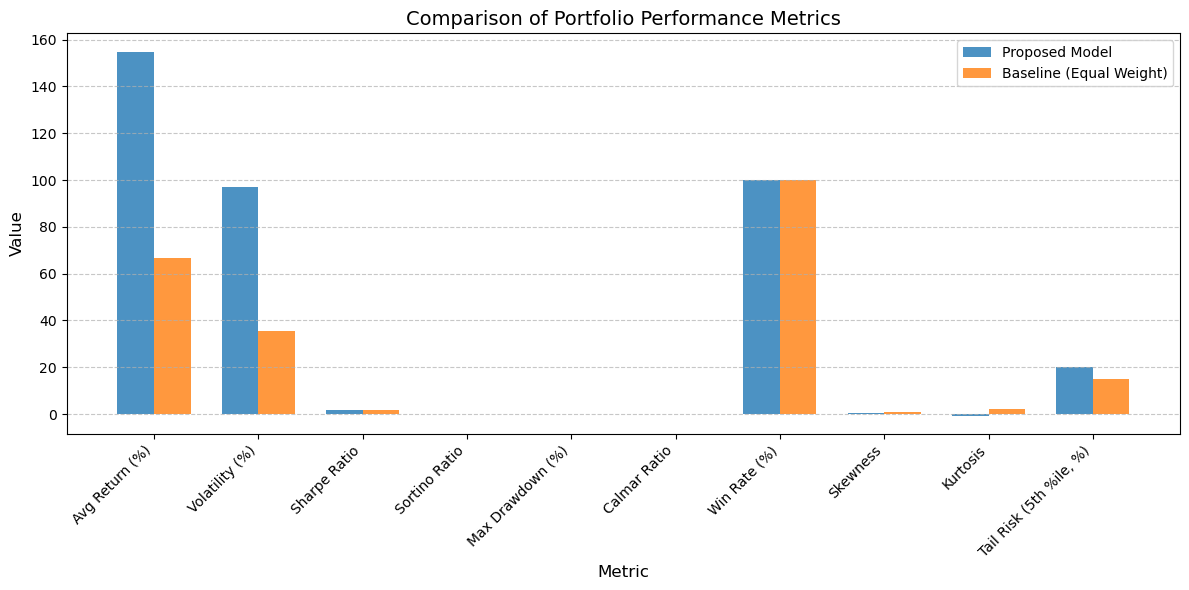

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for Proposed Model
model_data = {
    'Metric': [ 'Volatility (%)', 'Sharpe Ratio', 'Sortino Ratio',
               'Max Drawdown (%)', 'Calmar Ratio', 'Win Rate (%)', 'Skewness',
               'Kurtosis', 'Tail Risk (5th %ile, %)'],
    'Value': [35.289228 , 1.599804, 0.0, 0.0, 0.0, 100.0, 0.437731, -0.650454, 19.95]
}

# Data for Baseline (e.g., Equal Weight)
baseline_data = {
    'Metric': [ 'Volatility (%)', 'Sharpe Ratio', 'Sortino Ratio',
               'Max Drawdown (%)', 'Calmar Ratio', 'Win Rate (%)', 'Skewness',
               'Kurtosis', 'Tail Risk (5th %ile, %)'],
    'Value': [96.836840, 1.883861, 0.0, 0.0, 0.0, 100.0, 0.9346, 2.216049, 14.95]
}

# Convert to DataFrames
df_model = pd.DataFrame(model_data)
df_baseline = pd.DataFrame(baseline_data)

# Merge both for plotting
df_merged = df_model.copy()
df_merged['Baseline Value'] = df_baseline['Value']

# Plot settings
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
index = range(len(df_merged))

# Bars
ax.bar(index, df_merged['Value'], bar_width, label='Proposed Model', alpha=0.8)
ax.bar([i + bar_width for i in index], df_merged['Baseline Value'], bar_width, label='Baseline (Equal Weight)', alpha=0.8)

# Labels
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Comparison of Portfolio Performance Metrics', fontsize=14)
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(df_merged['Metric'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


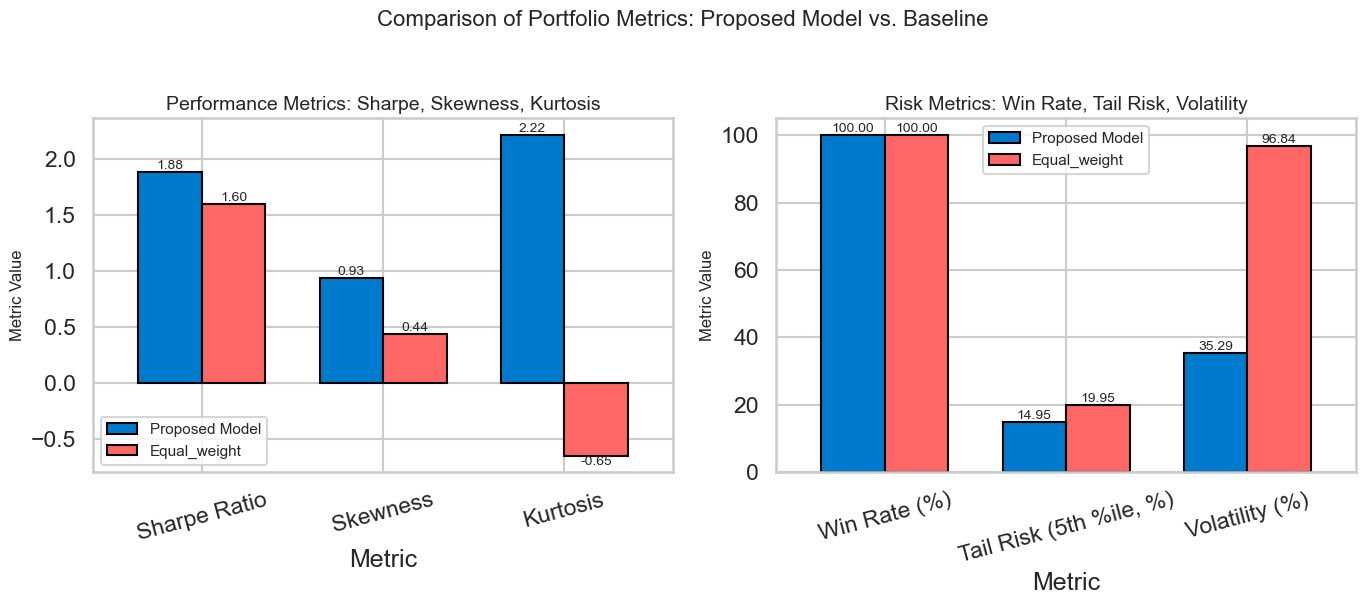

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set professional Seaborn style
sns.set(style="whitegrid", context="talk")

# Data
model_data = {
    'Metric': ['Volatility (%)', 'Sharpe Ratio', 'Sortino Ratio',
               'Max Drawdown (%)', 'Calmar Ratio', 'Win Rate (%)', 'Skewness',
               'Kurtosis', 'Tail Risk (5th %ile, %)'],
    'Value': [35.289228, 1.883861, 0.0, 0.0, 0.0, 100.0, 0.9346, 2.216049, 14.95]
}

baseline_data = {
    'Metric': ['Volatility (%)', 'Sharpe Ratio', 'Sortino Ratio',
               'Max Drawdown (%)', 'Calmar Ratio', 'Win Rate (%)', 'Skewness',
               'Kurtosis', 'Tail Risk (5th %ile, %)'],
    'Value': [96.836840, 1.599804, 0.0, 0.0, 0.0, 100.0, 0.437731, -0.650454, 19.95]
}

# Convert to DataFrames
df_model = pd.DataFrame(model_data).set_index('Metric')
df_baseline = pd.DataFrame(baseline_data).set_index('Metric')

# Select relevant metrics for each graph
graph1_metrics = ['Sharpe Ratio', 'Skewness', 'Kurtosis']
graph2_metrics = ['Win Rate (%)', 'Tail Risk (5th %ile, %)', 'Volatility (%)']

df_graph1 = pd.DataFrame({
    'Proposed Model': df_model.loc[graph1_metrics]['Value'],
    'Equal_weight': df_baseline.loc[graph1_metrics]['Value']
})

df_graph2 = pd.DataFrame({
    'Proposed Model': df_model.loc[graph2_metrics]['Value'],
    'Equal_weight': df_baseline.loc[graph2_metrics]['Value']
})

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bar_colors = ['#007acc', '#ff6666']

# --- Graph 1 ---
df_graph1.plot(kind='bar', ax=axes[0], color=bar_colors, width=0.7, edgecolor='black')
axes[0].set_title('Performance Metrics: Sharpe, Skewness, Kurtosis', fontsize=14)
axes[0].set_ylabel('Metric Value', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='best', fontsize=11)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

# --- Graph 2 ---
df_graph2.plot(kind='bar', ax=axes[1], color=bar_colors, width=0.7, edgecolor='black')
axes[1].set_title('Risk Metrics: Win Rate, Tail Risk, Volatility', fontsize=14)
axes[1].set_ylabel('Metric Value', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='best', fontsize=11)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

# Clean up
plt.suptitle('Comparison of Portfolio Metrics: Proposed Model vs. Baseline', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
result_GAT_PPO =  evaluate_model(model, feature_matrix_dup, closing_prices_dup, edge_index, num_episodes=100)

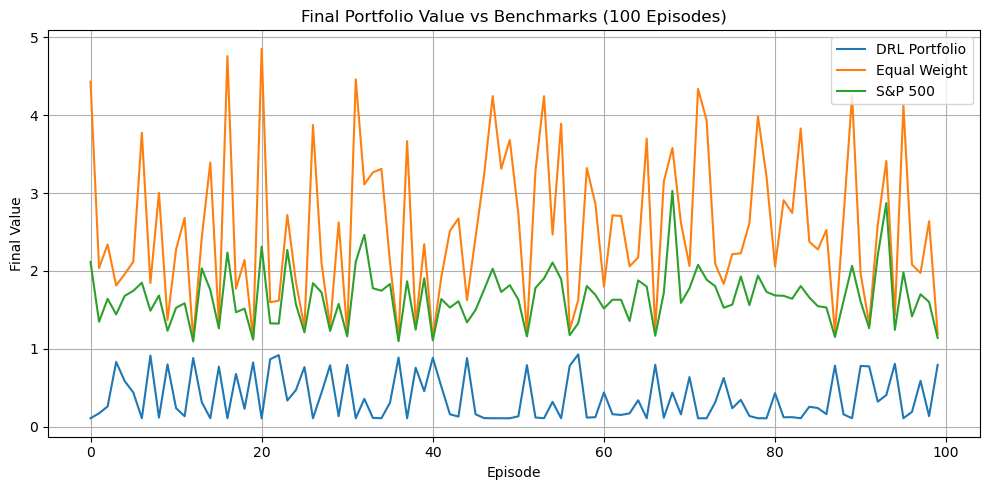

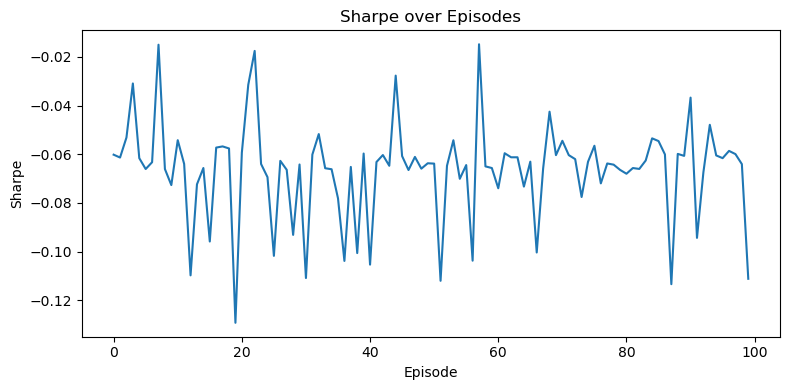

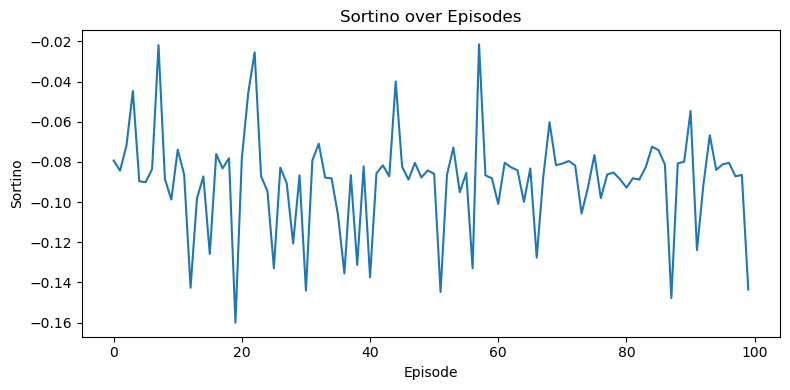

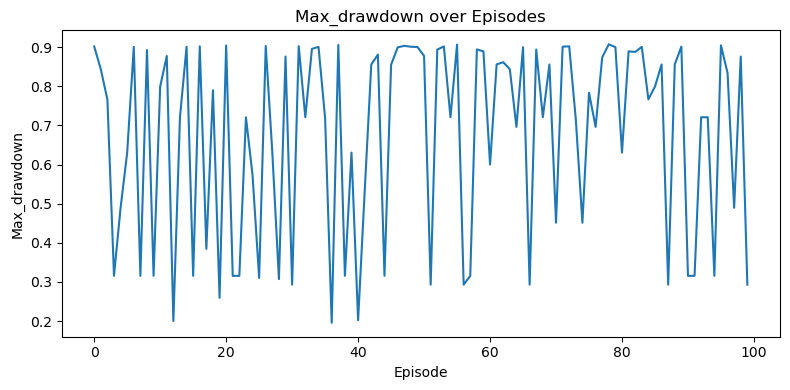

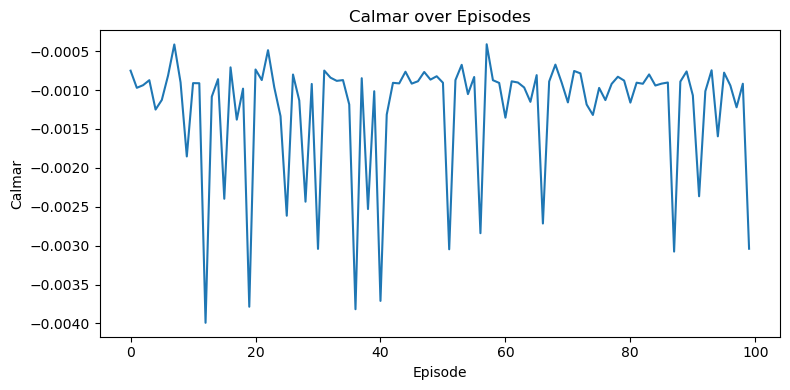

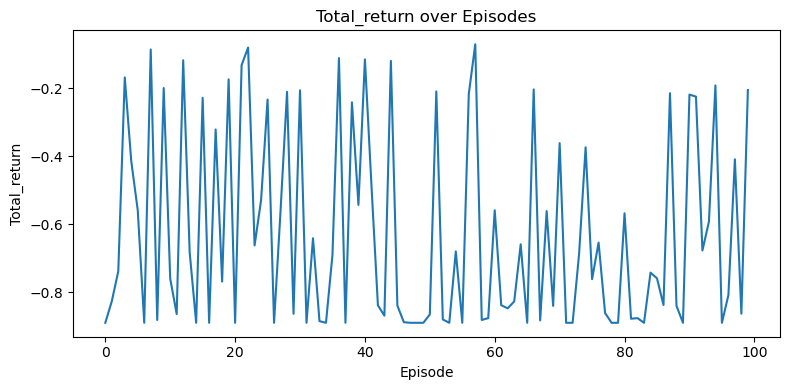

In [291]:
import matplotlib.pyplot as plt
import numpy as np

# STEP 1: Simulated dummy results (replace with actual evaluate_model output)
episodes = 100
np.random.seed(42)

# STEP 2: Plot portfolio values vs benchmarks
plt.figure(figsize=(10, 5))
plt.plot(results['portfolio_values'], label='DRL Portfolio')
plt.plot(results['equal_weight'], label='Equal Weight')
plt.plot(results['sp500'], label='S&P 500')
plt.title('Final Portfolio Value vs Benchmarks (100 Episodes)')
plt.xlabel('Episode')
plt.ylabel('Final Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 3: Plot each evaluation metric
metrics = ['sharpe', 'sortino', 'max_drawdown', 'calmar', 'total_return']
for metric in metrics:
    plt.figure(figsize=(8, 4))
    plt.plot(results[metric], label=metric)
    plt.title(f'{metric.capitalize()} over Episodes')
    plt.xlabel('Episode')
    plt.ylabel(metric.capitalize())
    plt.grid(False)
    plt.tight_layout()
    plt.show()


In [11]:
episodes = list(range(1, len(results['portfolio_values']) + 1))

#plt.plot(episodes, results['portfolio_values'], label="S&P 500", linewidth=2)
plt.plot(episodes, results['equal_weight'], label="PPO + GraphSAGE", linestyle='--')
plt.plot(episodes, results['sp500'], label="Equal Weight", linestyle=':')

plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.title("Portfolio Value Across Episodes")
plt.legend()
plt.tight_layout()
plt.savefig("portfolio_comparison.png")  # Save high-res image
plt.show()


NameError: name 'results' is not defined

ValueError: x and y must have same first dimension, but have shapes (1,) and (100,)

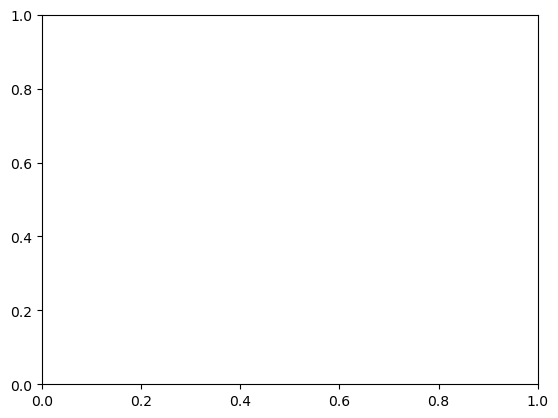

In [293]:
episodes = 25

plt.plot(episodes, results['portfolio_values'], label="S&P 500", linewidth=2)
plt.plot(episodes, results['equal_weight'], label="PPO + GraphSAGE", linestyle='--')
plt.plot(episodes, results['sp500'], label="Equal Weight", linestyle=':')

plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.title("Portfolio Value Across Episodes")
plt.legend()
plt.tight_layout()
plt.savefig("portfolio_comparison.png")  # Save high-res image
plt.show()


In [168]:
episodes = list(range(1, len(result_GAT_PPO['portfolio_values']) + 1))

plt.plot(episodes, results['portfolio_values'], label="PPO + GraphSAGE", linewidth=2)
plt.plot(episodes, results['equal_weight'], label="Equal Weight", linestyle='--')
plt.plot(episodes, results['sp500'], label="S&P 500", linestyle=':')

plt.xlabel("Episode")
plt.ylabel("Final Portfolio Value")
plt.title("Portfolio Value Across Episodes")
plt.legend()
plt.tight_layout()
plt.savefig("portfolio_comparison.png")  # Save high-res image
plt.show()


NameError: name 'result_GAT_PPO' is not defined

In [140]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class GATExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]

        self.gat1 = GATConv(self.node_features, 32, heads=4, concat=True, dropout=0.1)
        self.gat2 = GATConv(128, 64, heads=2, concat=True, dropout=0.1)

        self.mlp = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, features_dim)
        )

        self.dropout = nn.Dropout(0.2)
        self.apply(self._init_weights)

    def forward(self, obs):
        x = obs["x"]
        edge_index = obs["edge_index"]

        if x.dim() == 3:
            batch_data = Batch.from_data_list([
                Data(x=x[i], edge_index=edge_index[i].long()) for i in range(x.shape[0])
            ])
            x, edge_index, batch = batch_data.x, batch_data.edge_index, batch_data.batch
        else:
            edge_index = edge_index.long()
            batch = torch.zeros(x.size(0), dtype=torch.long).to(x.device)

        x = torch.relu(self.gat1(x, edge_index))
        x = torch.relu(self.gat2(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        return self.mlp(x)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)


import numpy as np
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from gat_extractor import GATExtractor
from your_environment_file import GraphPortfolioEnv  # replace with your actual file

class UnifiedCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)

    def _on_step(self) -> bool:
        return True

def train_ppo(feature_matrix, price_matrix, edge_index, total_timesteps=100_000):
    def make_env():
        return GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)
    
    env = DummyVecEnv([make_env])

    policy_kwargs = {
        "features_extractor_class": GATExtractor,
        "features_extractor_kwargs": {"features_dim": 128},
        "net_arch": dict(pi=[128, 64], vf=[128, 64]),
        "activation_fn": torch.nn.ReLU,
    }

    model = PPO(
        "MultiInputPolicy",
        env,
        policy_kwargs=policy_kwargs,
        verbose=1,
        tensorboard_log="./tensorboard/",
    )

    model.learn(total_timesteps=total_timesteps, callback=UnifiedCallback())
    model.save("ppo_graph_portfolio")
    return model

def evaluate_model(model, feature_matrix, price_matrix, edge_index, num_episodes=5):
    env = GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)

    results = {k: [] for k in ['portfolio', 'equal_weight', 'sp500', 'sharpe', 'sortino', 'max_drawdown', 'calmar', 'total_return']}

    for episode in range(num_episodes):
        obs = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs)
            obs, reward, done, info = env.step(action)

        metrics = info.get("metrics", {})
        results['portfolio'].append(info.get("portfolio_value", 0))
        results['equal_weight'].append(info["benchmarks"]["Equal Weight"])
        results['sp500'].append(info["benchmarks"]["S&P 500"])
        results['sharpe'].append(metrics.get("sharpe", 0))
        results['sortino'].append(metrics.get("sortino", 0))
        results['max_drawdown'].append(metrics.get("max_drawdown", 0))
        results['calmar'].append(metrics.get("calmar", 0))
        results['total_return'].append(metrics.get("total_return", 0))

    print("\n=== Aggregated Results ===")
    for k, v in results.items():
        print(f"{k}: {np.mean(v):.4f}")

    return results

from train_and_evaluate import train_ppo, evaluate_model
import numpy as np

feature_matrix_np =  feature_matrix.numpy()    # shape: [3361, 24, 31]
price_matrix_np = closing_prices.numpy()      # shape: [3361, 24]
edge_index_np =  edge_index.numpy()

model = train_ppo(feature_matrix_np, price_matrix_np, edge_index_np, total_timesteps=200_000)
evaluate_model(model, feature_matrix, price_matrix, edge_index, num_episodes=10)


ModuleNotFoundError: No module named 'gat_extractor'

In [146]:
import numpy as np
import gym
from gym import spaces
import torch
import torch.nn as nn
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt

# ========== GAT Feature Extractor ==========
class GATExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space['x'].shape[-1]

        self.gat1 = GATConv(self.node_features, 32, heads=4, concat=True, dropout=0.1)
        self.gat2 = GATConv(128, 64, heads=2, concat=True, dropout=0.1)

        self.mlp = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, features_dim)
        )

        self.dropout = nn.Dropout(0.2)
        self.apply(self._init_weights)

    def forward(self, obs):
        x = obs['x']
        edge_index = obs['edge_index']

        if x.dim() == 3:
            batch_data = Batch.from_data_list([
                Data(x=x[i], edge_index=edge_index[i].long()) for i in range(x.shape[0])
            ])
            x, edge_index, batch = batch_data.x, batch_data.edge_index, batch_data.batch
        else:
            edge_index = edge_index.long()
            batch = torch.zeros(x.size(0), dtype=torch.long).to(x.device)

        x = torch.relu(self.gat1(x, edge_index))
        x = torch.relu(self.gat2(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        return self.mlp(x)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)


# ========== PPO Callback ==========
class UnifiedCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
    def _on_step(self) -> bool:
        return True


# ========== Dummy Environment Placeholder ==========
class GraphPortfolioEnv(gym.Env):
    def __init__(self, feature_matrix, price_matrix, edge_index, initial_cash=1.0, trading_cost=0.0005):
        super().__init__()

        feature_matrix = np.array(feature_matrix)
        price_matrix = np.array(price_matrix)

        self.T, self.N, self.F = feature_matrix.shape

        if price_matrix.shape[0] < 2:
            raise ValueError("price_matrix must have at least 2 rows to compute log returns")

        log_returns = np.log(price_matrix[1:] / (price_matrix[:-1] + 1e-8))
        volatility = np.array([
            np.std(log_returns[i - 4:i + 1], axis=0) if i >= 4 else np.zeros_like(log_returns[0])
            for i in range(log_returns.shape[0])
        ])
        momentum = price_matrix[5:] / (price_matrix[:-5] + 1e-8)

        feature_matrix = feature_matrix[5:]
        min_len = min(feature_matrix.shape[0], momentum.shape[0], volatility.shape[0])
        self.feature_matrix = np.concatenate([
            feature_matrix[:min_len],
            momentum[:min_len, :, None],
            volatility[:min_len, :, None]
        ], axis=2)

        self.price_matrix = price_matrix[5:][:min_len]
        self.edge_index = torch.as_tensor(edge_index, dtype=torch.long)
        self.initial_cash = initial_cash
        self.trading_cost = trading_cost

        self.observation_space = spaces.Dict({
            "x": spaces.Box(-np.inf, np.inf, shape=(self.N, self.feature_matrix.shape[2]), dtype=np.float32),
            "edge_index": spaces.Box(0, self.N - 1, shape=(2, self.edge_index.shape[1]), dtype=np.int64)
        })
        self.action_space = spaces.Box(low=0, high=1, shape=(self.N,), dtype=np.float32)
        self.reset()

    def reset(self):
        self.t = 1
        self.portfolio_value = self.initial_cash
        self.weights = np.ones(self.N) / self.N
        self.history = [self.portfolio_value]
        return self._get_state()

    def step(self, action):
        weights = np.clip(action, 0, 1)
        weights = weights / (weights.sum() + 1e-8)
        prev_prices = self.price_matrix[self.t - 1]
        curr_prices = self.price_matrix[self.t]
        price_relatives = curr_prices / (prev_prices + 1e-8)
        weight_change = np.abs(weights - self.weights).sum()
        cost = self.trading_cost * weight_change
        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)

        self.portfolio_value = new_value
        self.weights = weights
        self.history.append(new_value)
        self.t += 1
        done = (self.t >= self.feature_matrix.shape[0] - 1)

        if done:
            ror = self.portfolio_value / self.initial_cash
            reward = np.log(ror + 1e-8) * 3.0
        else:
            reward = 0.0

        return self._get_state(), float(np.clip(reward, -1, 5)), done, {
            "portfolio_value": self.portfolio_value,
            "dr_agent": self.history
        }

    def _get_state(self):
        return {
            "x": torch.tensor(self.feature_matrix[self.t], dtype=torch.float32),
            "edge_index": self.edge_index
        }

from stable_baselines3.common.callbacks import EvalCallback
feature_matrix_np = np.array(feature_matrix)  # shape: [3361, 24, 31]
price_matrix_np = closing_prices.to_numpy()  # shape: [3361, 24]
edge_index_np = edge_index.numpy()
# Define an evaluation environment
eval_env = DummyVecEnv([lambda: GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)])

# Eval callback to evaluate and log every 5000 timesteps
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/",
    log_path="./logs/",
    eval_freq=5000,
    deterministic=True,
    render=False
)


# ========== PPO Training Function ==========
def train_ppo(feature_matrix, price_matrix, edge_index, total_timesteps=300_000):
    def make_env():
        return GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)

    env = DummyVecEnv([make_env])

    policy_kwargs = {
        "features_extractor_class": GATExtractor,
        "features_extractor_kwargs": {"features_dim": 128},
        "net_arch": dict(pi=[128, 64], vf=[128, 64]),
        "activation_fn": nn.ReLU,
    }

    model = PPO("MultiInputPolicy", env, policy_kwargs=policy_kwargs, verbose=1, n_steps=512, batch_size=64, ent_coef=0.005, clip_range=0.2, n_epochs=20)
    model.learn(total_timesteps=total_timesteps, callback=eval_callback)
    model.save("ppo_graph_portfolio")
    return model


# ========== Evaluation Function ==========
def evaluate_model(model, feature_matrix, price_matrix, edge_index, num_episodes=5):
    env = GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)
    results = []
    for _ in range(num_episodes):
        obs = env.reset()
        done = False
        while not done:
            obs_batched = {k: v[None] if isinstance(v, np.ndarray) else np.expand_dims(v, 0) for k, v in obs.items()}
            action, _ = model.predict(obs_batched)
            action = np.squeeze(action)  # Convert (1, 24) → (24,)

            obs, reward, done, info = env.step(action)
        results.append(info['portfolio_value'])
        plt.plot(info['dr_agent'], label='GAT+PPO Agent')

    # Equal weight benchmark
    equal_weight = np.ones(env.N) / env.N
    value = env.initial_cash
    eq_history = [value]
    for t in range(1, env.price_matrix.shape[0]):
        pr = env.price_matrix[t] / (env.price_matrix[t - 1] + 1e-8)
        value *= np.dot(pr, equal_weight)
        eq_history.append(value)

    plt.plot(eq_history, label='Equal Weight')
    plt.xlabel("Timesteps")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid()
    plt.title("Agent vs Equal Weight Benchmark")
    plt.show()
    print("Average Portfolio Value:", np.mean(results))
    return results


# ========== Main Entry Point ==========
if __name__ == "__main__":
    feature_matrix_np = np.array(feature_matrix)  # shape: [3361, 24, 31]
    price_matrix_np = closing_prices.to_numpy()  # shape: [3361, 24]
    edge_index_np = edge_index.numpy()

    model = train_ppo(feature_matrix_np, price_matrix_np, edge_index_np)
    evaluate_model(model, feature_matrix_np, price_matrix_np, edge_index_np)


NameError: name 'price_matrix' is not defined

In [154]:
import numpy as np
import gym
from gym import spaces
import torch
import torch.nn as nn
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
import matplotlib.pyplot as plt

# ========== GAT Feature Extractor ==========
class GATExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space['x'].shape[-1]

        self.gat1 = GATConv(self.node_features, 32, heads=4, concat=True, dropout=0.1)
        self.gat2 = GATConv(128, 64, heads=2, concat=True, dropout=0.1)

        self.mlp = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, features_dim)
        )

        self.dropout = nn.Dropout(0.2)
        self.apply(self._init_weights)

    def forward(self, obs):
        x = obs['x']
        edge_index = obs['edge_index']

        if x.dim() == 3:
            batch_data = Batch.from_data_list([
                Data(x=x[i], edge_index=edge_index[i].long()) for i in range(x.shape[0])
            ])
            x, edge_index, batch = batch_data.x, batch_data.edge_index, batch_data.batch
        else:
            edge_index = edge_index.long()
            batch = torch.zeros(x.size(0), dtype=torch.long).to(x.device)

        x = torch.relu(self.gat1(x, edge_index))
        x = torch.relu(self.gat2(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        return self.mlp(x)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)


# ========== PPO Callback ==========
class UnifiedCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
    def _on_step(self) -> bool:
        return True


# ========== Dummy Environment Placeholder ==========
class GraphPortfolioEnv(gym.Env):
    def __init__(self, feature_matrix, price_matrix, edge_index, initial_cash=1.0, trading_cost=0.0005):
        super().__init__()

        feature_matrix = np.array(feature_matrix)
        price_matrix = np.array(price_matrix)

        self.T, self.N, self.F = feature_matrix.shape

        if price_matrix.shape[0] < 2:
            raise ValueError("price_matrix must have at least 2 rows to compute log returns")

        log_returns = np.log(price_matrix[1:] / (price_matrix[:-1] + 1e-8))
        volatility = np.array([
            np.std(log_returns[i - 4:i + 1], axis=0) if i >= 4 else np.zeros_like(log_returns[0])
            for i in range(log_returns.shape[0])
        ])
        momentum = price_matrix[5:] / (price_matrix[:-5] + 1e-8)

        feature_matrix = feature_matrix[5:]
        min_len = min(feature_matrix.shape[0], momentum.shape[0], volatility.shape[0])
        self.feature_matrix = np.concatenate([
            feature_matrix[:min_len],
            momentum[:min_len, :, None],
            volatility[:min_len, :, None]
        ], axis=2)

        self.price_matrix = price_matrix[5:][:min_len]
        self.edge_index = torch.as_tensor(edge_index, dtype=torch.long)
        self.initial_cash = initial_cash
        self.trading_cost = trading_cost

        self.observation_space = spaces.Dict({
            "x": spaces.Box(-np.inf, np.inf, shape=(self.N, self.feature_matrix.shape[2]), dtype=np.float32),
            "edge_index": spaces.Box(0, self.N - 1, shape=(2, self.edge_index.shape[1]), dtype=np.int64)
        })
        self.action_space = spaces.Box(low=0, high=1, shape=(self.N,), dtype=np.float32)
        self.reset()

    def reset(self):
        self.t = 1
        self.portfolio_value = self.initial_cash
        self.weights = np.ones(self.N) / self.N
        self.history = [self.portfolio_value]
        self.metrics = {}
        self.benchmark_values = {}
        return self._get_state()

    def step(self, action):
        weights = np.clip(action, 0, 1)
        weights = weights / (weights.sum() + 1e-8)

        prev_prices = self.price_matrix[self.t - 1]
        curr_prices = self.price_matrix[self.t]
        price_relatives = curr_prices / (prev_prices + 1e-8)

        weight_change = np.abs(weights - self.weights).sum()
        cost = self.trading_cost * weight_change

        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        cost = self.trading_cost * np.sum(np.abs(self.weights - action))
        reward_raw = np.log(portfolio_return) if portfolio_return > 0 else -1.0

        reward = reward_raw - cost
        if reward > 0:
            reward += 0.005

        drawdown = max(0, (self.portfolio_value - new_value) / self.portfolio_value)
        reward -= 0.1 * drawdown

        self.portfolio_value = new_value
        self.weights = weights
        self.history.append(self.portfolio_value)
        self.t += 1

        done = (self.t >= self.T - 1)
        next_state = self._get_state() if not done else None

        info = {
            "portfolio_value": self.portfolio_value,
            "weights": self.weights,
            "metrics": self.metrics,
            "benchmarks": self.benchmark_values,
        }
        return next_state, float(np.clip(reward, -5, 5)), done, info

    def _get_state(self):
        return {
            "x": torch.tensor(self.feature_matrix[self.t], dtype=torch.float32),
            "edge_index": self.edge_index
        }

# ========== PPO Training Function ==========
def train_ppo(feature_matrix, price_matrix, edge_index, total_timesteps=300_000):
    def make_env():
        return GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)

    env = DummyVecEnv([make_env])
    eval_env = DummyVecEnv([make_env])

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path="./logs/",
        log_path="./logs/",
        eval_freq=5000,
        deterministic=True,
        render=False
    )

    policy_kwargs = {
        "features_extractor_class": GATExtractor,
        "features_extractor_kwargs": {"features_dim": 128},
        "net_arch": dict(pi=[128, 64], vf=[128, 64]),
        "activation_fn": nn.ReLU,
    }

    model = PPO("MultiInputPolicy", env, policy_kwargs=policy_kwargs, verbose=1, n_steps=512, batch_size=64, ent_coef=0.005, clip_range=0.2, n_epochs=20)
    model.learn(total_timesteps=total_timesteps, callback=eval_callback)
    model.save("ppo_graph_portfolio")
    return model

# ========== Evaluation Function ==========
def evaluate_model(model, feature_matrix, price_matrix, edge_index, num_episodes=5):
    env = GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)
    results = []
    for _ in range(num_episodes):
        obs = env.reset()
        done = False
        while not done:
            obs_batched = {k: v[None] if isinstance(v, np.ndarray) else np.expand_dims(v, 0) for k, v in obs.items()}
            action, _ = model.predict(obs_batched)
            action = np.squeeze(action)
            obs, reward, done, info = env.step(action)
        results.append(info['portfolio_value'])
        plt.plot(env.history, label='GAT+PPO Agent')

    equal_weight = np.ones(env.N) / env.N
    value = env.initial_cash
    eq_history = [value]
    for t in range(1, env.price_matrix.shape[0]):
        pr = env.price_matrix[t] / (env.price_matrix[t - 1] + 1e-8)
        value *= np.dot(pr, equal_weight)
        eq_history.append(value)

    plt.plot(eq_history, label='Equal Weight')
    plt.xlabel("Timesteps")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid()
    plt.title("Agent vs Equal Weight Benchmark")
    plt.show()
    print("Average Portfolio Value:", np.mean(results))
    return results

# ========== Main Entry Point ==========
if __name__ == "__main__":
    feature_matrix_np = np.array(feature_matrix)
    price_matrix_np = closing_prices.to_numpy()
    edge_index_np = edge_index

    model = train_ppo(feature_matrix_np, price_matrix_np, edge_index_np)
    evaluate_model(model, feature_matrix_np, price_matrix_np, edge_index_np)

Using cpu device
----------------------------
| time/              |     |
|    fps             | 117 |
|    iterations      | 1   |
|    time_elapsed    | 4   |
|    total_timesteps | 512 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 77          |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.016929492 |
|    clip_fraction        | 0.19        |
|    clip_range           | 0.2         |
|    entropy_loss         | -34         |
|    explained_variance   | -0.0043     |
|    learning_rate        | 0.0003      |
|    loss                 | -0.21       |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0266     |
|    std                  | 0.997       |
|    value_loss           | 0.0024      |
------------------------

IndexError: index 3356 is out of bounds for axis 0 with size 3356

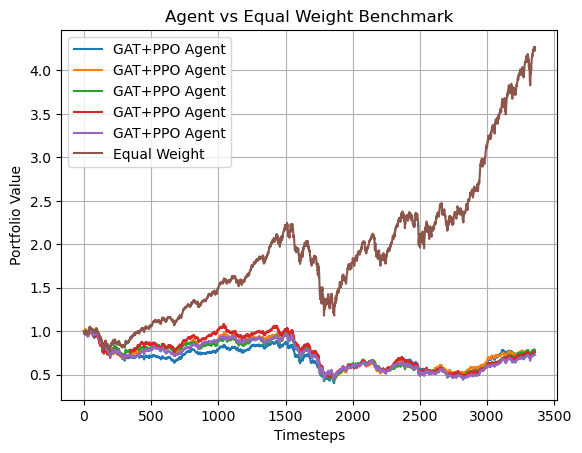

Average Portfolio Value: 0.762317663245723


[0.7608201464846039,
 0.7808489051438202,
 0.7849081877247607,
 0.7561977640156216,
 0.7288133128598089]

In [180]:
def evaluate_model(model, feature_matrix, price_matrix, edge_index, num_episodes=5):
    env = GraphPortfolioEnv(feature_matrix, price_matrix, edge_index)
    results = []
    for _ in range(num_episodes):
        obs = env.reset()
        done = False
        while not done:
            obs_batched = {k: v[None] if isinstance(v, np.ndarray) else np.expand_dims(v, 0) for k, v in obs.items()}
            action, _ = model.predict(obs_batched)
            action = np.squeeze(action)  # Convert (1, 24) → (24,)

            obs, reward, done, info = env.step(action)
        results.append(info['portfolio_value'])
        plt.plot(info['dr_agent'], label='GAT+PPO Agent')

    # Equal weight benchmark
    equal_weight = np.ones(env.N) / env.N
    value = env.initial_cash
    eq_history = [value]
    for t in range(1, env.price_matrix.shape[0]):
        pr = env.price_matrix[t] / (env.price_matrix[t - 1] + 1e-8)
        value *= np.dot(pr, equal_weight)
        eq_history.append(value)

    plt.plot(eq_history, label='Equal Weight')
    plt.xlabel("Timesteps")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid()
    plt.title("Agent vs Equal Weight Benchmark")
    plt.show()
    print("Average Portfolio Value:", np.mean(results))
    return results

evaluate_model(model, feature_matrix_np, price_matrix_np, edge_index_np)

In [174]:
evaluate_model(model,feature_matrix_np, price_matrix_np, edge_index_np)

ValueError: Error: Unexpected observation shape (24, 33) for Box environment, please use (24, 31) or (n_env, 24, 31) for the observation shape.

In [135]:
import re
import pandas as pd

log_text = """

---------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | -55.3      |
| time/                   |            |
|    fps                  | 39         |
|    iterations           | 2          |
|    time_elapsed         | 102        |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.09796457 |
|    clip_fraction        | 0.142      |
|    clip_range           | 0.5        |
|    entropy_loss         | -33.7      |
|    explained_variance   | 0.0377     |
|    learning_rate        | 0.001      |
|    loss                 | -0.0374    |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0403    |
|    std                  | 0.981      |
|    value_loss           | 0.00388    |
----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.36e+03    |
|    ep_rew_mean          | -55.3       |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 3           |
|    time_elapsed         | 205         |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.098133184 |
|    clip_fraction        | 0.164       |
|    clip_range           | 0.5         |
|    entropy_loss         | -33.5       |
|    explained_variance   | 0.0927      |
|    learning_rate        | 0.001       |
|    loss                 | 0.00396     |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0452     |
|    std                  | 0.975       |
|    value_loss           | 0.00643     |
-----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | -52.4      |
| time/                   |            |
|    fps                  | 26         |
|    iterations           | 4          |
|    time_elapsed         | 313        |
|    total_timesteps      | 8192       |
| train/                  |            |
|    approx_kl            | 0.11976069 |
|    clip_fraction        | 0.184      |
|    clip_range           | 0.5        |
|    entropy_loss         | -33.2      |
|    explained_variance   | 0.455      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0873    |
|    n_updates            | 30         |
|    policy_gradient_loss | -0.0451    |
|    std                  | 0.961      |
|    value_loss           | 0.00404    |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | -49.6      |
| time/                   |            |
|    fps                  | 22         |
|    iterations           | 5          |
|    time_elapsed         | 449        |
|    total_timesteps      | 10240      |
| train/                  |            |
|    approx_kl            | 0.15643641 |
|    clip_fraction        | 0.238      |
|    clip_range           | 0.5        |
|    entropy_loss         | -32.8      |
|    explained_variance   | 0.277      |
|    learning_rate        | 0.001      |
|    loss                 | -0.105     |
|    n_updates            | 40         |
|    policy_gradient_loss | -0.0529    |
|    std                  | 0.944      |
|    value_loss           | 0.00616    |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | -49.6      |
| time/                   |            |
|    fps                  | 20         |
|    iterations           | 6          |
|    time_elapsed         | 611        |
|    total_timesteps      | 12288      |
| train/                  |            |
|    approx_kl            | 0.11388605 |
|    clip_fraction        | 0.177      |
|    clip_range           | 0.5        |
|    entropy_loss         | -32.3      |
|    explained_variance   | 0.0854     |
|    learning_rate        | 0.001      |
|    loss                 | -0.0595    |
|    n_updates            | 50         |
|    policy_gradient_loss | -0.0402    |
|    std                  | 0.926      |
|    value_loss           | 0.00882    |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | -46.8      |
| time/                   |            |
|    fps                  | 16         |
|    iterations           | 7          |
|    time_elapsed         | 869        |
|    total_timesteps      | 14336      |
| train/                  |            |
|    approx_kl            | 0.15735996 |
|    clip_fraction        | 0.235      |
|    clip_range           | 0.5        |
|    entropy_loss         | -32        |
|    explained_variance   | 0.452      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0768    |
|    n_updates            | 60         |
|    policy_gradient_loss | -0.0479    |
|    std                  | 0.916      |
|    value_loss           | 0.00362    |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | -46.8      |
| time/                   |            |
|    fps                  | 13         |
|    iterations           | 8          |
|    time_elapsed         | 1189       |
|    total_timesteps      | 16384      |
| train/                  |            |
|    approx_kl            | 0.16530026 |
|    clip_fraction        | 0.218      |
|    clip_range           | 0.5        |
|    entropy_loss         | -31.8      |
|    explained_variance   | 0.432      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0523    |
|    n_updates            | 70         |
|    policy_gradient_loss | -0.0431    |
|    std                  | 0.907      |
|    value_loss           | 0.00698    |
----------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | -44.6     |
| time/                   |           |
|    fps                  | 11        |
|    iterations           | 9         |
|    time_elapsed         | 1541      |
|    total_timesteps      | 18432     |
| train/                  |           |
|    approx_kl            | 0.1313352 |
|    clip_fraction        | 0.216     |
|    clip_range           | 0.5       |
|    entropy_loss         | -31.5     |
|    explained_variance   | 0.53      |
|    learning_rate        | 0.001     |
|    loss                 | -0.0245   |
|    n_updates            | 80        |
|    policy_gradient_loss | -0.0442   |
|    std                  | 0.896     |
|    value_loss           | 0.00449   |
---------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 7.74       |
| time/                   |            |
|    fps                  | 50         |
|    iterations           | 2          |
|    time_elapsed         | 80         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.25071952 |
|    clip_fraction        | 0.379      |
|    clip_range           | 0.5        |
|    entropy_loss         | -26.6      |
|    explained_variance   | 0.422      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0886    |
|    n_updates            | 260        |
|    policy_gradient_loss | -0.0332    |
|    std                  | 0.741      |
|    value_loss           | 0.0113     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 7.74       |
| time/                   |            |
|    fps                  | 35         |
|    iterations           | 3          |
|    time_elapsed         | 175        |
|    total_timesteps      | 6144       |
| train/                  |            |
|    approx_kl            | 0.27725416 |
|    clip_fraction        | 0.333      |
|    clip_range           | 0.5        |
|    entropy_loss         | -26.4      |
|    explained_variance   | 0.429      |
|    learning_rate        | 0.001      |
|    loss                 | -0.15      |
|    n_updates            | 270        |
|    policy_gradient_loss | -0.0369    |
|    std                  | 0.736      |
|    value_loss           | 0.00985    |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 9.04       |
| time/                   |            |
|    fps                  | 28         |
|    iterations           | 4          |
|    time_elapsed         | 284        |
|    total_timesteps      | 8192       |
| train/                  |            |
|    approx_kl            | 0.30983034 |
|    clip_fraction        | 0.363      |
|    clip_range           | 0.5        |
|    entropy_loss         | -26.2      |
|    explained_variance   | 0.559      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0312    |
|    n_updates            | 280        |
|    policy_gradient_loss | -0.0443    |
|    std                  | 0.725      |
|    value_loss           | 0.0129     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 9.94       |
| time/                   |            |
|    fps                  | 21         |
|    iterations           | 5          |
|    time_elapsed         | 477        |
|    total_timesteps      | 10240      |
| train/                  |            |
|    approx_kl            | 0.35027534 |
|    clip_fraction        | 0.394      |
|    clip_range           | 0.5        |
|    entropy_loss         | -26        |
|    explained_variance   | 0.554      |
|    learning_rate        | 0.001      |
|    loss                 | -0.00173   |
|    n_updates            | 290        |
|    policy_gradient_loss | -0.0359    |
|    std                  | 0.725      |
|    value_loss           | 0.0206     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 9.94       |
| time/                   |            |
|    fps                  | 18         |
|    iterations           | 6          |
|    time_elapsed         | 653        |
|    total_timesteps      | 12288      |
| train/                  |            |
|    approx_kl            | 0.22927944 |
|    clip_fraction        | 0.342      |
|    clip_range           | 0.5        |
|    entropy_loss         | -25.8      |
|    explained_variance   | 0.48       |
|    learning_rate        | 0.001      |
|    loss                 | -0.00641   |
|    n_updates            | 300        |
|    policy_gradient_loss | -0.0466    |
|    std                  | 0.717      |
|    value_loss           | 0.0298     |
----------------------------------------
--------------------------------------
| rollout/                |          |
|    ep_len_mean          | 3.36e+03 |
|    ep_rew_mean          | 9.18     |
| time/                   |          |
|    fps                  | 16       |
|    iterations           | 7        |
|    time_elapsed         | 862      |
|    total_timesteps      | 14336    |
| train/                  |          |
|    approx_kl            | 0.507403 |
|    clip_fraction        | 0.431    |
|    clip_range           | 0.5      |
|    entropy_loss         | -25.8    |
|    explained_variance   | 0.647    |
|    learning_rate        | 0.001    |
|    loss                 | 0.0704   |
|    n_updates            | 310      |
|    policy_gradient_loss | -0.047   |
|    std                  | 0.718    |
|    value_loss           | 0.0178   |
--------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 9.18       |
| time/                   |            |
|    fps                  | 15         |
|    iterations           | 8          |
|    time_elapsed         | 1076       |
|    total_timesteps      | 16384      |
| train/                  |            |
|    approx_kl            | 0.28477708 |
|    clip_fraction        | 0.394      |
|    clip_range           | 0.5        |
|    entropy_loss         | -25.7      |
|    explained_variance   | 0.633      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0167    |
|    n_updates            | 320        |
|    policy_gradient_loss | -0.0257    |
|    std                  | 0.718      |
|    value_loss           | 0.0196     |
----------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | 10        |
| time/                   |           |
|    fps                  | 13        |
|    iterations           | 9         |
|    time_elapsed         | 1351      |
|    total_timesteps      | 18432     |
| train/                  |           |
|    approx_kl            | 0.2930404 |
|    clip_fraction        | 0.369     |
|    clip_range           | 0.5       |
|    entropy_loss         | -25.5     |
|    explained_variance   | 0.661     |
|    learning_rate        | 0.001     |
|    loss                 | 0.0051    |
|    n_updates            | 330       |
|    policy_gradient_loss | -0.0388   |
|    std                  | 0.709     |
|    value_loss           | 0.011     |
---------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 9.89       |
| time/                   |            |
|    fps                  | 12         |
|    iterations           | 10         |
|    time_elapsed         | 1670       |
|    total_timesteps      | 20480      |
| train/                  |            |
|    approx_kl            | 0.46902156 |
|    clip_fraction        | 0.417      |
|    clip_range           | 0.5        |
|    entropy_loss         | -25.4      |
|    explained_variance   | 0.113      |
|    learning_rate        | 0.001      |
|    loss                 | 0.038      |
|    n_updates            | 340        |
|    policy_gradient_loss | -0.0451    |
|    std                  | 0.706      |
|    value_loss           | 0.0146     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 9.89       |
| time/                   |            |
|    fps                  | 10         |
|    iterations           | 11         |
|    time_elapsed         | 2076       |
|    total_timesteps      | 22528      |
| train/                  |            |
|    approx_kl            | 0.30584756 |
|    clip_fraction        | 0.37       |
|    clip_range           | 0.5        |
|    entropy_loss         | -25.3      |
|    explained_variance   | 0.404      |
|    learning_rate        | 0.001      |
|    loss                 | -0.194     |
|    n_updates            | 350        |
|    policy_gradient_loss | -0.0338    |
|    std                  | 0.702      |
|    value_loss           | 0.0205     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 9.8        |
| time/                   |            |
|    fps                  | 9          |
|    iterations           | 12         |
|    time_elapsed         | 2532       |
|    total_timesteps      | 24576      |
| train/                  |            |
|    approx_kl            | 0.34723288 |
|    clip_fraction        | 0.419      |
|    clip_range           | 0.5        |
|    entropy_loss         | -25        |
|    explained_variance   | 0.619      |
|    learning_rate        | 0.001      |
|    loss                 | 0.047      |
|    n_updates            | 360        |
|    policy_gradient_loss | -0.0274    |
|    std                  | 0.696      |
|    value_loss           | 0.0171     |
----------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | 9.8       |
| time/                   |           |
|    fps                  | 8         |
|    iterations           | 13        |
|    time_elapsed         | 2994      |
|    total_timesteps      | 26624     |
| train/                  |           |
|    approx_kl            | 0.2611233 |
|    clip_fraction        | 0.376     |
|    clip_range           | 0.5       |
|    entropy_loss         | -24.8     |
|    explained_variance   | 0.526     |
|    learning_rate        | 0.001     |
|    loss                 | -0.0963   |
|    n_updates            | 370       |
|    policy_gradient_loss | -0.0204   |
|    std                  | 0.692     |
|    value_loss           | 0.0174    |
---------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 10.1       |
| time/                   |            |
|    fps                  | 8          |
|    iterations           | 14         |
|    time_elapsed         | 3503       |
|    total_timesteps      | 28672      |
| train/                  |            |
|    approx_kl            | 0.32369104 |
|    clip_fraction        | 0.395      |
|    clip_range           | 0.5        |
|    entropy_loss         | -24.6      |
|    explained_variance   | 0.628      |
|    learning_rate        | 0.001      |
|    loss                 | 0.0158     |
|    n_updates            | 380        |
|    policy_gradient_loss | -0.0397    |
|    std                  | 0.682      |
|    value_loss           | 0.0116     |
----------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | 10.3      |
| time/                   |           |
|    fps                  | 7         |
|    iterations           | 15        |
|    time_elapsed         | 4057      |
|    total_timesteps      | 30720     |
| train/                  |           |
|    approx_kl            | 0.6197213 |
|    clip_fraction        | 0.485     |
|    clip_range           | 0.5       |
|    entropy_loss         | -24.4     |
|    explained_variance   | 0.397     |
|    learning_rate        | 0.001     |
|    loss                 | -0.0922   |
|    n_updates            | 390       |
|    policy_gradient_loss | -0.0504   |
|    std                  | 0.677     |
|    value_loss           | 0.0195    |
---------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 10.3       |
| time/                   |            |
|    fps                  | 7          |
|    iterations           | 16         |
|    time_elapsed         | 4650       |
|    total_timesteps      | 32768      |
| train/                  |            |
|    approx_kl            | 0.24589118 |
|    clip_fraction        | 0.33       |
|    clip_range           | 0.5        |
|    entropy_loss         | -24.3      |
|    explained_variance   | 0.524      |
|    learning_rate        | 0.001      |
|    loss                 | 0.0439     |
|    n_updates            | 400        |
|    policy_gradient_loss | -0.0235    |
|    std                  | 0.68       |
|    value_loss           | 0.0135     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 10.6       |
| time/                   |            |
|    fps                  | 6          |
|    iterations           | 17         |
|    time_elapsed         | 5282       |
|    total_timesteps      | 34816      |
| train/                  |            |
|    approx_kl            | 0.36148515 |
|    clip_fraction        | 0.424      |
|    clip_range           | 0.5        |
|    entropy_loss         | -24.4      |
|    explained_variance   | 0.695      |
|    learning_rate        | 0.001      |
|    loss                 | 0.0275     |
|    n_updates            | 410        |
|    policy_gradient_loss | -0.0343    |
|    std                  | 0.679      |
|    value_loss           | 0.0127     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 10.6       |
| time/                   |            |
|    fps                  | 6          |
|    iterations           | 18         |
|    time_elapsed         | 5847       |
|    total_timesteps      | 36864      |
| train/                  |            |
|    approx_kl            | 0.32981506 |
|    clip_fraction        | 0.391      |
|    clip_range           | 0.5        |
|    entropy_loss         | -24.1      |
|    explained_variance   | 0.637      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0675    |
|    n_updates            | 420        |
|    policy_gradient_loss | -0.0265    |
|    std                  | 0.668      |
|    value_loss           | 0.0147     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 11         |
| time/                   |            |
|    fps                  | 6          |
|    iterations           | 19         |
|    time_elapsed         | 6401       |
|    total_timesteps      | 38912      |
| train/                  |            |
|    approx_kl            | 0.29818818 |
|    clip_fraction        | 0.386      |
|    clip_range           | 0.5        |
|    entropy_loss         | -24        |
|    explained_variance   | 0.491      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0093    |
|    n_updates            | 430        |
|    policy_gradient_loss | -0.023     |
|    std                  | 0.667      |
|    value_loss           | 0.0106     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 11.7       |
| time/                   |            |
|    fps                  | 5          |
|    iterations           | 20         |
|    time_elapsed         | 7022       |
|    total_timesteps      | 40960      |
| train/                  |            |
|    approx_kl            | 0.32729763 |
|    clip_fraction        | 0.429      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.9      |
|    explained_variance   | 0.47       |
|    learning_rate        | 0.001      |
|    loss                 | -0.0913    |
|    n_updates            | 440        |
|    policy_gradient_loss | -0.00384   |
|    std                  | 0.666      |
|    value_loss           | 0.0298     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 11.7       |
| time/                   |            |
|    fps                  | 5          |
|    iterations           | 21         |
|    time_elapsed         | 7614       |
|    total_timesteps      | 43008      |
| train/                  |            |
|    approx_kl            | 0.23641232 |
|    clip_fraction        | 0.358      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.9      |
|    explained_variance   | 0.629      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0954    |
|    n_updates            | 450        |
|    policy_gradient_loss | -0.0207    |
|    std                  | 0.671      |
|    value_loss           | 0.0147     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 12.4       |
| time/                   |            |
|    fps                  | 5          |
|    iterations           | 22         |
|    time_elapsed         | 8286       |
|    total_timesteps      | 45056      |
| train/                  |            |
|    approx_kl            | 0.28491247 |
|    clip_fraction        | 0.37       |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.9      |
|    explained_variance   | 0.65       |
|    learning_rate        | 0.001      |
|    loss                 | -0.0958    |
|    n_updates            | 460        |
|    policy_gradient_loss | -0.0143    |
|    std                  | 0.663      |
|    value_loss           | 0.0139     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 12.7       |
| time/                   |            |
|    fps                  | 5          |
|    iterations           | 23         |
|    time_elapsed         | 9029       |
|    total_timesteps      | 47104      |
| train/                  |            |
|    approx_kl            | 0.30773303 |
|    clip_fraction        | 0.427      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.8      |
|    explained_variance   | 0.234      |
|    learning_rate        | 0.001      |
|    loss                 | -0.144     |
|    n_updates            | 470        |
|    policy_gradient_loss | -0.0371    |
|    std                  | 0.661      |
|    value_loss           | 0.0324     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 12.7       |
| time/                   |            |
|    fps                  | 4          |
|    iterations           | 24         |
|    time_elapsed         | 9898       |
|    total_timesteps      | 49152      |
| train/                  |            |
|    approx_kl            | 0.27702725 |
|    clip_fraction        | 0.349      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.6      |
|    explained_variance   | 0.288      |
|    learning_rate        | 0.001      |
|    loss                 | 0.00746    |
|    n_updates            | 480        |
|    policy_gradient_loss | -0.0376    |
|    std                  | 0.655      |
|    value_loss           | 0.0233     |
----------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | 13.3      |
| time/                   |           |
|    fps                  | 4         |
|    iterations           | 25        |
|    time_elapsed         | 10808     |
|    total_timesteps      | 51200     |
| train/                  |           |
|    approx_kl            | 0.3166808 |
|    clip_fraction        | 0.436     |
|    clip_range           | 0.5       |
|    entropy_loss         | -23.5     |
|    explained_variance   | 0.471     |
|    learning_rate        | 0.001     |
|    loss                 | -0.166    |
|    n_updates            | 490       |
|    policy_gradient_loss | -0.0262   |
|    std                  | 0.656     |
|    value_loss           | 0.0195    |
---------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 13.3       |
| time/                   |            |
|    fps                  | 4          |
|    iterations           | 26         |
|    time_elapsed         | 11777      |
|    total_timesteps      | 53248      |
| train/                  |            |
|    approx_kl            | 0.29561988 |
|    clip_fraction        | 0.373      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.6      |
|    explained_variance   | 0.525      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0513    |
|    n_updates            | 500        |
|    policy_gradient_loss | -0.0255    |
|    std                  | 0.658      |
|    value_loss           | 0.0138     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 13.9       |
| time/                   |            |
|    fps                  | 4          |
|    iterations           | 27         |
|    time_elapsed         | 13255      |
|    total_timesteps      | 55296      |
| train/                  |            |
|    approx_kl            | 0.21994199 |
|    clip_fraction        | 0.305      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.5      |
|    explained_variance   | 0.716      |
|    learning_rate        | 0.001      |
|    loss                 | -0.101     |
|    n_updates            | 510        |
|    policy_gradient_loss | -0.0216    |
|    std                  | 0.653      |
|    value_loss           | 0.0148     |
----------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | 14        |
| time/                   |           |
|    fps                  | 4         |
|    iterations           | 28        |
|    time_elapsed         | 14227     |
|    total_timesteps      | 57344     |
| train/                  |           |
|    approx_kl            | 0.3093779 |
|    clip_fraction        | 0.426     |
|    clip_range           | 0.5       |
|    entropy_loss         | -23.4     |
|    explained_variance   | 0.309     |
|    learning_rate        | 0.001     |
|    loss                 | -0.0483   |
|    n_updates            | 520       |
|    policy_gradient_loss | -0.0227   |
|    std                  | 0.652     |
|    value_loss           | 0.0393    |
---------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 14         |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 29         |
|    time_elapsed         | 15669      |
|    total_timesteps      | 59392      |
| train/                  |            |
|    approx_kl            | 0.21531928 |
|    clip_fraction        | 0.324      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.4      |
|    explained_variance   | 0.576      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0632    |
|    n_updates            | 530        |
|    policy_gradient_loss | -0.0336    |
|    std                  | 0.651      |
|    value_loss           | 0.0196     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 14.3       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 30         |
|    time_elapsed         | 16492      |
|    total_timesteps      | 61440      |
| train/                  |            |
|    approx_kl            | 0.29832953 |
|    clip_fraction        | 0.384      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.4      |
|    explained_variance   | 0.586      |
|    learning_rate        | 0.001      |
|    loss                 | 0.0219     |
|    n_updates            | 540        |
|    policy_gradient_loss | -0.0187    |
|    std                  | 0.652      |
|    value_loss           | 0.0377     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 14.3       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 31         |
|    time_elapsed         | 17333      |
|    total_timesteps      | 63488      |
| train/                  |            |
|    approx_kl            | 0.27230686 |
|    clip_fraction        | 0.367      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23.2      |
|    explained_variance   | 0.722      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0835    |
|    n_updates            | 550        |
|    policy_gradient_loss | -0.0209    |
|    std                  | 0.644      |
|    value_loss           | 0.0147     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 14.9       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 32         |
|    time_elapsed         | 18467      |
|    total_timesteps      | 65536      |
| train/                  |            |
|    approx_kl            | 0.22863644 |
|    clip_fraction        | 0.327      |
|    clip_range           | 0.5        |
|    entropy_loss         | -23        |
|    explained_variance   | 0.723      |
|    learning_rate        | 0.001      |
|    loss                 | -0.0491    |
|    n_updates            | 560        |
|    policy_gradient_loss | -0.0356    |
|    std                  | 0.642      |
|    value_loss           | 0.0153     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 15.4       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 33         |
|    time_elapsed         | 19625      |
|    total_timesteps      | 67584      |
| train/                  |            |
|    approx_kl            | 0.41835752 |
|    clip_fraction        | 0.444      |
|    clip_range           | 0.5        |
|    entropy_loss         | -22.9      |
|    explained_variance   | 0.411      |
|    learning_rate        | 0.001      |
|    loss                 | 0.141      |
|    n_updates            | 570        |
|    policy_gradient_loss | -0.0283    |
|    std                  | 0.639      |
|    value_loss           | 0.0349     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 15.4       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 34         |
|    time_elapsed         | 20627      |
|    total_timesteps      | 69632      |
| train/                  |            |
|    approx_kl            | 0.23765576 |
|    clip_fraction        | 0.336      |
|    clip_range           | 0.5        |
|    entropy_loss         | -22.7      |
|    explained_variance   | 0.614      |
|    learning_rate        | 0.001      |
|    loss                 | 0.158      |
|    n_updates            | 580        |
|    policy_gradient_loss | -0.0199    |
|    std                  | 0.634      |
|    value_loss           | 0.0151     |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | 15.9       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 35         |
|    time_elapsed         | 21596      |
|    total_timesteps      | 71680      |
| train/                  |            |
|    approx_kl            | 0.26342392 |
|    clip_fraction        | 0.346      |
|    clip_range           | 0.5        |
|    entropy_loss         | -22.5      |
|    explained_variance   | 0.79       |
|    learning_rate        | 0.001      |
|    loss                 | 0.0401     |
|    n_updates            | 590        |
|    policy_gradient_loss | -0.0184    |
|    std                  | 0.63       |
|    value_loss           | 0.0103     |
----------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | 15.9      |
| time/                   |           |
|    fps                  | 3         |
|    iterations           | 36        |
|    time_elapsed         | 22772     |
|    total_timesteps      | 73728     |
| train/                  |           |
|    approx_kl            | 0.2864674 |
|    clip_fraction        | 0.379     |
|    clip_range           | 0.5       |
|    entropy_loss         | -22.5     |
|    explained_variance   | 0.582     |
|    learning_rate        | 0.001     |
|    loss                 | 0.0566    |
|    n_updates            | 600       |
|    policy_gradient_loss | -0.03     |
|    std                  | 0.632     |
|    value_loss           | 0.0147    |
---------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | 16.3      |
| time/                   |           |
|    fps                  | 3         |
|    iterations           | 37        |
|    time_elapsed         | 24057     |
|    total_timesteps      | 75776     |
| train/                  |           |
|    approx_kl            | 0.2609269 |
|    clip_fraction        | 0.356     |
|    clip_range           | 0.5       |
|    entropy_loss         | -22.5     |
|    explained_variance   | 0.553     |
|    learning_rate        | 0.001     |
|    loss                 | 0.0169    |
|    n_updates            | 610       |
|    policy_gradient_loss | -0.0249   |
|    std                  | 0.635     |
|    value_loss           | 0.0146    |
---------------------------------------
"""


import re
import pandas as pd
import matplotlib.pyplot as plt

# Extract all metrics using regex
metrics = {
    'timesteps': re.findall(r"total_timesteps\s+\|\s+(\d+)", log_text),
    'approx_kl': re.findall(r"approx_kl\s+\|\s+([\d.]+)", log_text),
    'clip_fraction': re.findall(r"clip_fraction\s+\|\s+([\d.]+)", log_text),
    'entropy_loss': re.findall(r"entropy_loss\s+\|\s+([-\d.]+)", log_text),
    'explained_variance': re.findall(r"explained_variance\s+\|\s+([\d.]+)", log_text),
    'reward': re.findall(r"ep_rew_mean\s+\|\s+([-\d.]+)", log_text)
}

# Convert to DataFrame
matrix = pd.DataFrame({k: [float(x) if '.' in x else int(x) for x in v] 
                  for k, v in metrics.items()})

print(matrix)


    timesteps  approx_kl  clip_fraction  entropy_loss  explained_variance  \
0        4096   0.097965          0.142         -33.7              0.0377   
1        6144   0.098133          0.164         -33.5              0.0927   
2        8192   0.119761          0.184         -33.2              0.4550   
3       10240   0.156436          0.238         -32.8              0.2770   
4       12288   0.113886          0.177         -32.3              0.0854   
5       14336   0.157360          0.235         -32.0              0.4520   
6       16384   0.165300          0.218         -31.8              0.4320   
7       18432   0.131335          0.216         -31.5              0.5300   
8        4096   0.250720          0.379         -26.6              0.4220   
9        6144   0.277254          0.333         -26.4              0.4290   
10       8192   0.309830          0.363         -26.2              0.5590   
11      10240   0.350275          0.394         -26.0              0.5540   

In [ ]:
matrix = matrix.DataFrame(matrix, columns= ['timesteps','approx_kl','clip_fraction','entropy_loss','explained_variance','reward'] )

'timesteps','approx_kl','clip_fraction','entropy_loss','explained_variance','reward'

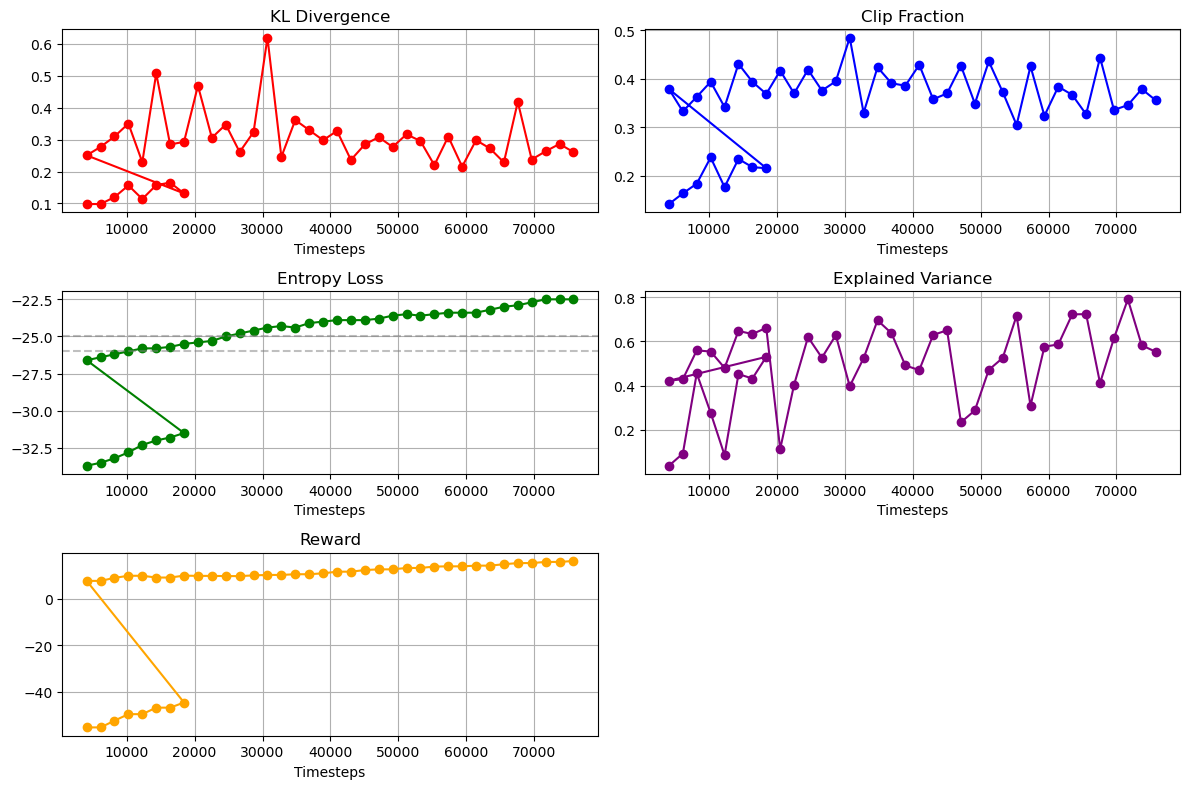

In [139]:
# Plotting
plt.figure(figsize=(12, 8))


"""

"""

# Create subplots
metrics_to_plot = ['approx_kl', 'clip_fraction', 'entropy_loss', 'explained_variance', 'reward']
colors = ['red', 'blue', 'green', 'purple', 'orange']
titles = ['KL Divergence', 'Clip Fraction', 'Entropy Loss', 'Explained Variance', 'Reward']

for i, (metric, color, title) in enumerate(zip(metrics_to_plot, colors, titles), 1):
    plt.subplot(3, 2, i)
    plt.plot(matrix['timesteps'], matrix[metric], color=color, marker='o')
    plt.title(title)
    plt.xlabel('Timesteps')
    plt.grid(True)
    
    # Special handling for entropy (negative values)
    if metric == 'entropy_loss':
        plt.axhline(y=-26, color='gray', linestyle='--', alpha=0.5)
        plt.axhline(y=-25, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [218]:
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from torch_geometric.nn import GraphSAGE

class GraphSAGEExtractor(BaseFeaturesExtractor):
    """
    Custom feature extractor for PPO that uses GraphSAGE.
    (Maps graph-structured observations to embeddings.)
    """
    def __init__(self, observation_space, features_dim=16):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]  # Last dimension is feature size
        self.graph_sage = GraphSAGE(
            in_channels=self.node_features,
            hidden_channels=16,
            num_layers=2,
            out_channels=1,  # Outputs 1D embedding per node
            aggr="mean",
        )
        self.flatten = nn.Flatten()

    def forward(self, observations):
        batch_size = observations["x"].shape[0]
        data_list = []
        for i in range(batch_size):
            x_i = torch.as_tensor(observations["x"][i], dtype=torch.float32)
            edge_i = torch.as_tensor(observations["edge_index"][i], dtype=torch.long)
            data_list.append(Data(x=x_i, edge_index=edge_i))
        
        batch = Batch.from_data_list(data_list)
        embeddings = self.graph_sage(batch.x, batch.edge_index)
        
        # Pooling or reshape to [batch_size, N] if needed
        pooled = embeddings.view(batch_size, -1)  # Assuming out_channels=1
        return pooled
        
env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)

# Reuse the same custom extractor config
"""policy_kwargs = {
    "features_extractor_class": GraphSAGEExtractor,
    "features_extractor_kwargs": {"features_dim": env.N},
}
"""
# Load model with environment and custom policy
model = PPO.load("graph_ppo_portfolio", env=env,  tensorboard_log="./ppo_tensorboard/")

# Continue training
model.learn(total_timesteps=100_000)  # Resume training with more steps
model.save("graph_ppo_portfolio_v2")  # Save updated model

# (Optional) Re-evaluate after retraining
evaluate_model(model, env)


TypeError: 'int' object is not iterable

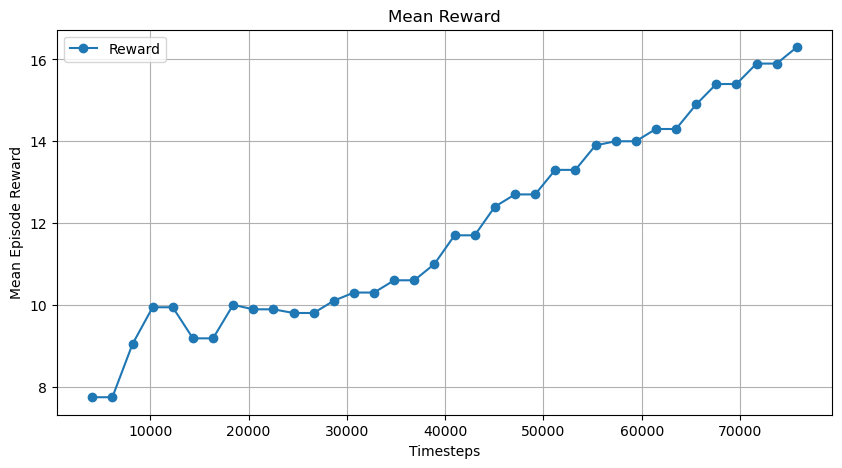

In [216]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["timesteps"], df["reward"], marker="o", label="Reward")
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Reward")
plt.title("Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

In [180]:
def evaluate_model(env, model, num_episodes=1):
    all_results = []
    
    for _ in range(num_episodes):
        obs = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, done, _ = env.step(action)
        
        # Get the recorded history
        history = env.get_history()
        all_results.append(history)
    
    return all_results

# Run evaluation

env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)
model = PPO.load("graph_ppo_portfolio", env=env)
results = evaluate_model(env, model)

# Extract the first episode's data (or average if multiple episodes)
drl_values = results[0]["DRL"]
ew_values = results[0]["Equal Weight"]
sp500_values = results[0]["S&P 500"]
import torch
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

# 1. Load your environment (with the same parameters used during training)
env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)

# 2. Load the trained model
model = PPO.load("graph_ppo_portfolio_v2", env=env)

# 3. Run evaluation to extract metrics
def extract_performance_metrics(model, env):
    obs = env.reset()
    done = False
    
    # Lists to store values for plotting
    portfolio_values = []
    equal_weight_values = []
    sp500_values = []
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, info = env.step(action)
        
        # Store values
        portfolio_values.append(info['portfolio_value'])
        equal_weight_values.append(info['benchmarks']['Equal Weight'][-1])
        sp500_values.append(info['benchmarks']['S&P 500'][-1])
    
    # Get final metrics
    final_metrics = {
        "Sharpe Ratio": info['metrics']['Sharpe Ratio'][-1],
        "Sortino Ratio": info['metrics']['Sortino Ratio'][-1],
        "Max Drawdown": info['metrics']['Max Drawdown'][-1],
        "Calmar Ratio": info['metrics']['Calmar Ratio'][-1],
        "Final Portfolio Value": info['portfolio_value'],
        "Final Equal Weight Value": info['benchmarks']['Equal Weight'][-1],
        "Final S&P 500 Value": info['benchmarks']['S&P 500'][-1],
        "Cumulative Return": (info['portfolio_value'] - env.initial_cash) / env.initial_cash,
    }
    
    return final_metrics, portfolio_values, equal_weight_values, sp500_values

# 4. Extract the metrics
metrics, portfolio_vals, ew_vals, sp500_vals = extract_performance_metrics(model, env)

# 5. Print the metrics
print("Performance Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

# 6. Plot the performance
plt.figure(figsize=(12, 6))
plt.plot(portfolio_vals, label='DRL Portfolio')
plt.plot(ew_vals, label='Equal Weight')
plt.plot(sp500_vals, label='S&P 500')
plt.title('Portfolio Performance Comparison')
plt.xlabel('Time Step')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid()


TypeError: new() received an invalid combination of arguments - got (Tensor, dtype=torch.dtype), but expected one of:
 * (*, torch.device device = None)
      didn't match because some of the keywords were incorrect: dtype
 * (torch.Storage storage)
 * (Tensor other)
 * (tuple of ints size, *, torch.device device = None)
 * (object data, *, torch.device device = None)


C:\Users\Acer\AppData\Local\Temp\ipykernel_21116\241057745.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(self.edge_index, dtype=torch.long)


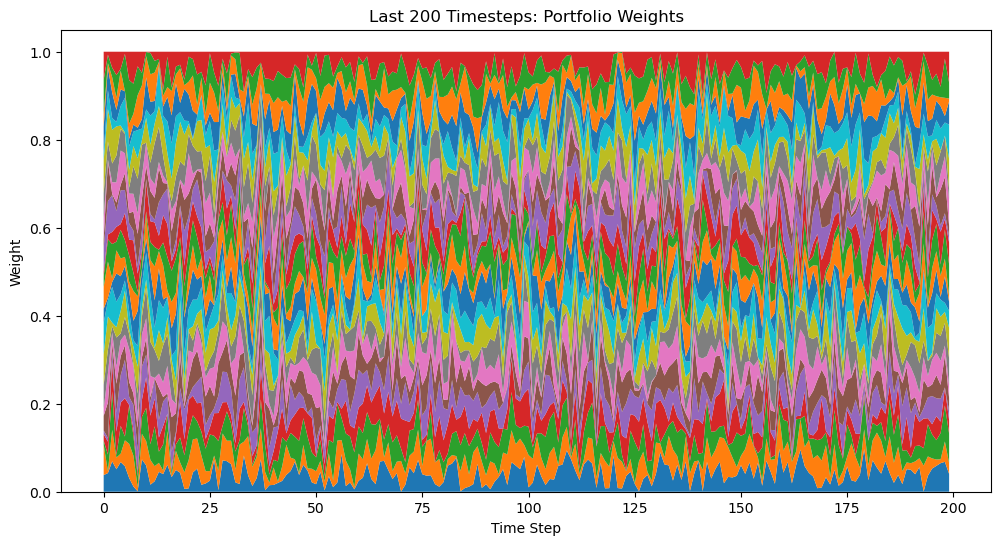

In [159]:
def plot_weights(env, model=None, last_n_steps=200):
    obs = env.reset()
    weights_history = []
    
    while True:
        if model:
            # For graph observations, we need to properly format the input
            graph_obs = {
                "x": torch.FloatTensor(obs["x"]).unsqueeze(0),  # Add batch dimension
                "edge_index": torch.LongTensor(obs["edge_index"])
            }
            action, _ = model.predict(graph_obs, deterministic=True)
        else:
            action = env.action_space.sample()
        
        obs, _, done, info = env.step(action)
        weights_history.append(info["weights"])
        if done:
            break
    
    # Plot last n steps
    recent_weights = weights_history[-last_n_steps:]
    plt.figure(figsize=(12, 6))
    plt.stackplot(range(len(recent_weights)), np.array(recent_weights).T)
    plt.title(f"Last {last_n_steps} Timesteps: Portfolio Weights")
    plt.xlabel("Time Step")
    plt.ylabel("Weight")
    plt.show()


plot_weights(env)

In [ ]:
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from torch_geometric.nn import GraphSAGE

class GraphSAGEExtractor(BaseFeaturesExtractor):
    """
    Custom feature extractor for PPO that uses GraphSAGE.
    (Maps graph-structured observations to embeddings.)
    """
    def __init__(self, observation_space, features_dim=16):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]  # Last dimension is feature size
        self.graph_sage = GraphSAGE(
            in_channels=self.node_features,
            hidden_channels=16,
            num_layers=2,
            out_channels=1,  # Outputs 1D embedding per node
            aggr="mean",
        )
        self.flatten = nn.Flatten()

    def forward(self, observations):
        batch_size = observations["x"].shape[0]
        data_list = []
        for i in range(batch_size):
            x_i = torch.as_tensor(observations["x"][i], dtype=torch.float32)
            edge_i = torch.as_tensor(observations["edge_index"][i], dtype=torch.long)
            data_list.append(Data(x=x_i, edge_index=edge_i))
        
        batch = Batch.from_data_list(data_list)
        embeddings = self.graph_sage(batch.x, batch.edge_index)
        
        # Pooling or reshape to [batch_size, N] if needed
        pooled = embeddings.view(batch_size, -1)  # Assuming out_channels=1
        return pooled
        
env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)

# Reuse the same custom extractor config
"""policy_kwargs = {
    "features_extractor_class": GraphSAGEExtractor,
    "features_extractor_kwargs": {"features_dim": env.N},
}
"""
# Load model with environment and custom policy
model = PPO.load("graph_ppo_portfolio", env=env)

# Continue training
model.learn(total_timesteps=300_000)  # Resume training with more steps
model.save("graph_ppo_portfolio_v2")  # Save updated model

# (Optional) Re-evaluate after retraining
evaluate_model(model, env)


In [142]:
def evaluate_model(model, env, num_episodes=1):
    """Evaluate the trained model and print performance metrics."""
    for episode in range(num_episodes):
        obs = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
        
        # Get the final portfolio history and metrics
        history = env.get_portfolio_history()
        metrics = info['metrics']
        
        # Calculate total returns
        drl_return = (history['DRL'][-1] / env.initial_cash - 1) * 100
        ew_return = (history['Equal Weight'][-1] / env.initial_cash - 1) * 100
        sp500_return = (history['S&P 500'][-1] / env.initial_cash - 1) * 100
        
        # Get final metrics
        sharpe = metrics['Sharpe Ratio'][-1]
        sortino = metrics['Sortino Ratio'][-1]
        max_drawdown = metrics['Max Drawdown'][-1]
        calmar = metrics['Calmar Ratio'][-1]
        
        # Print results
        print("\n" + "="*50)
        print(f"Evaluation Results - Episode {episode + 1}")
        print("="*50)
        print(f"{'Portfolio Strategy':<20} {'Total Return (%):':<20}")
        print(f"{'DRL':<20} {drl_return:.2f}%")
        print(f"{'Equal Weight':<20} {ew_return:.2f}%")
        print(f"{'S&P 500':<20} {sp500_return:.2f}%")
        print("\nPerformance Metrics:")
        print(f"{'Sharpe Ratio':<20} {sharpe:.4f}")
        print(f"{'Sortino Ratio':<20} {sortino:.4f}")
        print(f"{'Max Drawdown':<20} {max_drawdown:.4f}")
        print(f"{'Calmar Ratio':<20} {calmar:.4f}")
        print("="*50 + "\n")

# Load the trained model (if you saved it)
# model = PPO.load("graph_ppo_portfolio", env=env)

# Evaluate the model
evaluate_model(model, env)

C:\Users\Acer\AppData\Local\Temp\ipykernel_9644\1269193381.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(self.edge_index, dtype=torch.long)


ValueError: cannot reshape array of size 0 into shape (2,0)

traning other models

In [153]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE
import torch.nn as nn
import torch

class GraphSAGEExtractor_models(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=16):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]
        self.graph_sage = GraphSAGE(
            in_channels=self.node_features,
            hidden_channels=16,
            num_layers=2,
            out_channels=1,
            aggr="mean",
        )
        self.flatten = nn.Flatten()

    def forward(self, observations):
        batch_size = observations["x"].shape[0]
        data_list = []
        for i in range(batch_size):
            x_i = torch.as_tensor(observations["x"][i], dtype=torch.float32)
            edge_i = torch.as_tensor(observations["edge_index"], dtype=torch.long)
            data_list.append(Data(x=x_i, edge_index=edge_i))

        batch = Batch.from_data_list(data_list)
        embeddings = self.graph_sage(batch.x, batch.edge_index)
        pooled = embeddings.view(batch_size, -1)
        return pooled


In [159]:
from stable_baselines3 import DDPG, TD3, SAC
from stable_baselines3.common.env_util import make_vec_env


# Define env creator function
def make_env():
    return GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index) # Include any args if needed

# Wrap into a VecEnv
vec_env = make_vec_env(make_env, n_envs=1)


# Define policy with GraphSAGE feature extractor
policy_kwargs = dict(
    features_extractor_class=GraphSAGEExtractor_models,
    features_extractor_kwargs=dict(features_dim=env.N),
)

model_DDPG = DDPG(
    "MultiInputPolicy",
    vec_env,
    policy_kwargs=policy_kwargs,
    buffer_size=10_000,  # ↓ from 1 million
    verbose=1
)

model_TD3 = TD3("MultiInputPolicy", vec_env, buffer_size=10_000, policy_kwargs=policy_kwargs, verbose=1)
model_SAC = SAC("MultiInputPolicy", vec_env, buffer_size=10_000, policy_kwargs=policy_kwargs, verbose=1)


Using cpu device
Using cpu device
Using cpu device


C:\Users\Acer\AppData\Local\Temp\ipykernel_9644\3251994000.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(self.edge_index, dtype=torch.long)


In [161]:
# Train model
model_DDPG.learn(total_timesteps=300_000)
model_DDPG.save("graph_sac_portfolio")


C:\Users\Acer\AppData\Local\Temp\ipykernel_9644\3251994000.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(self.edge_index, dtype=torch.long)


ValueError: cannot reshape array of size 0 into shape (2,0)

In [ ]:
# Train model
model_TD3.learn(total_timesteps=300_000)
model_TD3.save("graph_sac_portfolio")


In [ ]:
# Train model
model_SAC.learn(total_timesteps=300_000)
model_SAC.save("graph_sac_portfolio")


In [257]:
import numpy as np
import gym
from gym import spaces
import torch
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GraphSAGE

class GraphPortfolioEnv(gym.Env):
    """
    Environment for GraphSAGE+PPO portfolio optimization (Sun et al., 2024).
    - Uses GraphSAGE for feature extraction.
    - Includes SHAP-selected features.
    - Tracks benchmark strategies (Equal Weight & S&P 500).
    - Computes financial metrics (Sharpe, Sortino, etc.).
    """
    
    def __init__(self, feature_matrix, price_matrix, adj_matrix, initial_cash=1.0, trading_cost=0.0025):
        """
        Args:
            feature_matrix: [T, N, F] array (T timesteps, N assets, F SHAP-selected features).
            price_matrix: [T, N] array (close prices).
            adj_matrix: [2, num_edges] or [num_edges, 2] array (financial graph connections).
            initial_cash: Starting portfolio value.
            trading_cost: Transaction cost (0.25% as in the paper).
        """
        super().__init__()
        self.feature_matrix = feature_matrix
        self.price_matrix = price_matrix
        
        # Process adjacency matrix to ensure shape (2, num_edges)
        if adj_matrix.shape[0] == 2:  # Already correct shape
            self.edge_index = adj_matrix
        else:  # Shape is (num_edges, 2), need to transpose
            self.edge_index = adj_matrix.T
        
        self.num_edges = self.edge_index.shape[1]
        self.T, self.N, self.F = 3361, 24, 20
        self.initial_cash = initial_cash
        self.trading_cost = trading_cost

        # Action: Portfolio weights (sum to 1)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.N,), dtype=np.float32)
        
        # Observation: Graph-structured state (node features + edges)
        self.observation_space = spaces.Dict({
            "x": spaces.Box(low=-np.inf, high=np.inf, shape=(self.N, self.F), dtype=np.float32),
            "edge_index": spaces.Box(low=0, high=self.N, shape=(2, self.num_edges), dtype=np.int32),
        })

        # Initialize GraphSAGE feature extractor (2-layer mean aggregation)
        self.graph_sage = GraphSAGE(
            in_channels=self.F,
            hidden_channels=16,  # As in the paper
            num_layers=2,
            out_channels=1,      # Outputs 1D embedding per node
            aggr="mean",        # Mean aggregation (paper uses this)
        )

        # Benchmarks
        self.benchmark_values = {
            "Equal Weight": [initial_cash],
            "S&P 500": [initial_cash],  # Assuming price_matrix[:, -1] is S&P 500
        }

        # Metrics
        self.metrics = {
            "Sharpe Ratio": [],
            "Sortino Ratio": [],
            "Max Drawdown": [],
            "Calmar Ratio": [],
        }

        self.reset()

    def reset(self):
        """Reset the environment to initial state."""
        self.t = 1  # Start at t=1 (needs t-1 for price relatives)
        self.portfolio_value = self.initial_cash
        self.weights = np.ones(self.N) / self.N  # Equal-weight init
        self.history = [self.portfolio_value]
        
        # Initialize benchmarks
        self.benchmark_values["Equal Weight"] = [self.initial_cash]
        self.benchmark_values["S&P 500"] = [self.initial_cash]
        
        return self._get_state()

    def _get_state(self):
        """Convert current features + edge index into a PyG-compatible format."""
        x = torch.tensor(self.feature_matrix[self.t], dtype=torch.float32)
        edge_index = torch.tensor(self.edge_index, dtype=torch.long)
        return {"x": x, "edge_index": edge_index}

    def step(self, action):
        # 1. Normalize action to ensure sum=1
        weights = np.clip(action, 0, 1)
        weights = weights / (weights.sum() + 1e-8)

        # 2. Compute price relatives (Eq. 2 in the paper)
        prev_prices = self.price_matrix[self.t - 1]
        curr_prices = self.price_matrix[self.t]
        price_relatives = curr_prices / (prev_prices + 1e-8)

        # 3. Transaction cost (Eq. 3 in the paper)
        weight_change = np.abs(weights - self.weights).sum()
        cost = self.trading_cost * weight_change
        
        """
        # 4. Portfolio return (Eq. 1 in the paper)
        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        reward = new_value - self.portfolio_value  # Eq. 10 in the paper
        """
        
        portfolio_return = np.dot(price_relatives, self.weights)
        new_value = self.portfolio_value * portfolio_return * (1 - cost)
        cost = self.trading_cost * np.sum(np.abs(self.weights - action))
        reward_raw = np.log(portfolio_return) if portfolio_return > 0 else -1.0
        
        reward = reward_raw - cost
        
        # small bonus for any profit
        if reward > 0:
            reward += 0.005
        
        # penalty for high drawdown
        drawdown = max(0, (self.portfolio_value - new_value) / self.portfolio_value)
        reward -= 0.1 * drawdown


        # 5. Update state
        self.portfolio_value = new_value
        self.weights = weights
        self.history.append(self.portfolio_value)
        self.t += 1

        # 6. Update benchmarks
        self._update_benchmarks(price_relatives)

        # 7. Compute metrics
        self._update_metrics()

        # 8. Prepare next state and check if done
        done = (self.t >= self.T - 1)
        next_state = self._get_state() if not done else None

        info = {
            "portfolio_value": self.portfolio_value,
            "weights": self.weights,
            "metrics": self.metrics,
            "benchmarks": self.benchmark_values,
        }
        return next_state, reward, done, info

    # Rest of the methods remain unchanged...
    def _update_benchmarks(self, price_relatives):
        """Update Equal Weight and S&P 500 benchmark values."""
        # Equal Weight strategy
        ew_return = np.mean(price_relatives)
        self.benchmark_values["Equal Weight"].append(
            self.benchmark_values["Equal Weight"][-1] * ew_return
        )

        # S&P 500 (assuming last column is S&P 500)
        sp500_return = price_relatives[-1]
        self.benchmark_values["S&P 500"].append(
            self.benchmark_values["S&P 500"][-1] * sp500_return
        )

    def _update_metrics(self):
        """Compute Sharpe, Sortino, Max Drawdown, and Calmar Ratios."""
        returns = np.diff(self.history) / self.history[:-1]  # Daily returns
        risk_free_rate = 0.0  # As in the paper

        # Sharpe Ratio (Eq. 12)
        sharpe = (np.mean(returns) - risk_free_rate) / (np.std(returns) + 1e-8)
        self.metrics["Sharpe Ratio"].append(sharpe)

        # Sortino Ratio (Eq. 13)
        downside_returns = returns[returns < 0]
        sortino = (np.mean(returns) - risk_free_rate) / (np.std(downside_returns) + 1e-8)
        self.metrics["Sortino Ratio"].append(sortino)

        # Max Drawdown (Eq. 14)
        peak = np.maximum.accumulate(self.history)
        trough = np.minimum.accumulate(self.history)
        max_drawdown = np.max((peak - trough) / peak)
        self.metrics["Max Drawdown"].append(max_drawdown)

        # Calmar Ratio (Eq. 15)
        calmar = np.mean(returns) / (max_drawdown + 1e-8)
        self.metrics["Calmar Ratio"].append(calmar)

    def render(self, mode='human'):
        """Display current portfolio and benchmark performance."""
        print(f"Step {self.t}:")
        print(f"- Portfolio Value: {self.portfolio_value:.4f}")
        print(f"- Equal Weight: {self.benchmark_values['Equal Weight'][-1]:.4f}")
        print(f"- S&P 500: {self.benchmark_values['S&P 500'][-1]:.4f}")
        print(f"- Sharpe Ratio: {self.metrics['Sharpe Ratio'][-1]:.4f}")
        print(f"- Sortino Ratio: {self.metrics['Sortino Ratio'][-1]:.4f}")
        print(f"- Calmar Ratio: {self.metrics['Calmar Ratio'][-1]:.4f}")
        print(f"- Max Drawdown: {self.metrics['Max Drawdown'][-1]:.4f}")

    def get_portfolio_history(self):
        return {
            "DRL": self.history,
            "Equal Weight": self.benchmark_values["Equal Weight"],
            "S&P 500": self.benchmark_values["S&P 500"],
        }

import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from torch_geometric.nn import GraphSAGE

class GraphSAGEExtractor(BaseFeaturesExtractor):
    """
    Custom feature extractor for PPO that uses GraphSAGE.
    (Maps graph-structured observations to embeddings.)
    """
    def __init__(self, observation_space, features_dim=16):
        super().__init__(observation_space, features_dim)
        self.node_features = observation_space["x"].shape[-1]  # Last dimension is feature size
        self.graph_sage = GraphSAGE(
            in_channels=self.node_features,
            hidden_channels=16,
            num_layers=2,
            out_channels=1,  # Outputs 1D embedding per node
            aggr="mean",
        )
        self.flatten = nn.Flatten()

    def forward(self, observations):
        batch_size = observations["x"].shape[0]
        data_list = []
        for i in range(batch_size):
            x_i = torch.as_tensor(observations["x"][i], dtype=torch.float32)
            edge_i = torch.as_tensor(observations["edge_index"][i], dtype=torch.long)
            data_list.append(Data(x=x_i, edge_index=edge_i))
        
        batch = Batch.from_data_list(data_list)
        embeddings = self.graph_sage(batch.x, batch.edge_index)
        
        # Pooling or reshape to [batch_size, N] if needed
        pooled = embeddings.view(batch_size, -1)  # Assuming out_channels=1
        return pooled
 
# Initialize environment
env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)

# Define PPO model with custom policy
policy_kwargs = {
    "features_extractor_class": GraphSAGEExtractor,
    "features_extractor_kwargs": {"features_dim": env.N},  # Output dim = number of assets
}
model = PPO(
    "MultiInputPolicy",  # Still uses MLP after GraphSAGE embeddings
    env,
    policy_kwargs=policy_kwargs,
    learning_rate=0.001,  # 0.0001 in the paper
    batch_size=32,          # 8 in the paper
    clip_range=0.5,        # As in the paper
    verbose=1,
)

# Train the model
model.learn(total_timesteps=50_000) 
model.save("graph_ppo_portfolio")


C:\Users\Acer\AppData\Local\Temp\ipykernel_16052\263876981.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(self.edge_index, dtype=torch.long)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 58   |
|    iterations      | 1    |
|    time_elapsed    | 35   |
|    total_timesteps | 2048 |
-----------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 3.36e+03  |
|    ep_rew_mean          | -61.9     |
| time/                   |           |
|    fps                  | 31        |
|    iterations           | 2         |
|    time_elapsed         | 129       |
|    total_timesteps      | 4096      |
| train/                  |           |
|    approx_kl            | 0.1080756 |
|    clip_fraction        | 0.18      |
|    clip_range           | 0.5       |
|    entropy_loss         | -33.8     |
|    explained_variance   | 0.0444    |
|    learning_rate        | 0.001     |
|    loss                 | 0.0078    |
|    n_updates  

C:\Users\Acer\AppData\Local\Temp\ipykernel_16052\263876981.py:128: RuntimeWarning: invalid value encountered in scalar divide
  drawdown = max(0, (self.portfolio_value - new_value) / self.portfolio_value)
C:\Users\Acer\AppData\Local\Temp\ipykernel_16052\263876981.py:173: RuntimeWarning: invalid value encountered in divide
  returns = np.diff(self.history) / self.history[:-1]  # Daily returns


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 3.36e+03   |
|    ep_rew_mean          | -45.5      |
| time/                   |            |
|    fps                  | 5          |
|    iterations           | 22         |
|    time_elapsed         | 8367       |
|    total_timesteps      | 45056      |
| train/                  |            |
|    approx_kl            | 0.15986955 |
|    clip_fraction        | 0.275      |
|    clip_range           | 0.5        |
|    entropy_loss         | -30.1      |
|    explained_variance   | 0.157      |
|    learning_rate        | 0.001      |
|    loss                 | -0.155     |
|    n_updates            | 210        |
|    policy_gradient_loss | -0.0384    |
|    std                  | 0.856      |
|    value_loss           | 0.00198    |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean

C:\Users\Acer\AppData\Local\Temp\ipykernel_16052\263876981.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(self.edge_index, dtype=torch.long)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\Acer\AppData\Local\Temp\ipykernel_16052\263876981.py:128: RuntimeWarning: invalid value encountered in scalar divide
  drawdown = max(0, (self.portfolio_value - new_value) / self.portfolio_value)
C:\Users\Acer\AppData\Local\Temp\ipykernel_16052\263876981.py:173: RuntimeWarning: invalid value encountered in divide
  returns = np.diff(self.history) / self.history[:-1]  # Daily returns


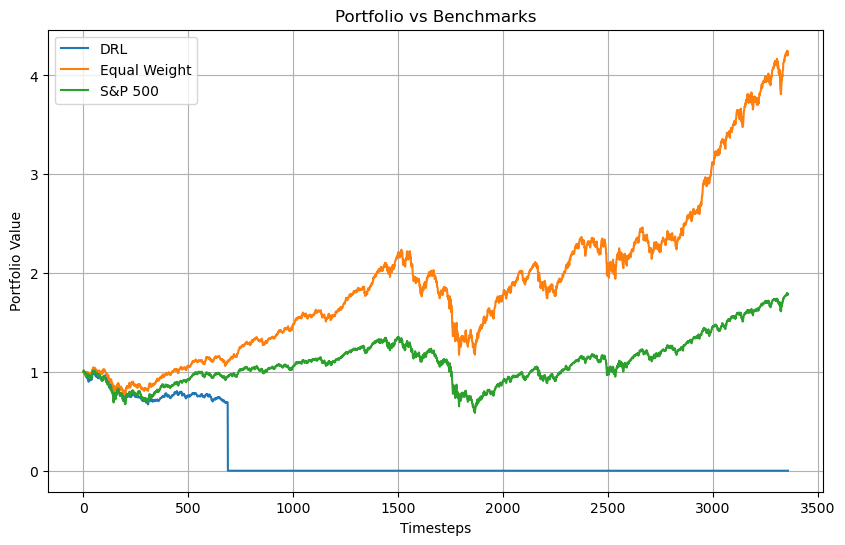

Final Portfolio Value: 0.0
Final Sharpe Ratio: nan
Final Sortino Ratio: nan
Final Max Drawdown: 1.0
Final Calmar Ratio: nan


In [261]:
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

# Reload the trained model
env = GraphPortfolioEnv(feature_matrix, closing_prices.to_numpy(), edge_index)
model = PPO.load("graph_ppo_portfolio", env=env)

# Run the model to get portfolio trajectory
obs = env.reset()
done = False
while not done:
    obs_batched = {k: v.unsqueeze(0) for k, v in obs.items()}  # Add batch dimension
    action, _ = model.predict(obs_batched, deterministic=True)
    action = action.squeeze()  # Ensure shape (N,) not (1, N)
    obs, reward, done, info = env.step(action)

# Plot portfolio vs benchmarks
history = env.get_portfolio_history()

plt.figure(figsize=(10, 6))
for label, values in history.items():
    plt.plot(values, label=label)
plt.xlabel("Timesteps")
plt.ylabel("Portfolio Value")
plt.title("Portfolio vs Benchmarks")
plt.legend()
plt.grid(True)
plt.show()

# Print final evaluation metrics
final_metrics = env.metrics
print("Final Portfolio Value:", history["DRL"][-1])
print("Final Sharpe Ratio:", final_metrics["Sharpe Ratio"][-1])
print("Final Sortino Ratio:", final_metrics["Sortino Ratio"][-1])
print("Final Max Drawdown:", final_metrics["Max Drawdown"][-1])
print("Final Calmar Ratio:", final_metrics["Calmar Ratio"][-1])
